# Lección 6.2 · Control de calidad y limpieza de lecturas (QC y trimming)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-06-ngs/6.2_control_calidad_trimming.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 6 — Secuenciación de nueva generación (NGS)** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~3.5 horas | Intermedio | Lección 2.1 (formato FASTQ, calidad Phred y errores esperados), NumPy y pandas |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Descargar** de forma parcial (por *streaming*) las lecturas de una corrida Illumina real usando la API del
   **European Nucleotide Archive (ENA)**, sin bajar el archivo completo.
2. **Programar desde cero** los módulos clásicos de **FastQC**: calidad por posición y por *tile*, calidad media por
   lectura, contenido de bases por posición, contenido GC, bases N, niveles de duplicación, secuencias
   sobrerrepresentadas y contenido de adaptadores; e **interpretar** cada uno sobre datos reales.
3. **Explicar** por qué aparecen los adaptadores dentro de las lecturas (*read-through*) y el sesgo de composición
   de los primeros ciclos en una biblioteca **Nextera** (transposasa Tn5).
4. **Resolver a mano y programar** tres algoritmos de recorte por calidad: **ventana deslizante** (Trimmomatic
   `SLIDINGWINDOW`), recorte del extremo 3′ de **BWA** (`-q`) y el **segmento de máxima suma** de Mott.
5. **Recortar adaptadores** con un **alineamiento semiglobal con tolerancia a errores** (la idea de Cutadapt) y con el
   **solapamiento de los pares** (la idea de fastp), y **estimar** el tamaño de inserto.
6. **Aplicar filtros** de longitud mínima, bases N, baja complejidad y **errores esperados máximos** (*maxEE*).
7. **Ejecutar fastp** en Colab, **leer su informe JSON** y **comparar** sus números con los de nuestro propio
   programa; y **saber** para qué sirve MultiQC.

## 🗺️ Mapa de la clase

1. ¿Por qué limpiar las lecturas? Lo que puede salir mal en una corrida
2. 🧪 Datos reales: 30 000 pares de *E. coli* desde el ENA por *streaming*
3. Calidad por posición, por *tile* y por lectura
4. Composición: contenido de bases por posición (explorador interactivo) y contenido GC
5. Bases N, duplicación y secuencias sobrerrepresentadas
6. Contenido de adaptadores
7. Recorte por calidad: ventana deslizante, BWA y Mott (🎬 animación y explorador interactivo)
8. Recorte de adaptadores: alineamiento semiglobal y solapamiento de pares (🎬 animación)
9. Filtros: longitud, N, baja complejidad y errores esperados
10. Nuestro limpiador completo: antes y después
11. 🧪 fastp en Colab y su informe JSON; MultiQC
12. Ejercicios, resumen y lecturas

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import io, re, gzip, json, shutil, subprocess, time
from collections import Counter
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.patches import FancyBboxPatch, Rectangle

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def course_bytes(name, live_url=None, timeout=60):
    """Lee un archivo del curso: 1) copia local ../data; 2) servicio original (ENA…);
    3) copia de respaldo en el repositorio de GitHub. Devuelve los bytes."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return open(local, "rb").read()
    for url in [live_url, f"{RAW}/data/{name}"]:
        if url is None:
            continue
        try:
            with urllib.request.urlopen(url, timeout=timeout) as r:
                return r.read()
        except Exception as err:
            print(f"⚠️ No se pudo descargar {url[:70]}… ({err}); pruebo la siguiente fuente")
    raise RuntimeError(f"No se encontró {name}")

BASES = "ACGT"
rng = np.random.default_rng(62)       # semilla fija: todos obtenemos los mismos números
print("Listo para la Lección 6.2")

Entorno listo ✔  |  Colab: False
Listo para la Lección 6.2


## 1. ¿Por qué limpiar las lecturas? Lo que puede salir mal en una corrida

En la Lección 2.1 aprendimos a leer un FASTQ: cuatro líneas por lectura, y en la cuarta, un carácter por base que
codifica la calidad Phred $Q = -10\log_{10} P$. También construimos, con datos simulados, el gráfico de calidad por
posición y calculamos los **errores esperados** de una lectura. Hoy damos el paso siguiente: tomar un FASTQ **real**,
diagnosticar sus problemas como lo hace un profesional y **limpiarlo** antes de alinearlo o ensamblarlo.

¿Por qué no alinear directamente? Porque el secuenciador entrega todo lo que leyó, incluidas cosas que **no son el
genoma** que nos interesa o que están leídas con poca confianza. Piense en una fotocopia de un libro antiguo: la mayor
parte de cada página es legible, pero los márgenes salen borrosos, algunas páginas traen la etiqueta de la biblioteca
pegada encima del texto y otras vienen repetidas. Antes de transcribir el libro conviene recortar los márgenes, quitar
las etiquetas y descartar las páginas ilegibles. Con las lecturas pasa lo mismo:

| Problema | Cómo se ve en el FASTQ | Consecuencia si no se corrige |
|---|---|---|
| **Caída de calidad** al final de la lectura (desfase de los *clusters*) | colas con Q bajo, a veces `#` (Q2) | falsos SNP, alineamientos con muchas diferencias |
| **Adaptador** dentro de la lectura (*read-through*) cuando el inserto es más corto que la lectura | la secuencia termina en `CTGTCTCTTATA…` (Nextera) o `AGATCGGAAGAGC…` (TruSeq) | la lectura no alinea, o alinea mal; ensamblajes con quimeras |
| **Bases N** (el equipo no pudo decidir) | `N` en la secuencia, calidad `#` | ruido en el alineamiento y en la llamada de variantes |
| **Sesgo de composición** en los primeros ciclos | proporciones A/C/G/T muy desiguales en las posiciones 1–10 | normalmente inofensivo; hay que saber reconocerlo |
| **Duplicados de PCR** | pares idénticos repetidos | sobreestiman la cobertura y la confianza en una variante |
| **Contaminación** o secuencias sobrerrepresentadas | la misma secuencia miles de veces, GC con dos picos | lecturas que no son del organismo; sesgos en cuantificación |

El flujo habitual tiene dos pasos que se repiten: **diagnosticar** (FastQC, o nuestro código), **limpiar** (Trimmomatic,
Cutadapt, fastp) y **volver a diagnosticar** para comprobar que la limpieza funcionó y no destruyó datos buenos.

### ¿De dónde salen los adaptadores dentro de la lectura?

En una biblioteca Illumina, cada fragmento de ADN (el **inserto**) queda flanqueado por dos **adaptadores** sintéticos
que le permiten pegarse a la celda de flujo y servir de punto de partida al cebador de secuenciación. El equipo lee un
número fijo de ciclos, aquí **150**, empezando justo después del adaptador. Si el inserto mide **más** de 150 pb, la
lectura cae entera dentro del ADN genómico. Si mide **menos**, al terminar el inserto el secuenciador sigue leyendo…
y lo que encuentra es el adaptador del otro extremo. A eso se le llama *adapter read-through*.

La regla es sencilla: si el inserto mide $I$ pb y la lectura $L$ ciclos, el adaptador aparece a partir de la posición
$I + 1$ cuando $I < L$. Un inserto de 100 pb en una lectura de 150 deja **50 bases de adaptador** al final.

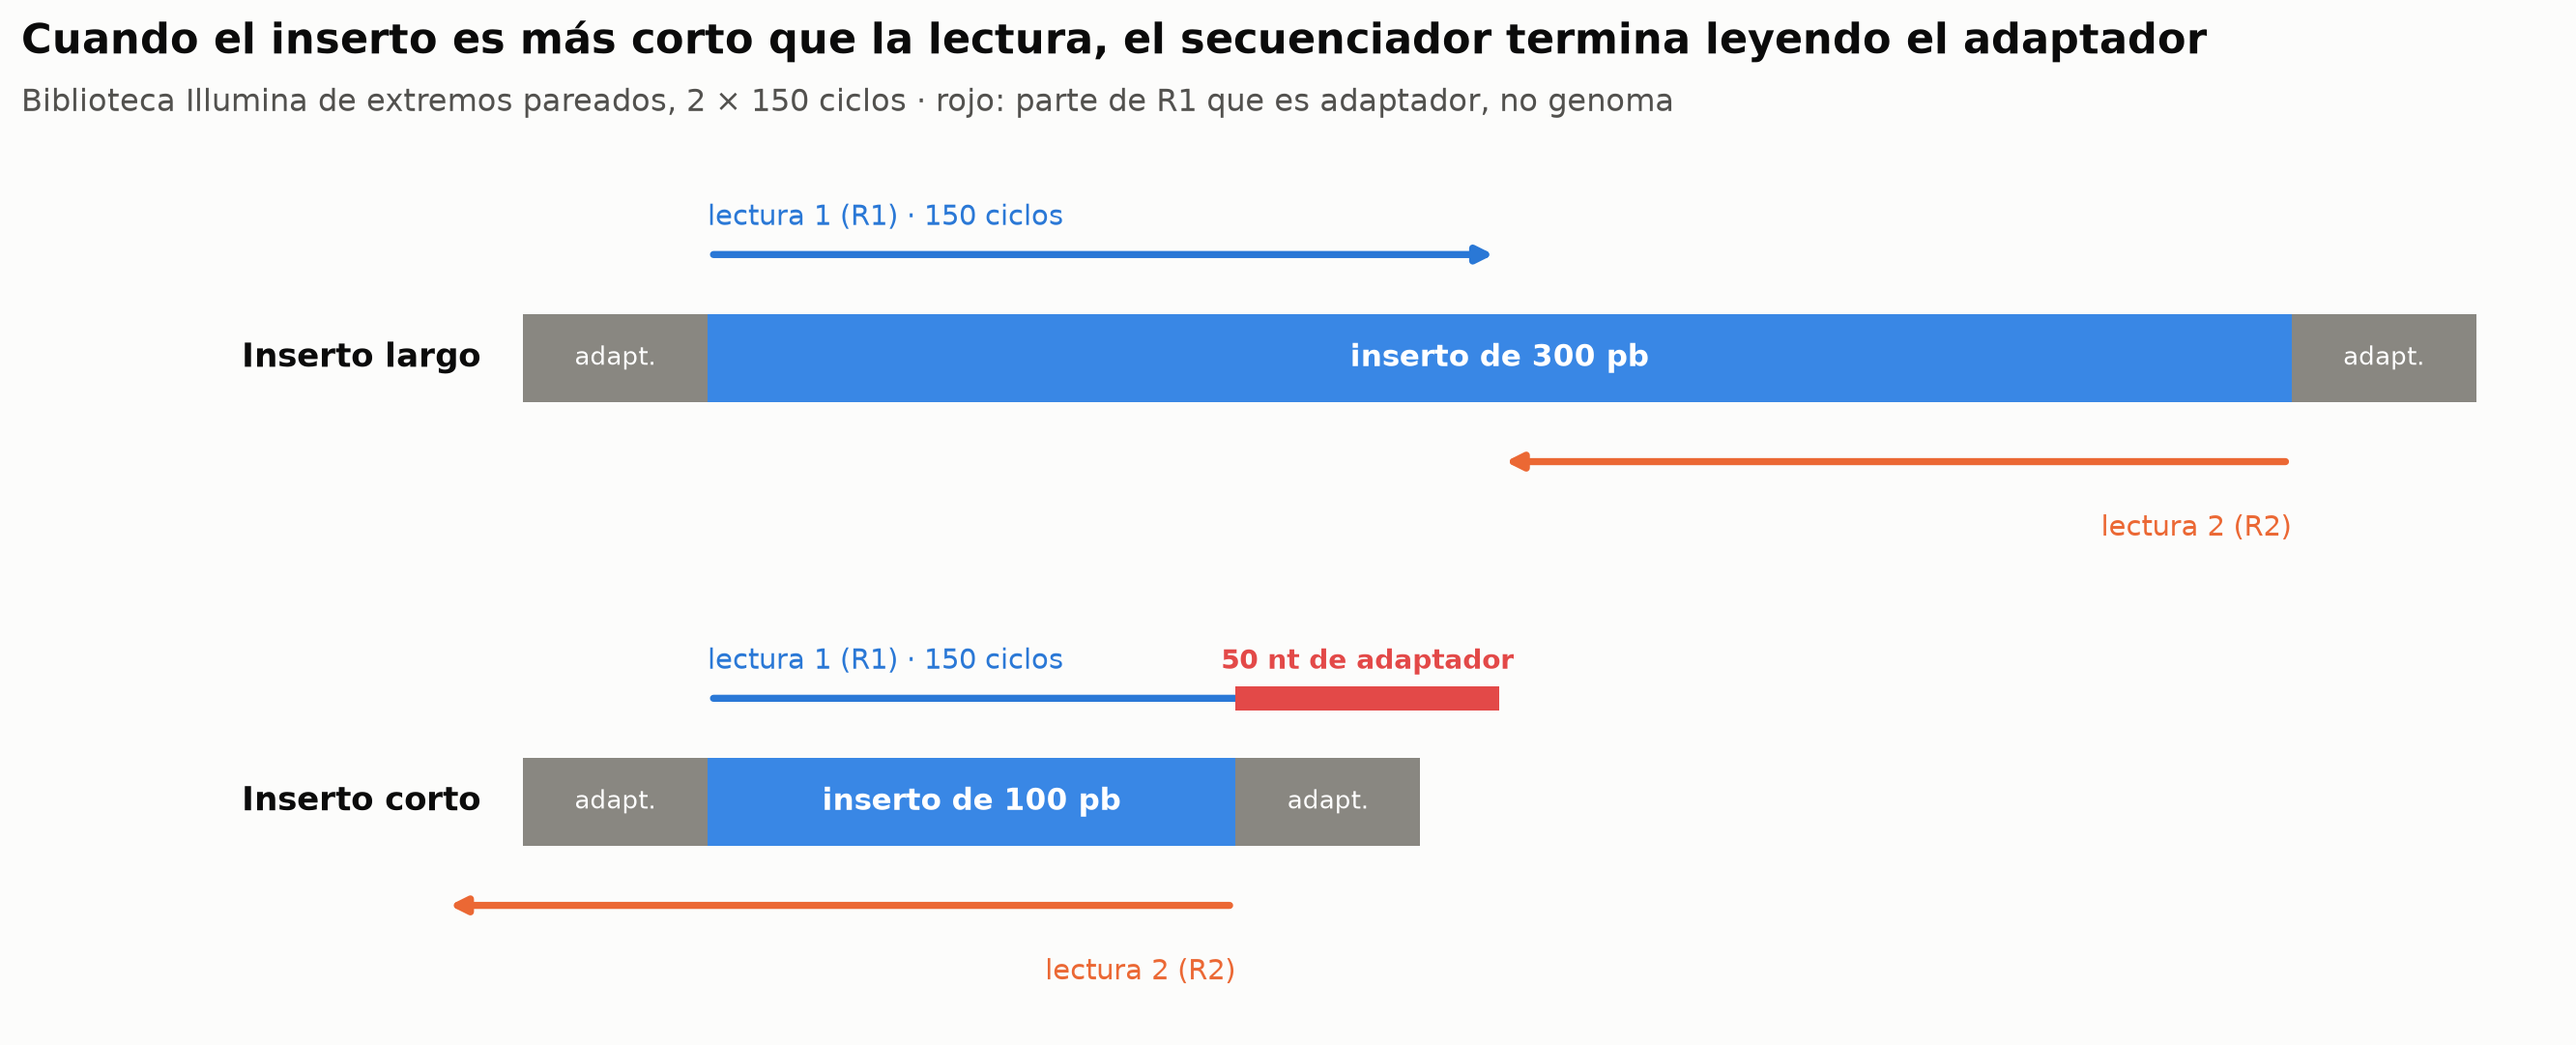

In [2]:
def draw_fragment(ax, y, insert, read_len=150, label=""):
    """Dibuja un fragmento de biblioteca con sus adaptadores y las dos lecturas del par."""
    ad = 35
    ax.add_patch(Rectangle((0, y), ad, 6, color=ec.MUTED))
    ax.add_patch(Rectangle((ad, y), insert, 6, color=ec.SEQ_BLUE[6]))
    ax.add_patch(Rectangle((ad + insert, y), ad, 6, color=ec.MUTED))
    ax.text(ad + insert / 2, y + 3, f"inserto de {insert} pb", ha="center", va="center", color="white",
            fontsize=10, fontweight="bold")
    ax.text(ad / 2, y + 3, "adapt.", ha="center", va="center", color="white", fontsize=8.5)
    ax.text(ad + insert + ad / 2, y + 3, "adapt.", ha="center", va="center", color="white", fontsize=8.5)
    # lectura 1: de izquierda a derecha, desde el final del adaptador izquierdo
    r1_end = ad + read_len
    ax.annotate("", (r1_end, y + 10), (ad, y + 10), arrowprops=dict(arrowstyle="-|>", color=ec.BLUE, lw=2.4))
    ax.text(ad, y + 12, "lectura 1 (R1) · 150 ciclos", fontsize=9.5, color=ec.BLUE)
    # lectura 2: de derecha a izquierda, desde el adaptador derecho
    r2_start = ad + insert - read_len
    ax.annotate("", (r2_start, y - 4), (ad + insert, y - 4), arrowprops=dict(arrowstyle="-|>", color=ec.ORANGE, lw=2.4))
    ax.text(ad + insert, y - 9, "lectura 2 (R2)", fontsize=9.5, color=ec.ORANGE, ha="right")
    if insert < read_len:          # zona de adaptador leída por R1
        ax.add_patch(Rectangle((ad + insert, y + 9.2), read_len - insert, 1.6, color=ec.RED, zorder=4))
        ax.text(ad + insert + (read_len - insert) / 2, y + 12, f"{read_len - insert} nt de adaptador",
                ha="center", fontsize=9, color=ec.RED, fontweight="bold")
    ax.text(-8, y + 3, label, ha="right", va="center", fontsize=11, fontweight="bold", color=ec.INK)

fig, ax = plt.subplots(figsize=(12, 4.8))
draw_fragment(ax, 34, 300, label="Inserto largo")
draw_fragment(ax, 4, 100, label="Inserto corto")
ax.set_xlim(-95, 385); ax.set_ylim(-8, 52); ax.axis("off")
ec.title(ax, "Cuando el inserto es más corto que la lectura, el secuenciador termina leyendo el adaptador",
         "Biblioteca Illumina de extremos pareados, 2 × 150 ciclos · rojo: parte de R1 que es adaptador, no genoma")
plt.show()

> 🔎 **Qué observamos.** Con un inserto de 300 pb, R1 y R2 leen 150 bases de genoma cada una y ni siquiera se
> tocan. Con un inserto de 100 pb, **ambas** lecturas atraviesan el inserto completo y terminan en el adaptador; además,
> R1 y R2 se **solapan** entre sí en toda la longitud del inserto. Ese solapamiento será una herramienta muy poderosa
> en la sección 8: si R1 y R2 cuentan la misma historia en direcciones opuestas, el punto donde dejan de coincidir
> marca dónde empieza el adaptador, **sin necesidad de conocer su secuencia**.

## 2. 🧪 Datos reales: 30 000 pares de *E. coli* desde el ENA por *streaming*

Usaremos una corrida del experimento de **evolución a largo plazo de *E. coli*** de Richard Lenski (LTEE): el
BioProject **PRJNA295606** secuenció 264 genomas de clones aislados a lo largo de 50 000 generaciones
(Tenaillon *et al.*, 2016). Elegimos la corrida **SRR2584863** (muestra REL7179B, derivada de la cepa ancestral
*E. coli* B REL606): Illumina **HiSeq 2500**, extremos pareados de **2 × 150** ciclos, biblioteca **Nextera**. Es un
conjunto clásico para enseñar limpieza de lecturas porque trae de todo: colas de baja calidad, adaptadores Nextera y
un sesgo de composición muy visible.

### Paso 1: preguntar al ENA dónde están los archivos

Los archivos de lecturas públicos viven en tres archivos espejo que se sincronizan entre sí: el **SRA** (NCBI, EE. UU.),
el **ENA** (EMBL-EBI, Europa) y el **DDBJ** (Japón). El ENA tiene una API muy cómoda, el *portal API*: le damos el número
de acceso de la corrida y nos devuelve una tabla con los metadatos y las **URL de los FASTQ comprimidos**.

```
https://www.ebi.ac.uk/ena/portal/api/filereport?accession=SRR2584863&result=read_run&fields=...&format=tsv
```

La celda usa primero la copia guardada en el curso (`data/api_cache/`) y, si no existe (por ejemplo en Colab),
consulta la API en vivo.

In [3]:
RUN = "SRR2584863"
ENA_FIELDS = ("run_accession,study_accession,sample_accession,scientific_name,instrument_model,library_layout,"
              "library_strategy,library_source,library_selection,read_count,base_count,fastq_ftp,fastq_bytes,fastq_md5")
ENA_URL = (f"https://www.ebi.ac.uk/ena/portal/api/filereport?accession={RUN}"
           f"&result=read_run&fields={ENA_FIELDS}&format=tsv")

report = course_bytes(f"api_cache/ena_filereport_{RUN}.tsv", live_url=ENA_URL).decode()
meta = pd.read_csv(io.StringIO(report), sep="\t").iloc[0]
fastq_urls = ["https://" + u for u in meta.fastq_ftp.split(";")]
sizes_mb = [int(b) / 1e6 for b in str(meta.fastq_bytes).split(";")]

print(f"Corrida: {meta.run_accession} · estudio {meta.study_accession} · muestra {meta.sample_accession}")
print(f"Organismo: {meta.scientific_name} · equipo: {meta.instrument_model}")
print(f"Biblioteca: {meta.library_strategy} / {meta.library_source} / {meta.library_selection} / {meta.library_layout}")
print(f"Pares de lecturas: {meta.read_count:,} · bases totales: {meta.base_count / 1e6:,.0f} Mb "
      f"(≈ {meta.base_count / 4.6e6:.0f}× de cobertura de un genoma de 4.6 Mb)")
for u, s in zip(fastq_urls, sizes_mb):
    print(f"  {u}  ({s:,.0f} MB comprimido)")

Corrida: SRR2584863 · estudio PRJNA295606 · muestra SAMN04096083
Organismo: Escherichia coli B str. REL606 · equipo: Illumina HiSeq 2500
Biblioteca: WGS / GENOMIC / RANDOM / PAIRED
Pares de lecturas: 1,553,259 · bases totales: 466 Mb (≈ 101× de cobertura de un genoma de 4.6 Mb)
  https://ftp.sra.ebi.ac.uk/vol1/fastq/SRR258/003/SRR2584863/SRR2584863_1.fastq.gz  (183 MB comprimido)
  https://ftp.sra.ebi.ac.uk/vol1/fastq/SRR258/003/SRR2584863/SRR2584863_2.fastq.gz  (191 MB comprimido)


### Paso 2: leer sólo el principio del archivo (*streaming*)

Cada FASTQ comprimido pesa unos 190 MB. Para una clase no necesitamos 1.5 millones de pares: basta con unos miles.
Como el formato gzip se puede **descomprimir mientras llega**, abrimos la conexión HTTP, descomprimimos al vuelo y
**cortamos** en cuanto tenemos $4 \times N$ líneas. Es como abrir la llave del agua, llenar un vaso y cerrarla: no hace
falta vaciar el tanque entero.

```python
with urllib.request.urlopen(url) as resp:            # conexión abierta, todavía sin datos
    with gzip.GzipFile(fileobj=resp) as gz:          # descompresión al vuelo
        for line in gz: ...                          # cada línea llega a medida que se necesita
```

La celda siguiente hace una demostración en vivo con 2 000 lecturas (unos 250 kB de descarga). Si no hay conexión,
simplemente lo avisa; el resto de la clase no depende de ella.

In [4]:
def stream_fastq_head(url, n_reads, timeout=60):
    """Lee sólo las primeras n_reads lecturas de un FASTQ.gz remoto, sin descargar el archivo completo."""
    lines = []
    with urllib.request.urlopen(url, timeout=timeout) as resp:
        with gzip.GzipFile(fileobj=resp) as gz:
            for line in gz:
                lines.append(line)
                if len(lines) == 4 * n_reads:
                    break                                   # cerramos la llave: no se descarga nada más
    return b"".join(lines)

try:
    t0 = time.time()
    demo = stream_fastq_head(fastq_urls[0], 2000, timeout=30)
    n_demo = demo.count(b"\n") // 4
    print(f"✔ {n_demo:,} lecturas recibidas en {time.time() - t0:.1f} s "
          f"({len(demo) / 1e3:,.0f} kB sin comprimir)")
    print(demo.decode().splitlines()[0])
except Exception as err:
    demo = None
    print("⚠️ Sin conexión con el ENA en este momento:", err)

✔ 2,000 lecturas recibidas en 3.4 s (730 kB sin comprimir)
@SRR2584863.1 HWI-ST957:244:H73TDADXX:1:1101:4712:2181/1


### Paso 3: el subconjunto de la clase

Para que todos trabajemos con los mismos números, el curso guarda una copia de los **primeros 30 000 pares** de la
corrida (`data/SRR2584863_30k_1.fastq.gz` y `…_2.fastq.gz`, 7.3 MB en total). La guía original sugería 50 000–100 000
pares; nos quedamos en 30 000 para que el repositorio siga siendo liviano. Si quiere más, cambie `N_PAIRS` y la celda
los leerá del ENA por *streaming*.

> ⚠️ **Una advertencia honesta sobre la muestra.** Son las **primeras** lecturas del archivo, no una muestra al azar.
> Illumina escribe las lecturas *tile* por *tile* (una *tile* es una pequeña región de la celda de flujo que la cámara
> fotografía de una vez), y las primeras corresponden a las *tiles* 1101–1106, en el **borde** de la celda de flujo,
> donde la química y el enfoque suelen ser algo peores. Por eso la calidad que veremos es **peor que el promedio** de
> la corrida. Para aprender es una ventaja: habrá mucho que limpiar. Pero no generalice estas cifras a toda la corrida.

In [5]:
N_PAIRS = 30_000          # súbalo (p. ej. 100_000) para leer más pares del ENA por streaming

def load_reads(mate):
    """Devuelve los bytes (sin comprimir) de las primeras N_PAIRS lecturas del extremo `mate` (1 o 2)."""
    name = f"{RUN}_30k_{mate}.fastq.gz"
    local = os.path.join("..", "data", name)
    if N_PAIRS <= 30_000 and os.path.exists(local):                 # 1) copia local del curso
        return gzip.decompress(open(local, "rb").read())
    try:                                                              # 2) ENA por streaming
        return stream_fastq_head(fastq_urls[mate - 1], N_PAIRS, timeout=120)
    except Exception as err:
        print(f"⚠️ ENA no disponible ({err}); uso la copia del repositorio (30 000 pares)")
    return gzip.decompress(course_bytes(name))                        # 3) copia en GitHub

def parse_fastq(raw):
    """Separa un FASTQ (bytes) en cabeceras (sin la @), secuencias y cadenas de calidad."""
    lines = raw.decode().splitlines()
    return [l[1:] for l in lines[0::4]], lines[1::4], lines[3::4]

def to_matrices(seqs, quals, length=None):
    """Convierte las lecturas en matrices NumPy: S (códigos ASCII de las bases) y Q (calidades Phred).
    Si hay lecturas de distinta longitud, se rellenan con N y Q = 0 hasta `length`."""
    length = length or max(map(len, seqs))
    S = np.full((len(seqs), length), ord("N"), dtype=np.uint8)
    Q = np.zeros((len(seqs), length), dtype=np.int16)
    for i, (s, q) in enumerate(zip(seqs, quals)):
        S[i, :len(s)] = np.frombuffer(s.encode(), np.uint8)
        Q[i, :len(q)] = np.frombuffer(q.encode(), np.uint8) - 33      # Phred+33 (Lección 2.1)
    return S, Q

t0 = time.time()
raw1, raw2 = load_reads(1), load_reads(2)            # bytes sin comprimir (se reutilizan en la sección 11)
heads1, seqs1, quals1 = parse_fastq(raw1)
heads2, seqs2, quals2 = parse_fastq(raw2)
names1 = [h.split()[0] for h in heads1]
names2 = [h.split()[0] for h in heads2]
S1, Q1 = to_matrices(seqs1, quals1)
S2, Q2 = to_matrices(seqs2, quals2)
N, L = S1.shape
print(f"{N:,} pares leídos en {time.time() - t0:.1f} s · longitud de lectura: {L} ciclos")
print("Los nombres de R1 y R2 coinciden par a par:", names1 == names2)
print("\nPrimer registro de R1:")
print("@" + heads1[0], seqs1[0], "+", quals1[0], sep="\n")

30,000 pares leídos en 0.1 s · longitud de lectura: 150 ciclos
Los nombres de R1 y R2 coinciden par a par: True

Primer registro de R1:
@SRR2584863.1 HWI-ST957:244:H73TDADXX:1:1101:4712:2181/1
TTCACATCCTGACCATTCAGTTGAGCAAAATAGTTCTTCAGTGCCTGTTTAACCGAGTCACGCAGGGGTTTTTGGGTTACCTGATCCTGAGAGTTAACGGTAGAAACGGTCAGTACGTCAGAATTTACGCGTTGTTCGAACATAGTTCTG
+
CCCFFFFFGHHHHJIJJJJIJJJIIJJJJIIIJJGFIIIJEDDFEGGJIFHHJIJJDECCGGEGIIJFHFFFACD:BBBDDACCCCAA@@CA@C>C3>@5(8&>C:9?8+89<4(:83825C(:A#########################


### El nombre de cada lectura es un código de barras de su origen

La cabecera original de la primera lectura es
`@SRR2584863.1 HWI-ST957:244:H73TDADXX:1:1101:4712:2181/1`. Después del número que le asignó el SRA viene el nombre
que le puso el secuenciador (formato Illumina ≥ 1.8), con campos separados por `:`:

| Campo | Valor | Significado |
|---|---|---|
| instrumento | `HWI-ST957` | identificador del HiSeq |
| corrida | `244` | número de corrida en ese equipo |
| celda de flujo | `H73TDADXX` | código de la *flow cell* |
| carril | `1` | *lane* (canal físico de la celda) |
| *tile* | `1101` | región fotografiada: superficie 1, franja 1, *tile* 01 |
| x, y | `4712`, `2181` | coordenadas del *cluster* dentro de la *tile* |
| `/1` | extremo | lectura 1 del par (R2 lleva `/2`) |

Así podemos agrupar las lecturas por *tile* y detectar zonas de la celda de flujo con problemas (burbujas, polvo,
bordes), algo que FastQC llama *per tile sequence quality*. El SRA sustituyó el nombre original por su propio número
al principio de la cabecera, pero conservó el original después del espacio.

In [6]:
fields = [h.split()[1].split(":") for h in heads1]
tiles = np.array([int(f[4]) for f in fields])
print("Ejemplo de cabecera:", heads1[0])
print(dict(zip(["instrumento", "corrida", "celda", "carril", "tile", "x", "y/extremo"], fields[0])))
print("Lecturas por tile:", dict(sorted(Counter(tiles).items())))

Ejemplo de cabecera: SRR2584863.1 HWI-ST957:244:H73TDADXX:1:1101:4712:2181/1
{'instrumento': 'HWI-ST957', 'corrida': '244', 'celda': 'H73TDADXX', 'carril': '1', 'tile': '1101', 'x': '4712', 'y/extremo': '2181/1'}
Lecturas por tile: {np.int64(1101): 5001, np.int64(1102): 5828, np.int64(1103): 5956, np.int64(1104): 6232, np.int64(1105): 6184, np.int64(1106): 799}


## 3. Calidad por posición, por *tile* y por lectura

### 3.1 ¿Por qué cae la calidad a lo largo de la lectura?

Cada *cluster* de la celda de flujo contiene unas mil copias de la misma molécula que se secuencian **a la vez**: en
cada ciclo, todas incorporan un nucleótido marcado, la cámara toma una foto y la señal conjunta dice qué base era. El
problema es que la química no es perfecta: en cada ciclo, una pequeña fracción de las copias **no incorpora** la base
(se atrasa, *phasing*) o incorpora **dos** (se adelanta, *prephasing*). Esas copias desfasadas siguen emitiendo luz,
pero del color "equivocado", y ensucian la señal. Es como un coro de mil voces en el que, en cada compás, unas pocas
personas se pierden y ya no vuelven a entrar a tiempo: al principio apenas se nota; al final, el coro suena confuso.

Llamemos $p$ a la probabilidad, por ciclo y por copia, de quedarse atrás y $q$ a la de adelantarse; la probabilidad
total de un evento de desfase en un ciclo es $\varepsilon = p + q$. Una copia sigue en fase tras $n$ ciclos si **no**
sufrió ningún evento en ninguno de ellos, y eso ocurre con probabilidad $(1-\varepsilon)$ multiplicada $n$ veces
(es el teorema «Decaimiento de la fracción en fase» del capítulo 6 del libro):

$$
\phi(n) \;=\; (1 - \varepsilon)^{\,n} \;\approx\; e^{-\varepsilon n}
$$

| Símbolo | Significado |
|---|---|
| $p$ | probabilidad por ciclo de **no** incorporar ninguna base (*phasing*, la copia se atrasa) |
| $q$ | probabilidad por ciclo de incorporar **dos** bases (*pre-phasing*, la copia se adelanta) |
| $\varepsilon$ | tasa total de desfase por ciclo, $p + q$ (típicamente del orden de una milésima) |
| $n$ | número de ciclos completados (posición en la lectura) |
| $\phi(n)$ | fracción de copias del *cluster* que nunca se desfasaron y emiten la base correcta en el ciclo $n$ |

Un matiz: una copia que se atrasa en un ciclo y se adelanta en otro vuelve a estar en fase, así que $\phi(n)$ es una
**cota inferior** de la fracción en fase; con $\varepsilon$ pequeño, esa compensación es rara y la cota es muy ajustada.

**Ejemplo a mano.** Con $\varepsilon = 0.002$: en el ciclo 10, $\phi = 0.998^{10} = 0.980$; en el ciclo 150,
$\phi = 0.998^{150} = e^{150 \ln 0.998} = e^{-0.300} = 0.74$; y en el ciclo 300, $\phi = 0.998^{300} = 0.55$. Al final
de una lectura de 150 pb, **una de cada cuatro** copias emite una señal desfasada, y en 300 ciclos casi la mitad: el
programa que asigna las bases (el *basecaller*) está menos seguro y lo refleja con un $Q$ más bajo. Por eso la caída
es **gradual y sistemática**, no un accidente de algunas lecturas.

### 3.2 El gráfico de calidad por posición, ahora con datos reales

En la Lección 2.1 dibujamos este gráfico con lecturas simuladas. Ahora lo hacemos con las 30 000 lecturas reales y
comparamos **R1 con R2**. Un detalle que no existía en la simulación: la calidad **Q2** (carácter `#`). Desde el
*software* CASAVA 1.8, Illumina marca con Q2 todo el **final** de una lectura cuando decide que ese tramo no es
confiable (*Read Segment Quality Control Indicator*): no es una estimación de probabilidad de error, es una bandera que
dice "de aquí en adelante, no confíe". Contemos cuántas bases llevan esa bandera en cada posición.

> 🤔 **Antes de ejecutar, prediga:** ¿cuál de las dos lecturas del par tendrá peor calidad, R1 o R2? Piense en qué le
> pasa al *cluster* entre la primera y la segunda lectura (tiene que regenerarse la hebra complementaria y ya lleva 150
> ciclos de química encima).

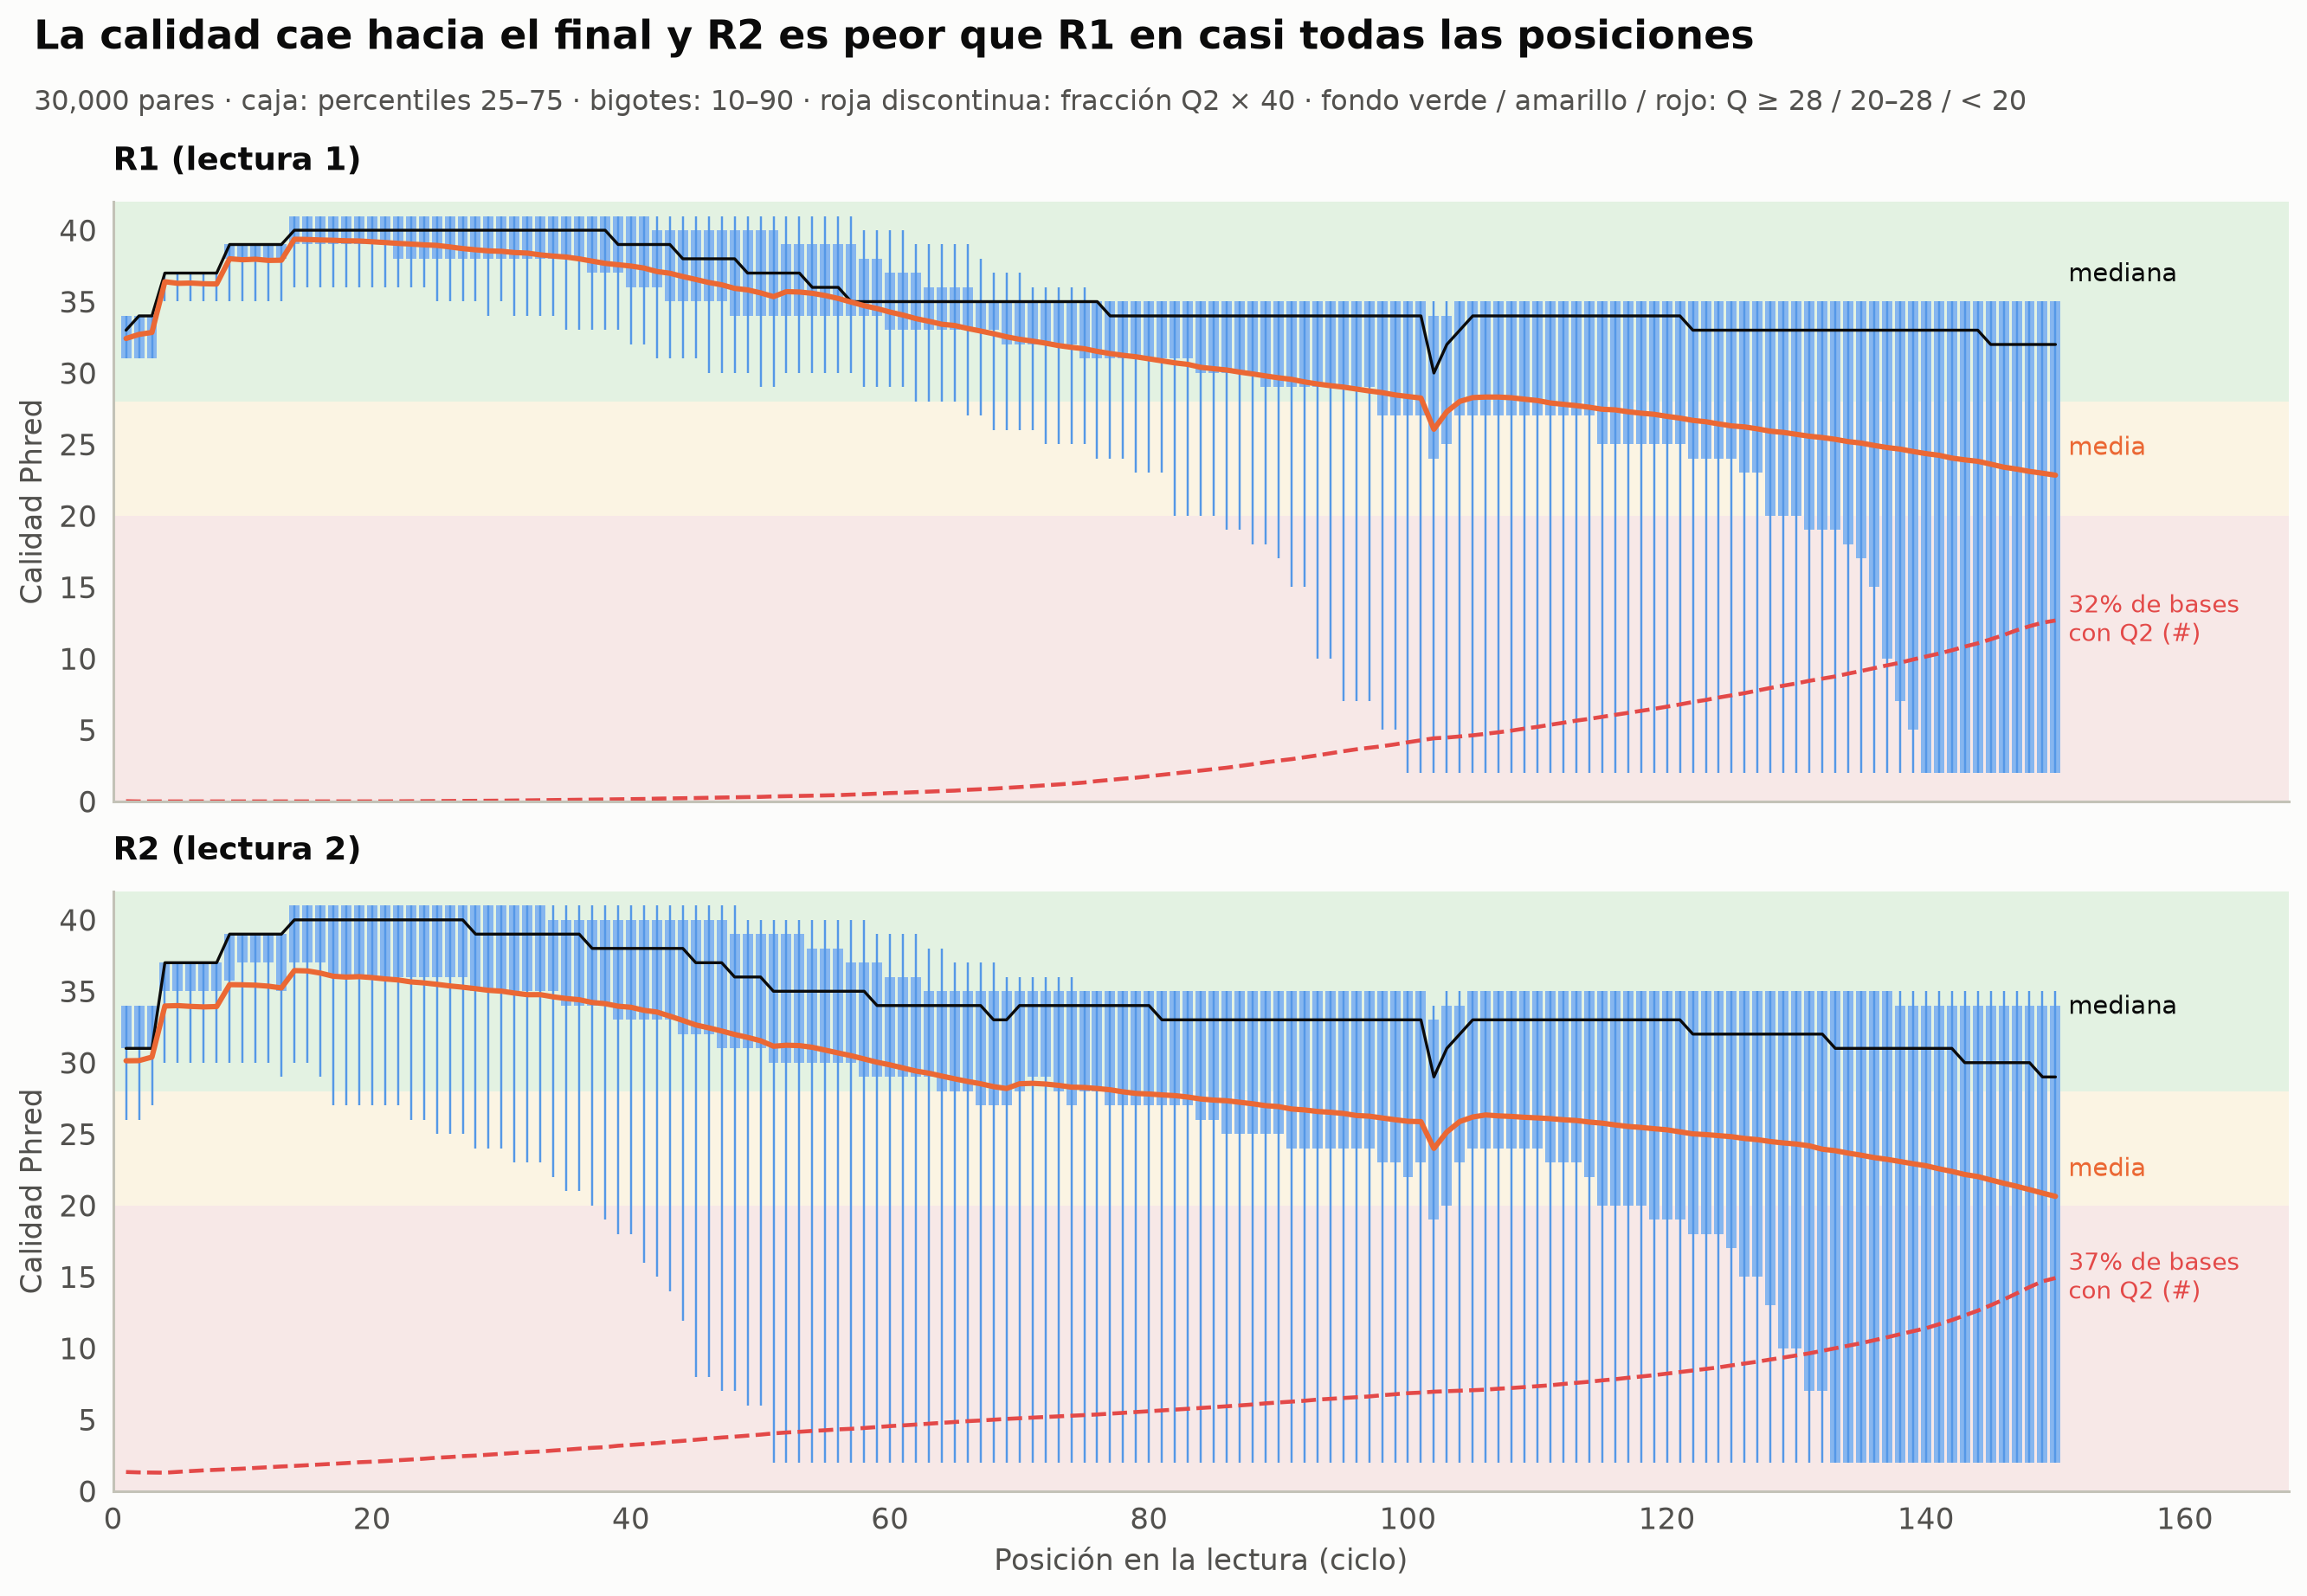

R1: Q medio 31.8 · bases ≥ Q30: 80.7% · bases Q2 (#): 8.0%
R2: Q medio 29.0 · bases ≥ Q30: 71.3% · bases Q2 (#): 14.4%


In [7]:
def per_position_stats(Q, valid=None):
    """Percentiles 10, 25, 50, 75 y 90 y media de la calidad en cada posición (ignora posiciones vacías)."""
    Qf = Q.astype(float)
    if valid is not None:
        Qf[~valid] = np.nan
    return np.nanpercentile(Qf, [10, 25, 50, 75, 90], axis=0), np.nanmean(Qf, axis=0)

def quality_boxplot(ax, Q, title, valid=None, show_q2=True):
    """Gráfico de calidad por posición al estilo FastQC."""
    pct, mean = per_position_stats(Q, valid)
    x = np.arange(1, Q.shape[1] + 1)
    for lo, hi, key in [(28, 42, "good"), (20, 28, "warning"), (0, 20, "critical")]:
        ax.axhspan(lo, hi, color=ec.STATUS[key], alpha=0.10, lw=0, zorder=0)
    ax.vlines(x, pct[0], pct[4], color=ec.SEQ_BLUE[5], lw=0.8)
    ax.bar(x, pct[3] - pct[1], bottom=pct[1], width=0.8, color=ec.SEQ_BLUE[3], lw=0)
    ax.plot(x, pct[2], color=ec.INK, lw=1.1)
    ax.plot(x, mean, color=ec.ORANGE, lw=2)
    if show_q2:
        q2 = (Q == 2).mean(0) if valid is None else ((Q == 2) & valid).sum(0) / np.maximum(valid.sum(0), 1)
        ax.plot(x, 40 * q2, color=ec.RED, lw=1.5, ls="--")
        ax.text(x[-1] + 1, 40 * q2[-1], f"{q2[-1]:.0%} de bases\ncon Q2 (#)", color=ec.RED, fontsize=9, va="center")
    ax.text(x[-1] + 1, mean[-1] + 1, "media", color=ec.ORANGE, fontsize=9.5, va="bottom")
    ax.text(x[-1] + 1, pct[2][-1] + 4, "mediana", color=ec.INK, fontsize=9.5, va="bottom")
    ax.set_xlim(0, Q.shape[1] + 18); ax.set_ylim(0, 42); ax.grid(False)
    ax.set_title(title, fontsize=12, loc="left")
    ax.set_ylabel("Calidad Phred")

fig, axes = plt.subplots(2, 1, figsize=(12, 7.6), sharex=True)
quality_boxplot(axes[0], Q1, "R1 (lectura 1)")
quality_boxplot(axes[1], Q2, "R2 (lectura 2)")
axes[1].set_xlabel("Posición en la lectura (ciclo)")
ec.fig_title(fig, "La calidad cae hacia el final y R2 es peor que R1 en casi todas las posiciones",
             f"{N:,} pares · caja: percentiles 25–75 · bigotes: 10–90 · roja discontinua: fracción Q2 × 40 · "
             "fondo verde / amarillo / rojo: Q ≥ 28 / 20–28 / < 20")
plt.show()

for lab, Q in [("R1", Q1), ("R2", Q2)]:
    print(f"{lab}: Q medio {Q.mean():.1f} · bases ≥ Q30: {(Q >= 30).mean():.1%} · bases Q2 (#): {(Q == 2).mean():.1%}")

> 🔎 **Qué observamos.** Las cajas empiezan altas (mediana cerca de 39–40), se mantienen muy bien hasta la mitad de
> la lectura y después bajan de forma gradual, como predijo el modelo de desfase. Hay una excepción llamativa: una
> **caída brusca en el ciclo 102**, en R1 y también en R2. Un descenso puntual que afecta a todas las lecturas en el
> mismo ciclo no es desfase: es un problema de ese ciclo de la corrida (por ejemplo, una foto con peor enfoque o un
> reactivo que llegó tarde). Las primeras 3 bases también tienen calidades algo menores: el *basecaller* aún está
> calibrando la intensidad de los *clusters*. Los **bigotes** inferiores llegan a
> 2 mucho antes que las medianas: una minoría de lecturas se "rompe" pronto y el resto de sus bases quedan marcadas con
> `#`. La línea roja muestra cómo esa fracción crece a lo largo de la lectura. R2 es peor que R1 en casi todo el
> recorrido: su *cluster* ya soportó 150 ciclos de química, la regeneración de la hebra complementaria y más tiempo
> bajo el láser. Esto es lo normal y es la razón por la que muchos protocolos recortan R2 con más agresividad.
>
> Observe también la **media** (naranja) frente a la **mediana** (negro): la media cae mucho más, porque las bases Q2
> la arrastran hacia abajo. Cuando lea un informe, mire las cajas, no sólo la media.

### 3.3 Calidad por *tile*: ¿hay zonas malas en la celda de flujo?

Si un problema físico (una burbuja, una mancha, un mal enfoque) afecta a una región de la celda de flujo, todas las
lecturas de esa *tile* tendrán peor calidad en los mismos ciclos. FastQC lo detecta restando, en cada posición, la
calidad media de **todas** las lecturas a la calidad media de cada *tile*:

$$
\Delta_{t,j} \;=\; \bar Q_{t,j} - \bar Q_{\cdot,j}
$$

| Símbolo | Significado |
|---|---|
| $\bar Q_{t,j}$ | calidad media en la posición $j$ de las lecturas de la *tile* $t$ |
| $\bar Q_{\cdot,j}$ | calidad media en la posición $j$ de todas las lecturas |
| $\Delta_{t,j}$ | desviación: negativa (azul) si la *tile* es peor que el promedio en ese ciclo |

Un mapa uniforme significa "sin problemas locales"; manchas azules intensas en ciertas *tiles* y ciclos, un problema
físico de la corrida.

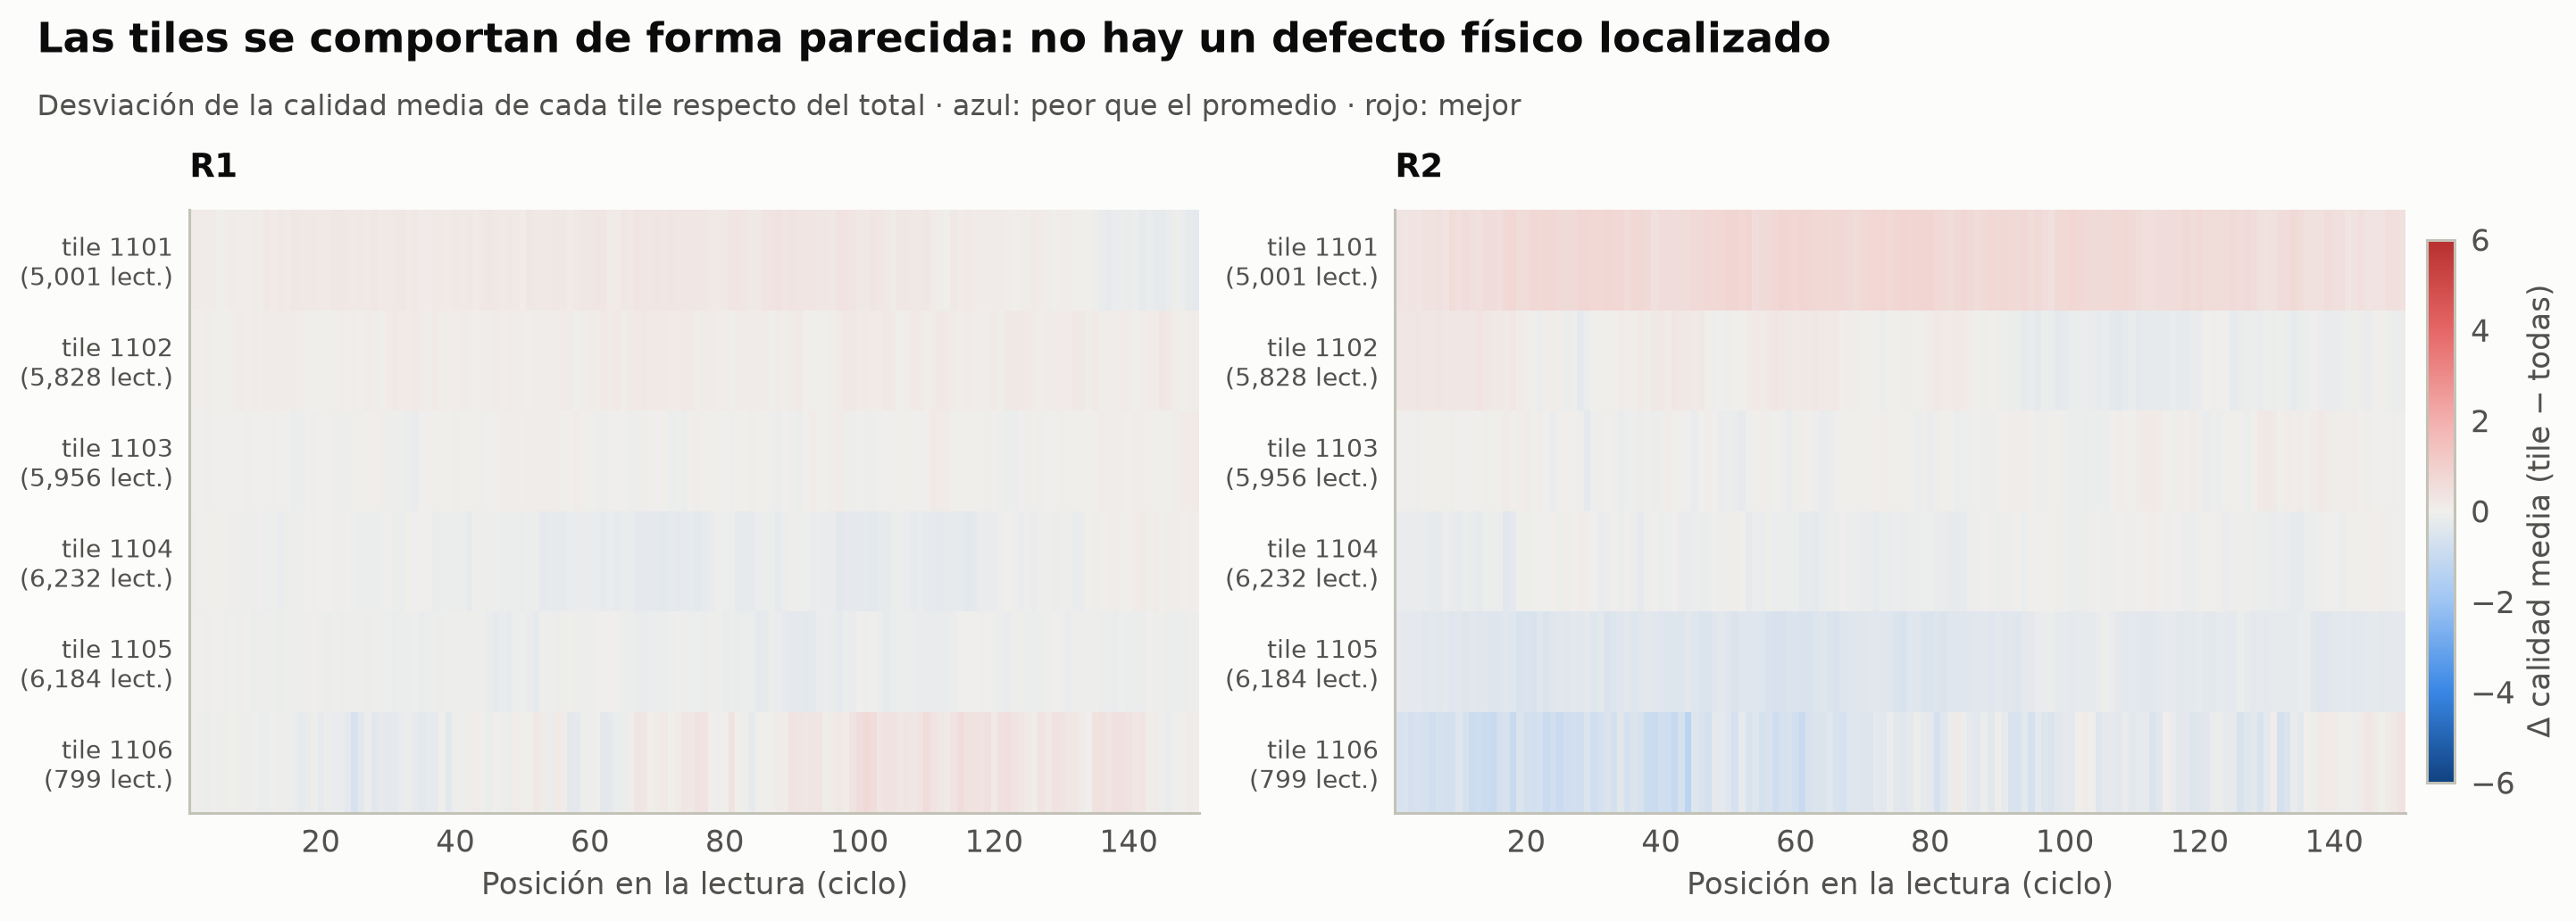

In [8]:
tile_ids = np.array(sorted(set(tiles)))
fig, axes = plt.subplots(1, 2, figsize=(13, 3.9), gridspec_kw=dict(width_ratios=[1, 1]))
for ax, Q, lab in [(axes[0], Q1, "R1"), (axes[1], Q2, "R2")]:
    overall = Q.mean(0)
    delta = np.array([Q[tiles == t].mean(0) - overall for t in tile_ids])
    im = ax.imshow(delta, aspect="auto", cmap=ec.CMAP_DIV, vmin=-6, vmax=6,
                   extent=[0.5, L + 0.5, len(tile_ids) - 0.5, -0.5], interpolation="nearest")
    ax.set_yticks(range(len(tile_ids)), [f"tile {t}\n({(tiles == t).sum():,} lect.)" for t in tile_ids], fontsize=9)
    ax.set_xlabel("Posición en la lectura (ciclo)")
    ax.set_title(lab, fontsize=12, loc="left"); ax.grid(False)
cb = fig.colorbar(im, ax=axes, shrink=0.9, pad=0.01)
cb.set_label("Δ calidad media (tile − todas)")
ec.fig_title(fig, "Las tiles se comportan de forma parecida: no hay un defecto físico localizado",
             "Desviación de la calidad media de cada tile respecto del total · azul: peor que el promedio · rojo: mejor")
plt.show()

> 🔎 **Qué observamos.** Las desviaciones son pequeñas (unos pocos puntos Phred) y no se concentran en una *tile*
> concreta ni forman franjas en ciclos específicos: la baja calidad que vimos es un efecto general del borde de la
> celda de flujo y del desfase, no una burbuja. Con más datos, las *tiles* con pocas lecturas se ven más "ruidosas"
> simplemente porque su promedio se calcula con menos lecturas.

### 3.4 Calidad media por lectura

El gráfico anterior resume **posiciones**; ahora resumimos **lecturas**. Para cada lectura calculamos su calidad
media $\bar Q_r = \tfrac1L \sum_j Q_{r,j}$ y dibujamos su distribución. En una buena corrida esperamos una sola
montaña, alta y estrecha, alrededor de Q35–38; una segunda montaña de lecturas con media baja delata un subconjunto
de lecturas defectuosas que conviene eliminar.

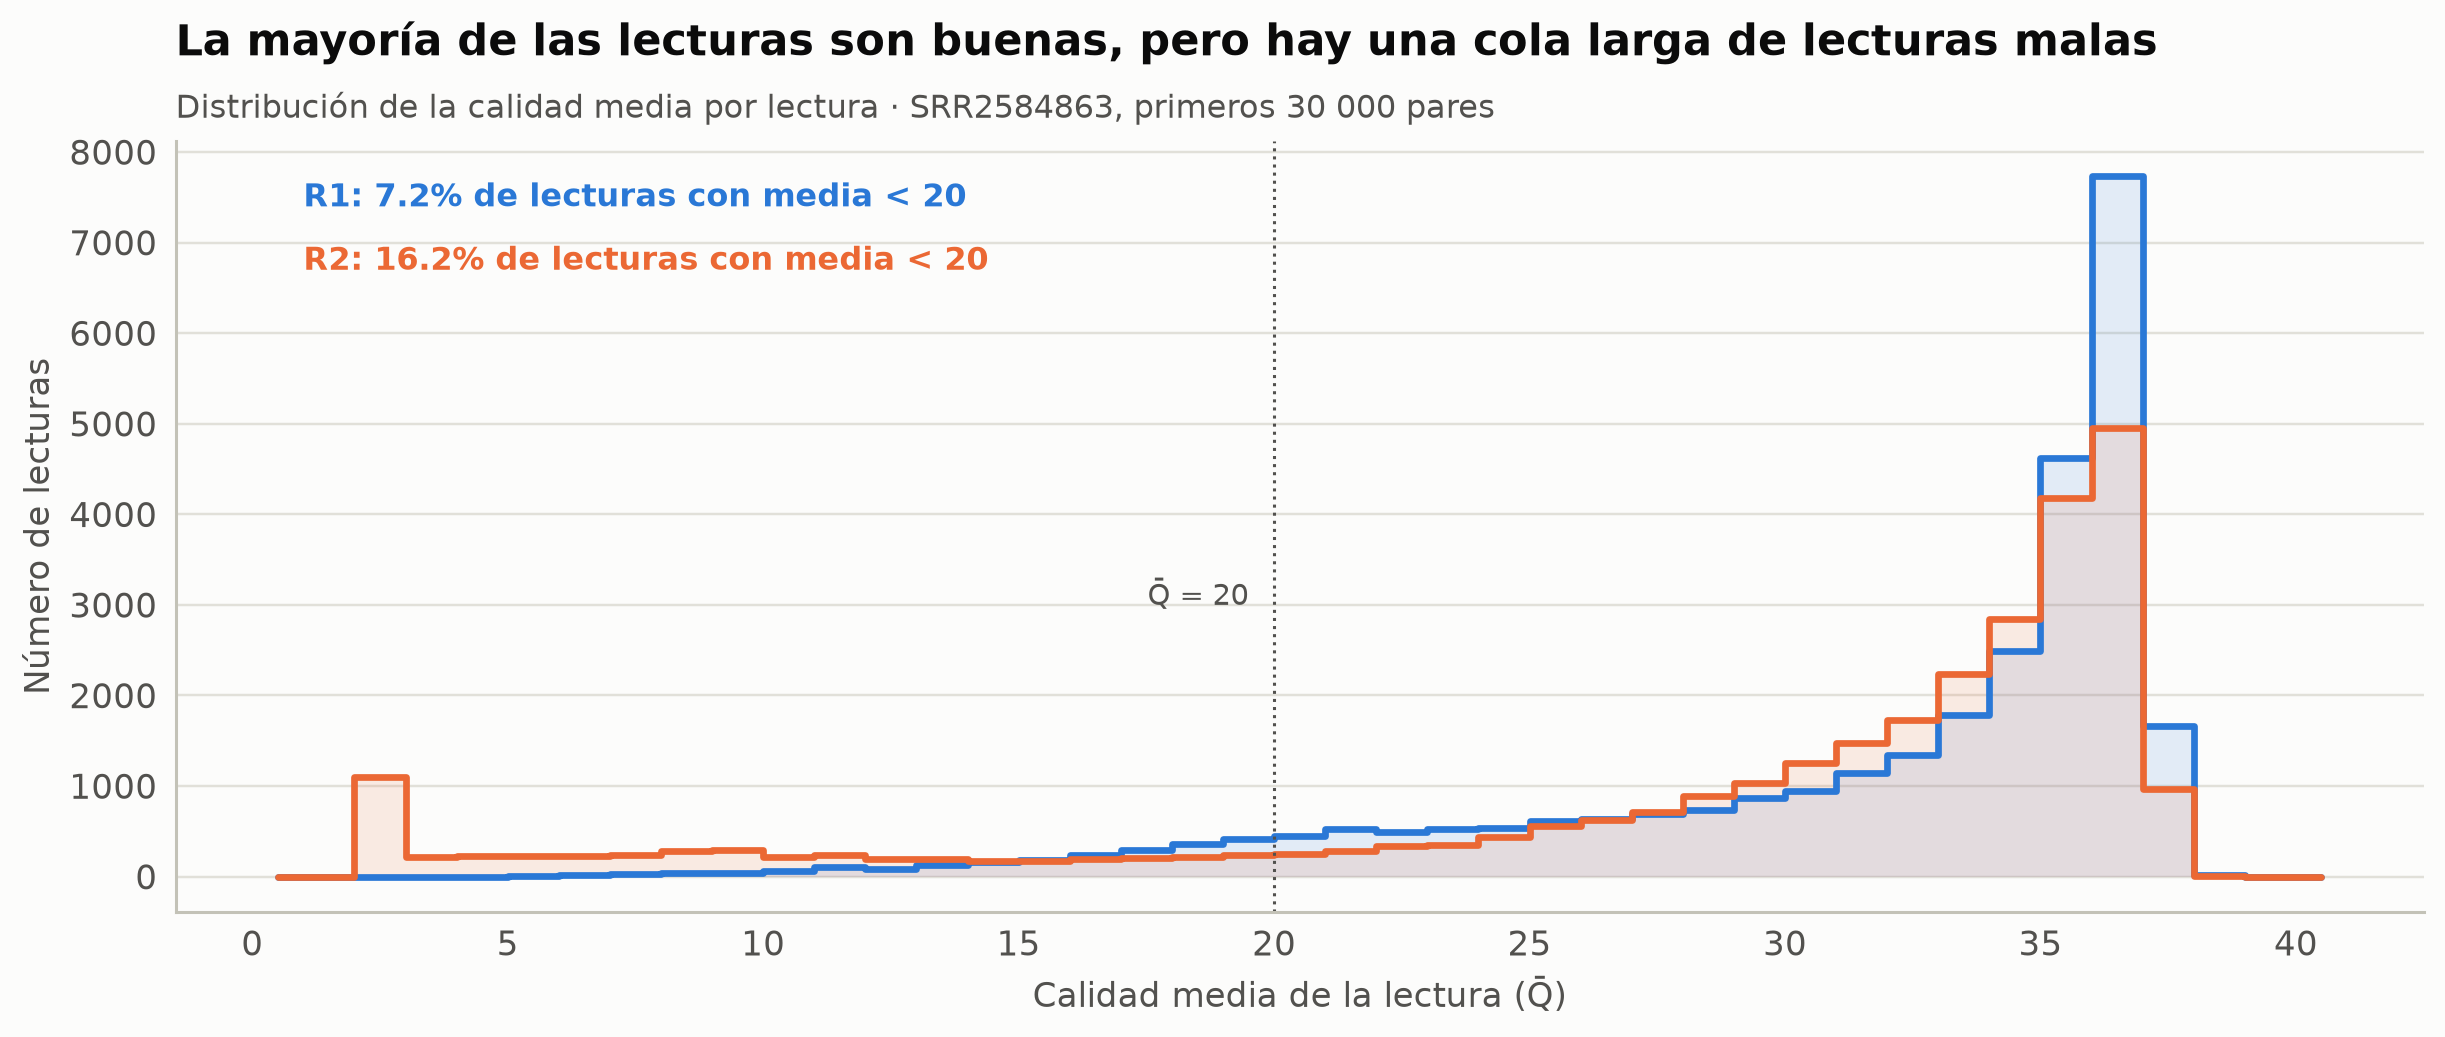

In [9]:
meanQ1, meanQ2 = Q1.mean(1), Q2.mean(1)
bins = np.arange(0, 42, 1)
fig, ax = plt.subplots(figsize=(11, 4.6))
for mq, col, lab, dy in [(meanQ1, ec.BLUE, "R1", 0), (meanQ2, ec.ORANGE, "R2", 1)]:
    h, _ = np.histogram(mq, bins=bins)
    ax.step(bins[:-1] + 0.5, h, where="mid", color=col, lw=2.2)
    ax.fill_between(bins[:-1] + 0.5, h, step="mid", color=col, alpha=0.12)
    ax.text(1, 7400 - 700 * dy, f"{lab}: {np.mean(mq < 20):.1%} de lecturas con media < 20",
            color=col, fontsize=10.5, fontweight="bold", ha="left")
ax.axvline(20, color=ec.INK_2, lw=1, ls=":")
ax.text(19.5, 3000, "Q̄ = 20", ha="right", fontsize=9.5, color=ec.INK_2)
ax.set_xlabel("Calidad media de la lectura (Q̄)"); ax.set_ylabel("Número de lecturas")
ec.title(ax, "La mayoría de las lecturas son buenas, pero hay una cola larga de lecturas malas",
         "Distribución de la calidad media por lectura · SRR2584863, primeros 30 000 pares")
plt.show()

> 🔎 **Qué observamos.** El pico principal está en Q̄ ≈ 36–37, pero hay una **cola** que se extiende hacia la
> izquierda, mucho más gruesa en R2. En R2 aparece además un pico aislado en Q̄ ≈ 2–3: unas mil lecturas que son
> `#` casi de principio a fin (el *cluster* se perdió durante la segunda lectura). Esas lecturas no son
> todas "malas de principio a fin": muchas empiezan bien y terminan en una larga racha de `#`. Por eso, en lugar de
> tirar la lectura entera, primero intentaremos **recortar** la parte mala (sección 7) y sólo después decidiremos si lo
> que queda sirve.

✅ **Compruebe su comprensión.** Una lectura de 150 bases tiene 100 bases con Q38 y 50 bases con Q2. ¿Cuál es su
calidad media? ¿Y si se recortan las 50 bases finales? (Respuesta: $(100 \cdot 38 + 50 \cdot 2)/150 = 26$, que
parece "aceptable"; tras el recorte, 38. La media mezcla dos poblaciones de bases muy distintas.)

## 4. Composición: contenido de bases por posición y contenido GC

### 4.1 Contenido de bases por posición

Si los fragmentos se cortaron **al azar** a lo largo del genoma, la base que aparece en la posición $j$ de las
lecturas es una muestra al azar del genoma, y la proporción de cada base debería ser la misma en todas las posiciones:
cuatro líneas planas y paralelas. Para cada posición $j$ y base $b$ calculamos

$$
f_b(j) \;=\; \frac{\#\{\text{lecturas con la base } b \text{ en la posición } j\}}{\#\{\text{lecturas con base definida (no N) en } j\}}
$$

| Símbolo | Significado |
|---|---|
| $b$ | una de las bases A, C, G, T |
| $j$ | posición (ciclo) en la lectura |
| $f_b(j)$ | fracción de lecturas que tienen la base $b$ en la posición $j$ |

En un genoma con GC ≈ 50.8 % como el de *E. coli*, esperamos $f_G \approx f_C \approx 0.254$ y
$f_A \approx f_T \approx 0.246$. Como cada lectura puede venir de cualquiera de las dos hebras, las reglas de Chargaff se
cumplen **dentro** de la lectura: $f_A \approx f_T$ y $f_G \approx f_C$. FastQC da una advertencia si en alguna posición
$|f_A - f_T|$ o $|f_G - f_C|$ supera el 10 %, y un fallo si supera el 20 %.

**Ejemplo a mano.** Si en la posición 1 de 1 000 lecturas vemos 222 A, 263 C, 376 G y 139 T, entonces
$f_G - f_C = 0.376 - 0.263 = 0.113$ y $f_A - f_T = 0.222 - 0.139 = 0.083$: **advertencia** de FastQC por el par G/C.

### ¿Por qué los primeros ciclos están sesgados?

Dos causas muy frecuentes (y ambas **inofensivas** si se reconocen):

* **Bibliotecas Nextera** (nuestro caso): el ADN se corta y se marca con adaptadores en un solo paso, con la
  **transposasa Tn5**. Tn5 no corta en cualquier sitio: prefiere ciertas secuencias en el punto de inserción
  (Adey *et al.*, 2010). Como la lectura empieza exactamente en el punto de inserción, las primeras ~15 bases
  "heredan" esa preferencia.
* **RNA-seq con hexámeros aleatorios**: la síntesis de ADNc se ceba con hexámeros "aleatorios" que en realidad no se
  unen con la misma eficiencia a todas las secuencias, y deja una huella en las primeras 10–13 bases
  (Hansen, Brenner y Dudoit, 2010).

En ambos casos el sesgo está en la **secuencia genómica real** del sitio de inicio, no son errores de lectura. Por eso
**no** se recomienda recortar esas bases: las lecturas alinean bien, y cortarlas sólo tira información.

In [10]:
def base_content(S):
    """Matriz 4 × L con la fracción de A, C, G y T en cada posición (sin contar N)."""
    counts = np.array([(S == ord(b)).sum(0) for b in BASES], dtype=float)
    return counts / np.maximum(counts.sum(0), 1)

bc1, bc2 = base_content(S1), base_content(S2)
tbl = pd.DataFrame(bc1[:, :12].T, columns=list(BASES), index=pd.RangeIndex(1, 13, name="posición"))
tbl["|A−T|"] = (tbl.A - tbl["T"]).abs(); tbl["|G−C|"] = (tbl.G - tbl.C).abs()
print("R1, primeras 12 posiciones:")
print(tbl.round(3).to_string())
print(f"\nPosiciones 20–150 (promedio): " + ", ".join(f"{b} = {bc1[i, 19:].mean():.3f}" for i, b in enumerate(BASES)))

R1, primeras 12 posiciones:
              A      C      G      T  |A−T|  |G−C|
posición                                          
1         0.222  0.263  0.376  0.139  0.084  0.113
2         0.198  0.274  0.157  0.371  0.173  0.117
3         0.250  0.259  0.206  0.285  0.036  0.052
4         0.185  0.319  0.140  0.356  0.171  0.179
5         0.332  0.168  0.148  0.353  0.021  0.020
6         0.343  0.157  0.316  0.183  0.160  0.159
7         0.295  0.227  0.256  0.221  0.075  0.029
8         0.337  0.216  0.252  0.195  0.142  0.036
9         0.159  0.393  0.237  0.211  0.052  0.155
10        0.244  0.282  0.183  0.291  0.047  0.099
11        0.217  0.190  0.381  0.212  0.005  0.191
12        0.226  0.269  0.233  0.272  0.047  0.036

Posiciones 20–150 (promedio): A = 0.249, C = 0.257, G = 0.249, T = 0.245


### Explorador interactivo del contenido de bases

Pase el cursor por cualquier posición: verá las cuatro fracciones a la vez y, en el recuadro, las desviaciones de
Chargaff que FastQC evalúa. Use el ratón para ampliar las primeras 15 posiciones y compare R1 con R2.

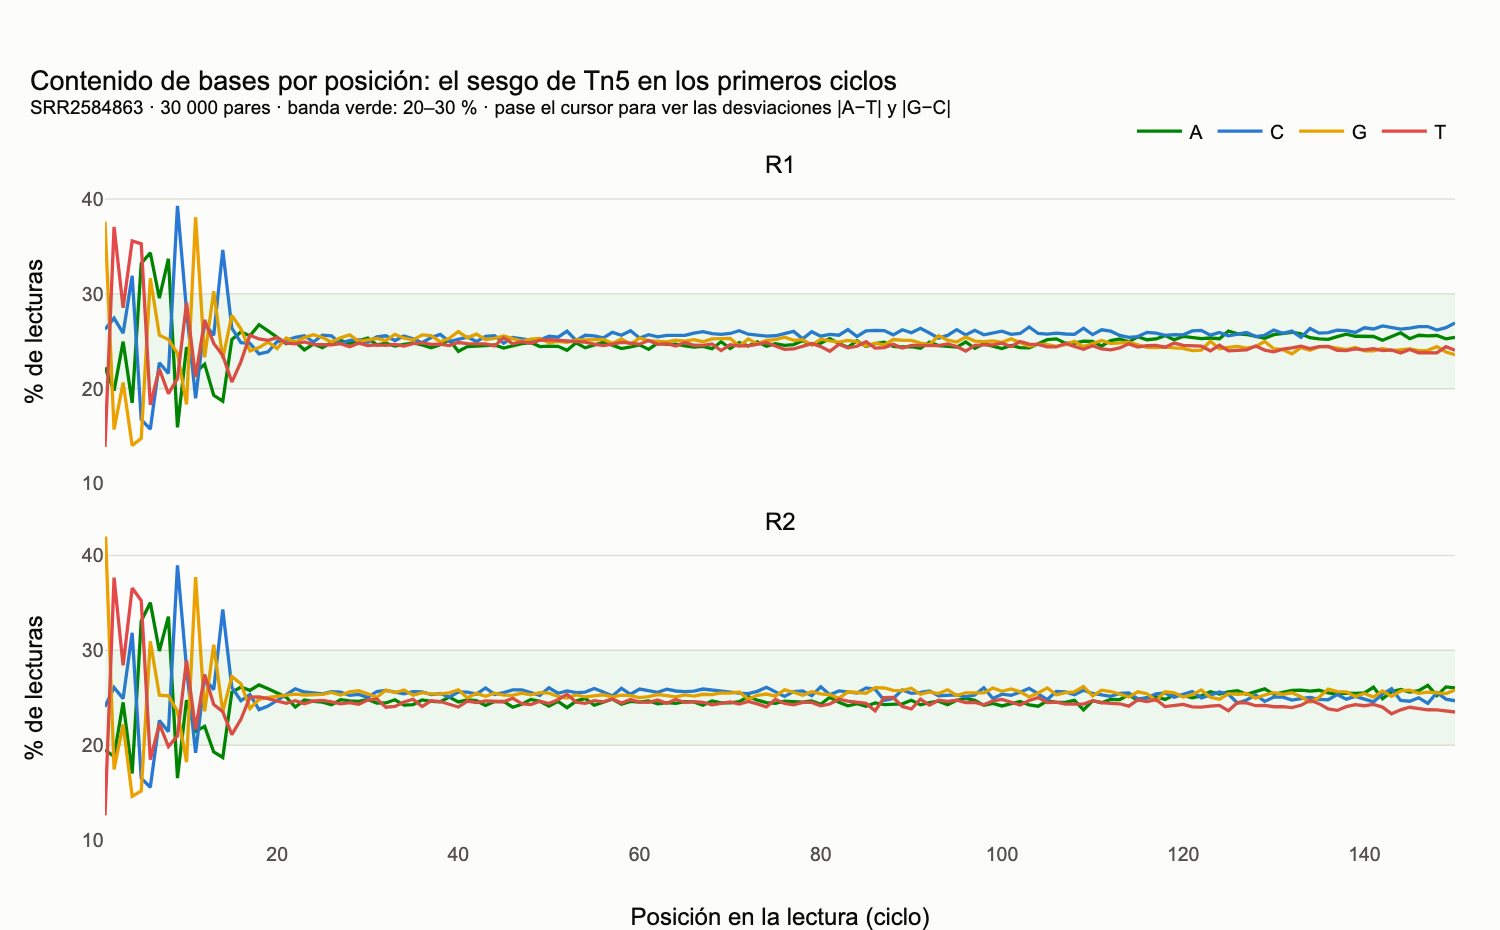

In [11]:
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.08, subplot_titles=("R1", "R2"))
pos = np.arange(1, L + 1)
for row, bc in [(1, bc1), (2, bc2)]:
    dev = np.c_[np.abs(bc[0] - bc[3]), np.abs(bc[2] - bc[1])]
    for i, b in enumerate(BASES):
        fig.add_scatter(x=pos, y=100 * bc[i], mode="lines", name=b, legendgroup=b, showlegend=(row == 1),
                        line=dict(color=ec.NUC_COLORS[b], width=2.2), customdata=100 * dev, row=row, col=1,
                        hovertemplate=(f"<b>{b}</b>: %{{y:.1f}} %" + ("<br>|A−T| = %{customdata[0]:.1f} pts · "
                                       "|G−C| = %{customdata[1]:.1f} pts" if b == "T" else "") + "<extra></extra>"))
    fig.add_hrect(y0=20, y1=30, fillcolor=ec.STATUS["good"], opacity=0.06, line_width=0, row=row, col=1)
fig.update_yaxes(title_text="% de lecturas", range=[10, 42])
fig.update_xaxes(title_text="Posición en la lectura (ciclo)", row=2, col=1)
fig.update_layout(
    title=dict(text="Contenido de bases por posición: el sesgo de Tn5 en los primeros ciclos<br>"
                    "<sup>SRR2584863 · 30 000 pares · banda verde: 20–30 % · pase el cursor para ver las desviaciones "
                    "|A−T| y |G−C|</sup>"),
    hovermode="x unified", height=620, margin=dict(t=120, l=70, r=30, b=60),
    legend=dict(orientation="h", yanchor="bottom", y=1.04, x=1, xanchor="right"))
fig.show()

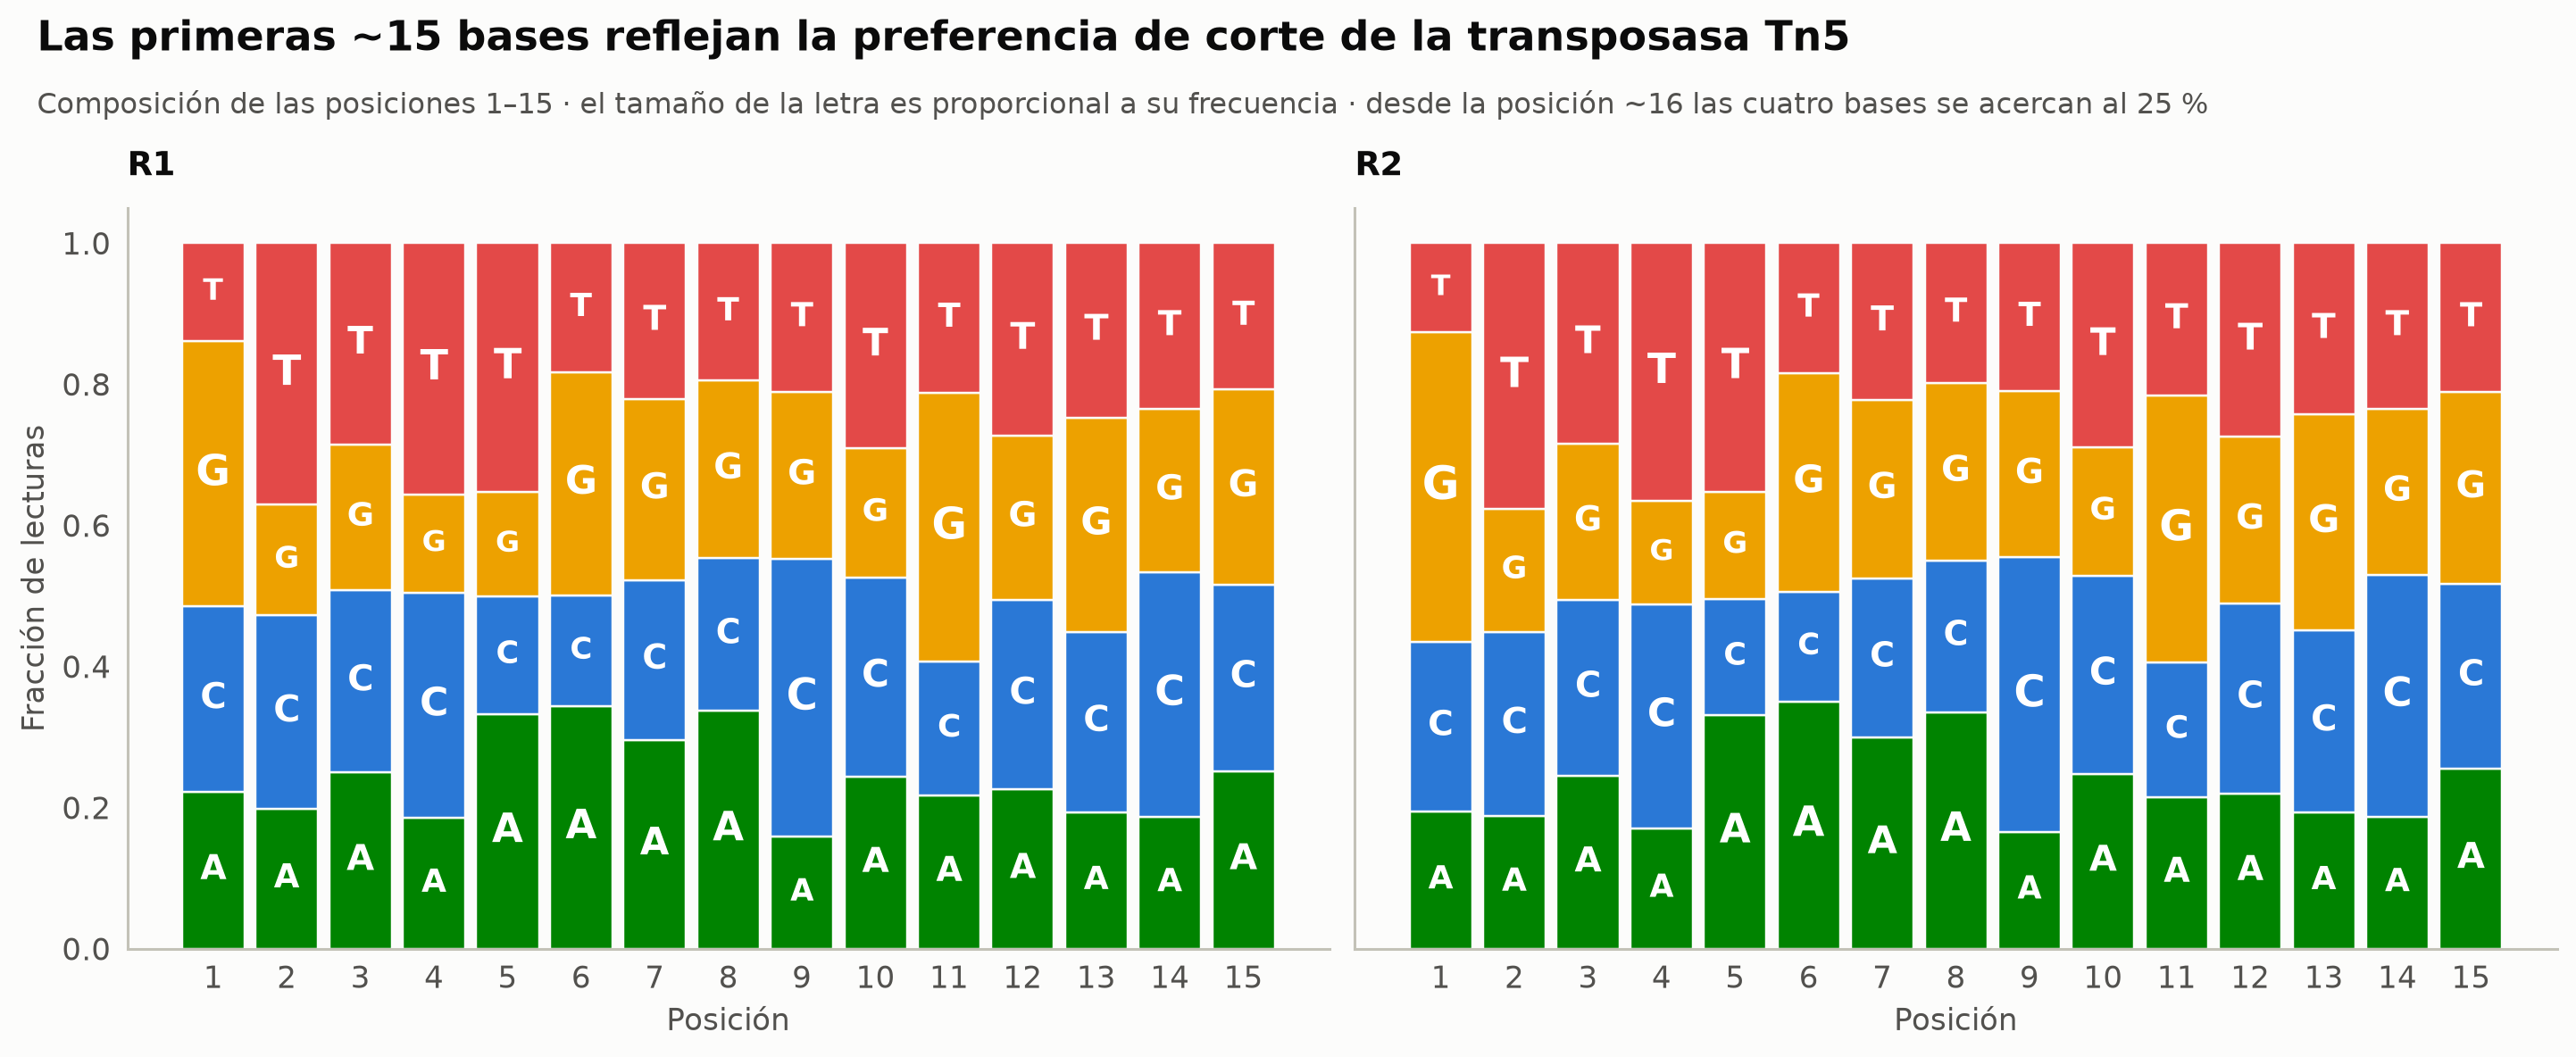

In [12]:
# Vista ampliada de las primeras 15 posiciones: barras apiladas con la letra de cada base
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
K = 15
for ax, bc, lab in [(axes[0], bc1, "R1"), (axes[1], bc2, "R2")]:
    bottom = np.zeros(K)
    for i, b in enumerate(BASES):
        ax.bar(np.arange(1, K + 1), bc[i, :K], bottom=bottom, color=ec.NUC_COLORS[b], width=0.85,
               edgecolor=ec.SURFACE, linewidth=0.8)
        for j in range(K):
            if bc[i, j] > 0.12:
                ax.text(j + 1, bottom[j] + bc[i, j] / 2, b, ha="center", va="center", color="white",
                        fontsize=8 + 20 * bc[i, j], fontweight="bold")
        bottom += bc[i, :K]
    ax.set_xticks(range(1, K + 1)); ax.set_xlabel("Posición"); ax.grid(False)
    ax.set_title(lab, loc="left", fontsize=12)
axes[0].set_ylabel("Fracción de lecturas")
ec.fig_title(fig, "Las primeras ~15 bases reflejan la preferencia de corte de la transposasa Tn5",
             "Composición de las posiciones 1–15 · el tamaño de la letra es proporcional a su frecuencia · "
             "desde la posición ~16 las cuatro bases se acercan al 25 %")
plt.show()

> 🔎 **Qué observamos.** Las cuatro líneas son planas y casi superpuestas desde la posición ~16 hasta el final: la
> composición promedio del genoma de *E. coli*. En las primeras posiciones, en cambio, hay un patrón fuerte y
> **reproducible**: G muy frecuente en la posición 1, T en la 2, A en las posiciones 5–8, C en la 9, G en la 11… hasta la posición 15 R1 y R2 muestran
> el **mismo** patrón porque ambas lecturas empiezan en un punto de inserción de Tn5. Un sesgo que se repite igual en
> las dos lecturas, en las mismas posiciones y sólo al principio, es la firma de la preparación de la biblioteca, no
> de un problema de secuenciación. FastQC marcaría este módulo en amarillo o rojo; un buen bioinformático lo reconoce
> y **no** recorta esas bases.

### 4.2 Contenido GC por lectura

Ahora contamos, en cada lectura, la fracción de bases G o C. ¿Qué forma debería tener esa distribución? Si el genoma
fuera una secuencia al azar con una proporción $g$ de GC, cada lectura de $n$ bases sería como lanzar $n$ monedas
cargadas, y el número de G+C seguiría una **distribución binomial**:

$$
P(k) = \binom{n}{k}\, g^{k} (1-g)^{n-k}, \qquad \mu = n g, \qquad \sigma = \sqrt{n\,g\,(1-g)}
$$

| Símbolo | Significado |
|---|---|
| $n$ | longitud de la lectura (150) |
| $k$ | número de bases G o C en la lectura |
| $g$ | proporción GC del genoma (0.508 en *E. coli*) |
| $\mu,\ \sigma$ | media y desviación estándar del número de G+C por lectura |

**Ejemplo a mano.** Con $n = 150$ y $g = 0.508$: $\mu = 76.2$ bases (50.8 %) y
$\sigma = \sqrt{150 \cdot 0.508 \cdot 0.492} = \sqrt{37.5} = 6.12$ bases, es decir, **4.1 puntos porcentuales**.

Pero un genoma real **no** es una secuencia al azar: tiene regiones más ricas y más pobres en GC (islas genómicas,
genes adquiridos por transferencia horizontal, ARN ribosómicos). Una expectativa mejor es tomar **ventanas de 150 pb
del propio genoma** y medir su GC. Como referencia usamos el genoma de *E. coli* K-12 MG1655 (NC_000913.3, que ya
está en el curso); es muy cercano a la cepa B REL606 (NC_012967.1) de nuestras lecturas.

Una distribución observada con **dos picos** o con un hombro lejos del esperado es una alarma clásica de
**contaminación** (otro organismo con distinto GC, adaptadores, *primer-dimers*).

> 🤔 **Antes de ejecutar, prediga:** ¿la distribución observada será más ancha o más estrecha que la binomial?
> ¿Y que la de las ventanas del genoma?

GC del genoma K-12: 0.5079 · σ binomial = 4.08%
         lecturas R1: media 50.55% · desviación estándar 6.56%
         lecturas R2: media 50.74% · desviación estándar 6.89%
 ventanas del genoma: media 50.79% · desviación estándar 6.78%


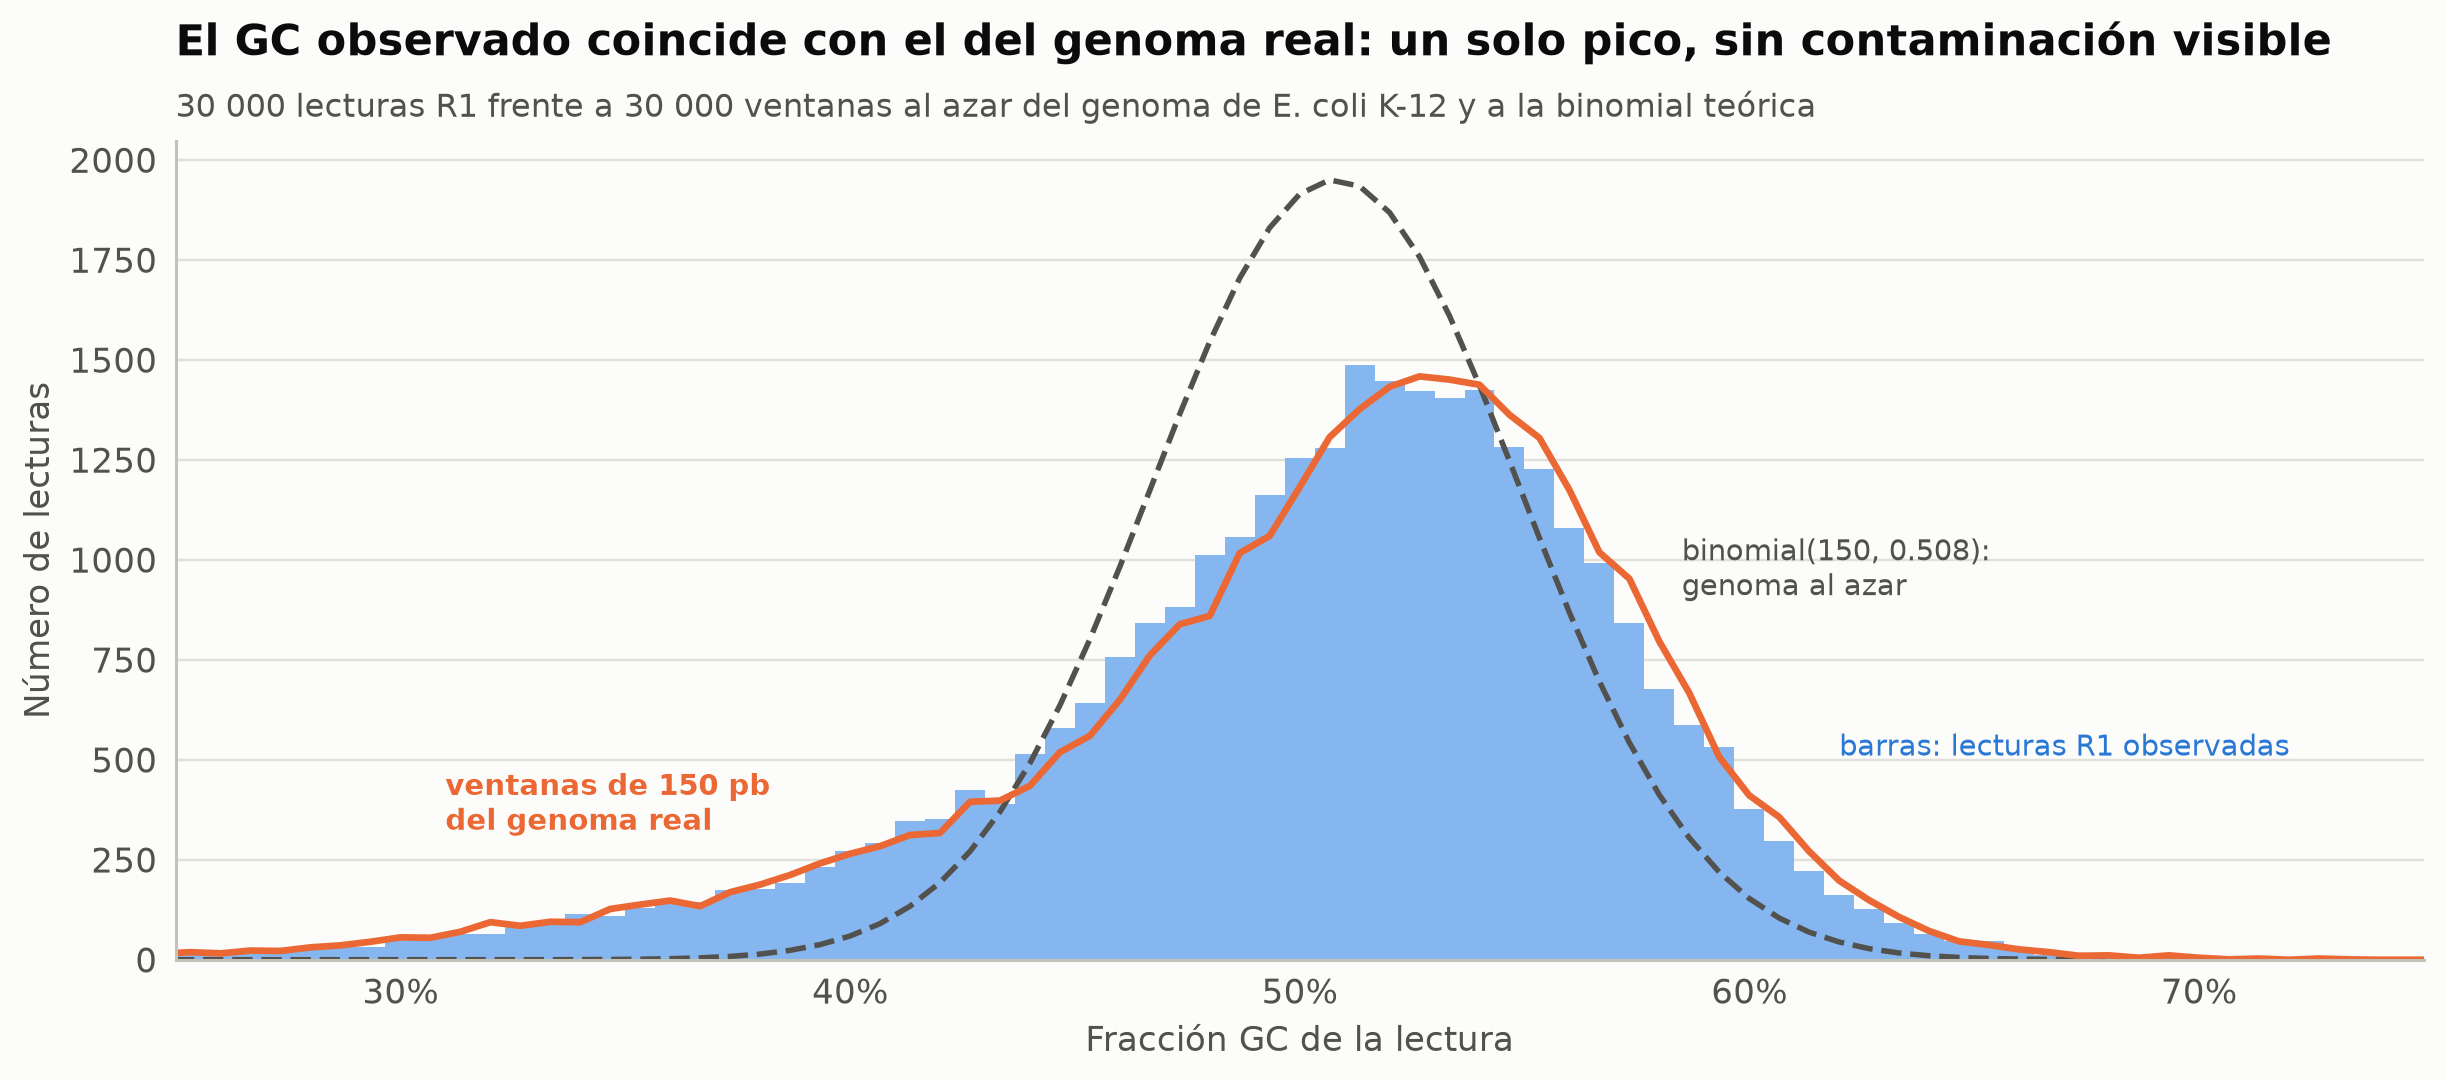

In [13]:
def gc_fraction(S):
    """Fracción de G+C de cada lectura (sin contar N)."""
    gc = ((S == ord("G")) | (S == ord("C"))).sum(1)
    acgt = gc + ((S == ord("A")) | (S == ord("T"))).sum(1)
    return gc / np.maximum(acgt, 1)

gc1, gc2 = gc_fraction(S1), gc_fraction(S2)

genome_raw = gzip.decompress(course_bytes("NC_000913.3.fasta.gz")).decode()
genome = "".join(genome_raw.split("\n", 1)[1].split())
G_arr = np.frombuffer(genome.encode(), np.uint8)
is_gc = ((G_arr == ord("G")) | (G_arr == ord("C"))).astype(np.int32)
cum = np.r_[0, np.cumsum(is_gc)]
starts = rng.integers(0, len(genome) - L, size=N)
gc_genome = (cum[starts + L] - cum[starts]) / L                  # GC de ventanas de 150 pb del genoma
g = is_gc.mean()

from scipy.stats import binom
k = np.arange(0, L + 1)
print(f"GC del genoma K-12: {g:.4f} · σ binomial = {np.sqrt(L * g * (1 - g)) / L:.2%}")
for lab, arr in [("lecturas R1", gc1), ("lecturas R2", gc2), ("ventanas del genoma", gc_genome)]:
    print(f"{lab:>20}: media {arr.mean():.2%} · desviación estándar {arr.std():.2%}")

fig, ax = plt.subplots(figsize=(11, 4.8))
edges = (np.arange(0, L + 2) - 0.5) / L
ax.hist(gc1, bins=edges, color=ec.SEQ_BLUE[3], label="observado (R1)")
ax.plot(k / L, N * binom.pmf(k, L, g), color=ec.INK_2, lw=1.8, ls="--")
h_gen, _ = np.histogram(gc_genome, bins=edges)
ax.plot(k / L, h_gen, color=ec.ORANGE, lw=2.2)
ax.text(0.585, N * binom.pmf(int(0.56 * L), L, g) * 1.05, "binomial(150, 0.508):\ngenoma al azar",
        color=ec.INK_2, fontsize=9.5)
ax.text(0.31, h_gen[int(0.40 * L)] + 60, "ventanas de 150 pb\ndel genoma real", color=ec.ORANGE, fontsize=9.5,
        ha="left", fontweight="bold")
ax.text(0.62, h_gen.max() * 0.35, "barras: lecturas R1 observadas", color=ec.BLUE, fontsize=9.5)
ax.set_xlim(0.25, 0.75); ax.set_xlabel("Fracción GC de la lectura"); ax.set_ylabel("Número de lecturas")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ec.title(ax, "El GC observado coincide con el del genoma real: un solo pico, sin contaminación visible",
         "30 000 lecturas R1 frente a 30 000 ventanas al azar del genoma de E. coli K-12 y a la binomial teórica")
plt.show()

> 🔎 **Qué observamos.** Las lecturas forman **un solo pico** centrado en ≈ 50.5 %, justo donde está el genoma. La
> binomial (línea discontinua) es **demasiado estrecha**: supone que el GC es igual en todo el genoma. Las ventanas del
> genoma real (naranja) son más anchas y describen muy bien las lecturas: la variación extra viene de la
> heterogeneidad del propio genoma, no de un problema de la biblioteca. Por eso FastQC, que compara con una curva
> normal ajustada a los propios datos, a veces "se queja" de distribuciones que en realidad son perfectamente normales
> para ese organismo.

✅ **Compruebe su comprensión.** Si una muestra de *E. coli* estuviera contaminada con un 10 % de lecturas de
*Staphylococcus aureus* (GC ≈ 33 %), ¿qué vería en este gráfico? (Respuesta: un segundo pico, más pequeño, alrededor
del 33 %, a la izquierda del principal.)

## 5. Bases N, duplicación y secuencias sobrerrepresentadas

### 5.1 Bases N por posición

Cuando el *basecaller* no puede decidir qué base hay en un ciclo (por ejemplo, porque el *cluster* se perdió de foco
en esa foto), escribe una **N** con calidad Q2. Unas pocas N dispersas son normales; un pico de N en un ciclo concreto
señala un problema de la corrida en ese ciclo (una foto mala, una burbuja de reactivo).

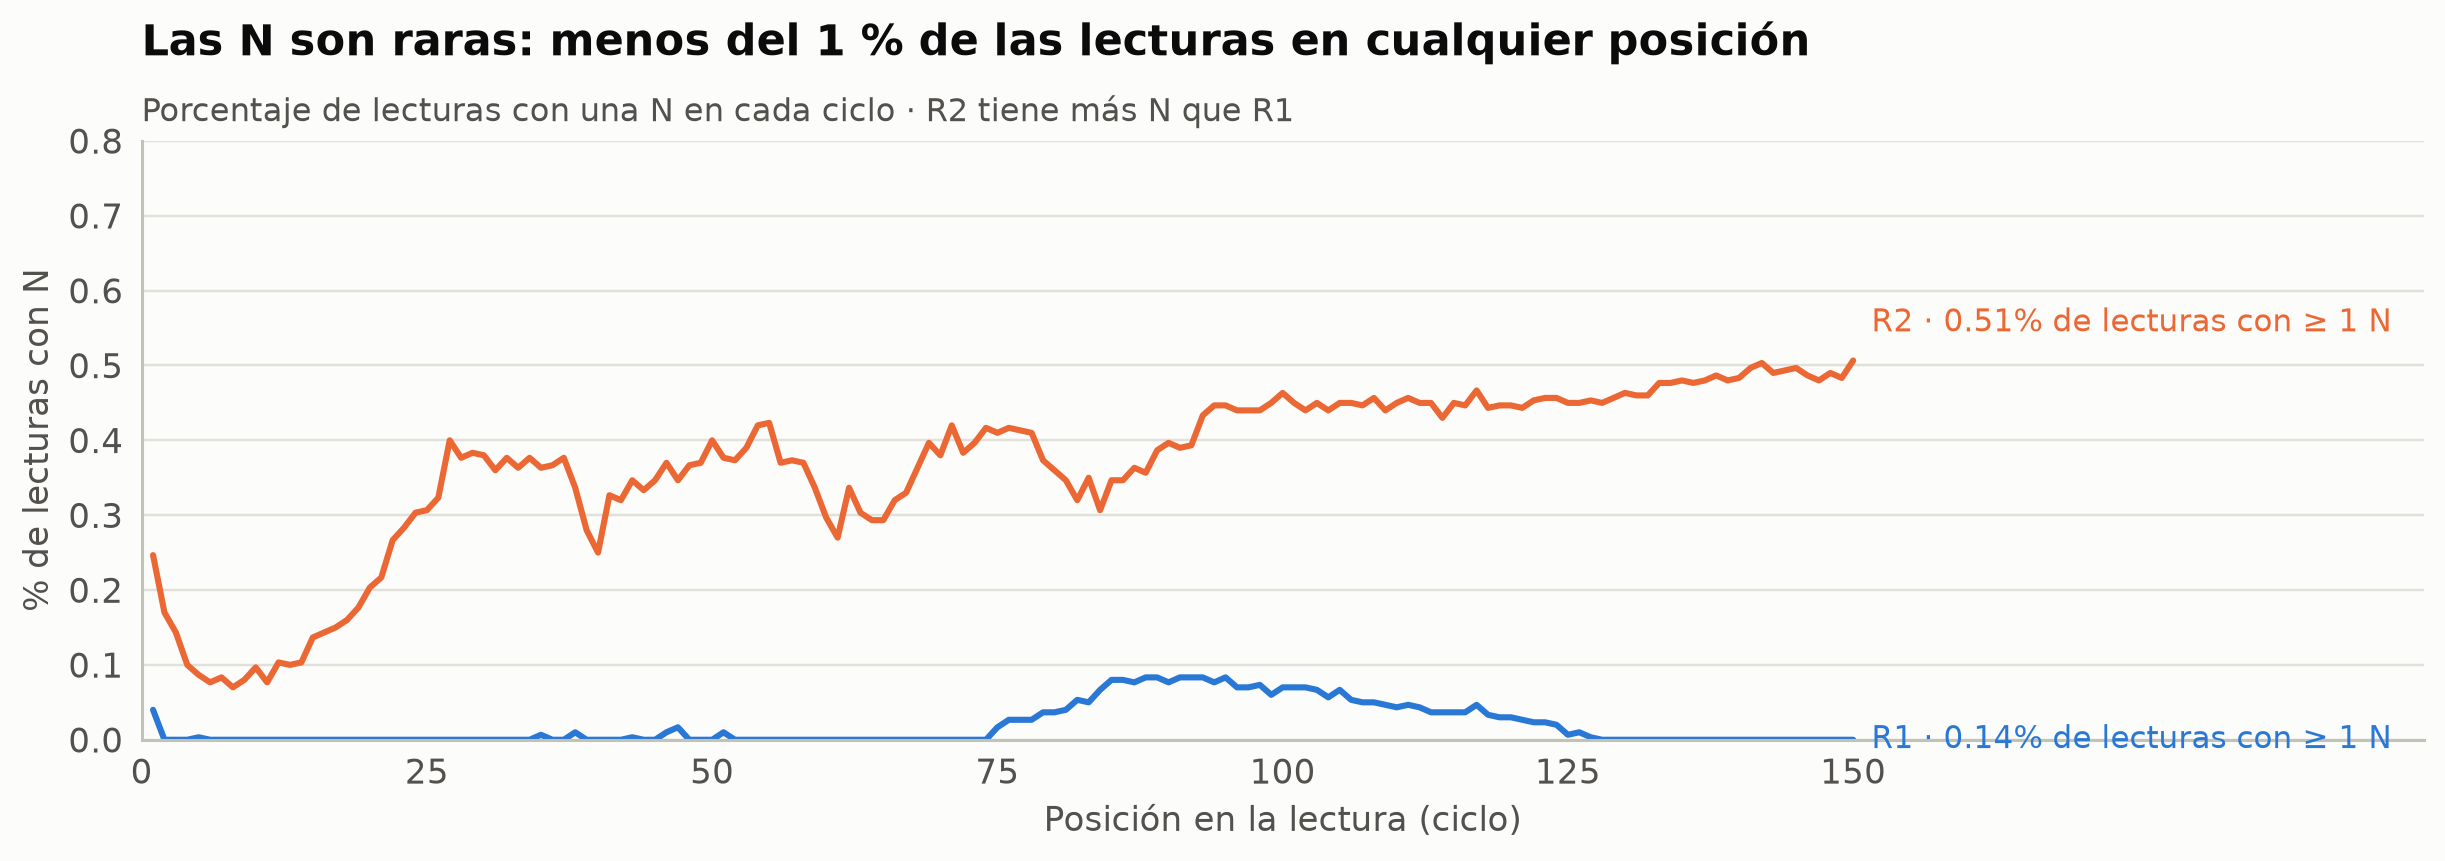

In [14]:
n_pos1, n_pos2 = (S1 == ord("N")).mean(0), (S2 == ord("N")).mean(0)
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(pos, 100 * n_pos1, color=ec.BLUE, lw=2)
ax.plot(pos, 100 * n_pos2, color=ec.ORANGE, lw=2)
ec.label_end(ax, L, 100 * n_pos1[-1], f"R1 · {(S1 == ord('N')).any(1).mean():.2%} de lecturas con ≥ 1 N", ec.BLUE)
ec.label_end(ax, L, 100 * n_pos2[-1] + 0.05, f"R2 · {(S2 == ord('N')).any(1).mean():.2%} de lecturas con ≥ 1 N", ec.ORANGE)
ax.set_xlim(0, L + 50); ax.set_xticks(range(0, L + 1, 25)); ax.set_ylim(0, max(0.8, 100 * n_pos2.max() * 1.3))
ax.set_xlabel("Posición en la lectura (ciclo)"); ax.set_ylabel("% de lecturas con N")
ec.title(ax, "Las N son raras: menos del 1 % de las lecturas en cualquier posición",
         "Porcentaje de lecturas con una N en cada ciclo · R2 tiene más N que R1")
plt.show()

> 🔎 **Qué observamos.** Las N son escasas (fracciones de un 1 %) y no forman picos en ciclos concretos: no hubo un
> ciclo defectuoso. R2 tiene algo más, sobre todo en unas pocas lecturas de los primeros *clusters* del archivo, que son
> casi todo N (la primera lectura R2 del archivo es un buen ejemplo: mire `seqs2[0]`). Esas lecturas las eliminará el
> filtro de N de la sección 9.

### 5.2 Niveles de duplicación: ¿cuántas lecturas idénticas esperamos por puro azar?

Un **duplicado** es un par de lecturas que proviene de la **misma molécula original**: por ejemplo, porque la PCR de la
biblioteca copió ese fragmento varias veces (duplicado de PCR) o porque el equipo leyó dos veces el mismo *cluster*
como si fueran dos vecinos (duplicado óptico). Los duplicados inflan la cobertura y pueden hacer que un error de PCR
parezca una variante confirmada por muchas lecturas.

Pero no toda coincidencia es un duplicado: dos fragmentos **distintos** pueden empezar, por azar, en la misma posición
del genoma. ¿Cuántas coincidencias así esperamos? El libro responde una pregunta gemela: si una biblioteca tiene $M$
moléculas distintas y secuenciamos $N$ lecturas al azar, una molécula concreta no es elegida por ninguna lectura con
probabilidad $(1 - 1/M)^N \approx e^{-N/M}$, así que el número esperado de moléculas **distintas** observadas es

$$
\mathbb{E}[D] \;=\; M\left[1 - \left(1 - \tfrac{1}{M}\right)^{N}\right] \;\approx\; M\left(1 - e^{-N/M}\right),
\qquad \text{tasa de duplicación esperada} \;=\; 1 - \frac{\mathbb{E}[D]}{N}.
$$

Aquí aplicamos la misma fórmula con otro "universo": en lugar de moléculas, las $M = 2G$ **posiciones de inicio**
posibles (dos hebras). Entonces $\mathbb{E}[D]$ es el número esperado de inicios distintos y lo que falta hasta $N$ son
las lecturas que repiten, por puro azar, el inicio de otra:

$$
R \;=\; N - \mathbb{E}[D] \;=\; N - M\left(1 - e^{-N/M}\right) \;\approx\; \frac{N^2}{2M} \quad (\text{si } N \ll M)
$$

| Símbolo | Significado |
|---|---|
| $N$ | número de lecturas secuenciadas (30 000) |
| $M$ | tamaño del "universo" del que se muestrea: en el libro, moléculas distintas de la biblioteca; aquí, posiciones de inicio posibles, $2G$ para lecturas sueltas |
| $G$ | tamaño del genoma (≈ 4.63 Mb para REL606) |
| $D$ | número de elementos distintos (moléculas o inicios) observados al menos una vez; $\mathbb{E}[D]$ es su valor esperado |
| $R$ | número esperado de lecturas que repiten el inicio de otra por azar, $N - \mathbb{E}[D]$ |

**Ejemplo a mano.** Primero el del libro: con $M = 10^7$ moléculas y $N = 2 \times 10^7$ lecturas,
$\mathbb{E}[D] = 10^7(1 - e^{-2}) \approx 8.65 \times 10^6$ y la tasa de duplicación es $1 - 8.65/20 \approx 57\,\%$.
Ahora nuestro caso, R1 sola: $M = 2 \times 4.63 \times 10^6 = 9.26 \times 10^6$ y
$R \approx 30\,000^2 / (2 \times 9.26 \times 10^6) = 9 \times 10^8 / 1.85 \times 10^7 \approx 49$ lecturas (0.16 %).
Para **pares**, además del inicio de R1 tendría que coincidir el de R2, es decir, el tamaño de inserto; con unos
~300 tamaños de inserto posibles, $M$ se multiplica por 300 y $R$ cae a $\approx 0.16$: prácticamente **cero**. Por eso
los programas que evalúan duplicados en datos pareados (Picard, fastp) usan **los dos extremos**.

In [15]:
def duplication_levels(keys):
    """Cuántas lecturas hay en cada nivel de duplicación (1 = única, 2 = aparece dos veces…)."""
    counts = Counter(keys)
    levels = Counter()
    for c in counts.values():
        levels[min(c, 10)] += c                     # lecturas (no secuencias) en ese nivel; 10 = "10 o más"
    return counts, levels

G_REL606 = 4_629_812                                # longitud del genoma de E. coli B REL606 (NC_012967.1)
M = 2 * G_REL606
E_D = M * (1 - np.exp(-N / M))                     # inicios distintos esperados, E[D]
R_exp = N - E_D                                     # lecturas que repiten un inicio por azar
print(f"Ejemplo del libro: M = 1e7, N = 2e7 → tasa de duplicación = {1 - 1e7 * (1 - np.exp(-2)) / 2e7:.0%}")
cnt_r1, lev_r1 = duplication_levels(seqs1)
cnt_pair, lev_pair = duplication_levels(zip(seqs1, seqs2))
dup_r1 = N - len(cnt_r1); dup_pair = N - len(cnt_pair)
print(f"Esperado por azar (R1 sola): E[D] = {E_D:,.1f} inicios distintos → R = N − E[D] = {R_exp:.1f} lecturas ({R_exp / N:.2%})")
print(f"Observado, R1 sola (150 nt idénticos): {dup_r1} lecturas ({dup_r1 / N:.2%})")
print(f"Observado, pares R1+R2 idénticos:     {dup_pair} lecturas ({dup_pair / N:.2%})")

# Pares casi idénticos (primeros 30 nt de R1 y de R2 iguales): ¿están cerca en la celda de flujo?
groups = {}
for i, key in enumerate(zip((s[:30] for s in seqs1), (s[:30] for s in seqs2))):
    groups.setdefault(key, []).append(i)
xy = np.array([[int(f[5]), int(f[6].split("/")[0])] for f in fields])
for idx in (v for v in groups.values() if len(v) > 1):
    d = np.hypot(*(xy[idx[0]] - xy[idx[1]]))
    print(f"Par casi duplicado: lecturas {idx} · tiles {tiles[idx].tolist()} · distancia = {d:.0f} píxeles")

Ejemplo del libro: M = 1e7, N = 2e7 → tasa de duplicación = 57%
Esperado por azar (R1 sola): E[D] = 29,951.5 inicios distintos → R = N − E[D] = 48.5 lecturas (0.16%)
Observado, R1 sola (150 nt idénticos): 147 lecturas (0.49%)
Observado, pares R1+R2 idénticos:     0 lecturas (0.00%)
Par casi duplicado: lecturas [14006, 14007] · tiles [1103, 1103] · distancia = 35 píxeles


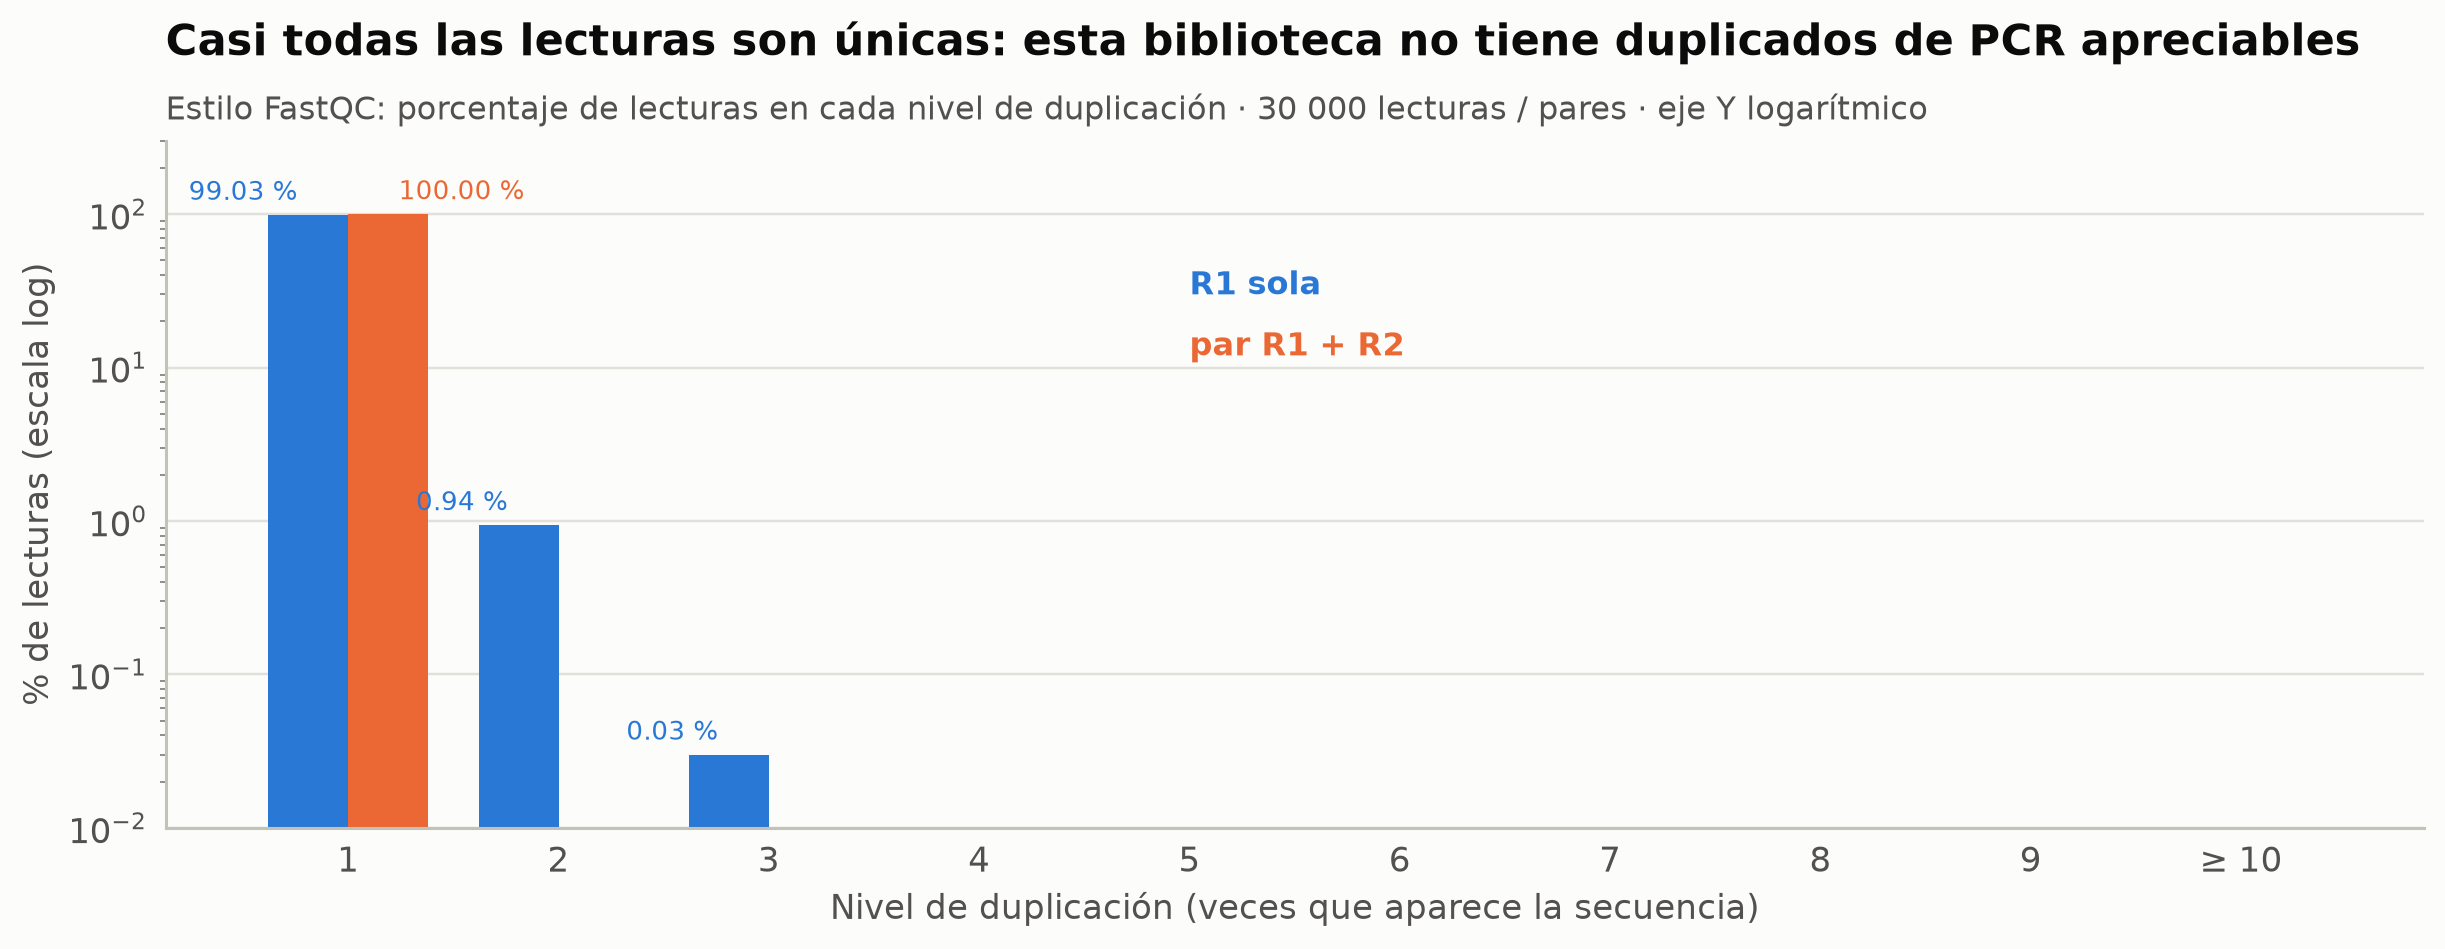

In [16]:
fig, ax = plt.subplots(figsize=(11, 4.2))
lv = np.arange(1, 11)
w = 0.38
for off, lev, col, lab in [(-w / 2, lev_r1, ec.BLUE, "R1 sola"), (w / 2, lev_pair, ec.ORANGE, "par R1 + R2")]:
    frac = np.array([lev.get(l, 0) for l in lv]) / N
    ax.bar(lv + off, 100 * frac, width=w, color=col)
    for l, f in zip(lv, frac):
        if f > 0:
            ax.text(l + off + (-0.05 if off < 0 else 0.05), 100 * f * 1.25, f"{100 * f:.2f} %",
                    ha="right" if off < 0 else "left", fontsize=8.5, color=col)
ax.text(5, 30, "R1 sola", color=ec.BLUE, fontsize=10.5, fontweight="bold")
ax.text(5, 12, "par R1 + R2", color=ec.ORANGE, fontsize=10.5, fontweight="bold")
ax.set_yscale("log")
ax.set_xticks(lv, [str(l) for l in lv[:-1]] + ["≥ 10"])
ax.set_xlabel("Nivel de duplicación (veces que aparece la secuencia)"); ax.set_ylabel("% de lecturas (escala log)")
ax.set_ylim(0.01, 300)
ec.title(ax, "Casi todas las lecturas son únicas: esta biblioteca no tiene duplicados de PCR apreciables",
         "Estilo FastQC: porcentaje de lecturas en cada nivel de duplicación · 30 000 lecturas / pares · eje Y logarítmico")
plt.show()

> 🔎 **Qué observamos.** Más del 99 % de las lecturas aparecen **una sola vez**. Con R1 sola vemos unas 150 lecturas
> repetidas (≈ 0.5 %), unas tres veces más que las ≈ 49 esperadas por azar: la preferencia de Tn5 por ciertos sitios
> y la cobertura no uniforme hacen que algunos puntos de inicio sean más probables que otros, así que las coincidencias
> son más frecuentes que en un reparto perfectamente uniforme. Pero cuando exigimos que coincida **el par completo**,
> los duplicados desaparecen: esas coincidencias eran fragmentos distintos que empezaban en el mismo sitio.
>
> El único par casi idéntico que aparece está en la **misma *tile*** y a unas decenas de píxeles de distancia: es un
> **duplicado óptico**, el mismo *cluster* detectado dos veces. Picard (`MarkDuplicates`) considera ópticos los
> duplicados a menos de 100 píxeles en celdas de flujo como la del HiSeq 2500.
>
> Con millones de lecturas la historia cambia: $R$ crece con $N^2$, y en un transcriptoma (donde unos pocos genes muy
> expresados acaparan las lecturas) la duplicación "natural" puede superar el 50 % sin que haya nada malo.

### 5.3 Secuencias sobrerrepresentadas y *k*-meros

FastQC busca secuencias que representen más del **0.1 %** de las lecturas (aquí, 30 lecturas o más), usando sólo las
primeras 50 bases cuando las lecturas son largas. Es la forma de encontrar contaminantes muy abundantes:
*primer-dimers*, adaptadores sin inserto, ARN ribosómico, el control PhiX…

In [17]:
first50 = Counter(s[:50] for s in seqs1)
top = pd.DataFrame(first50.most_common(5), columns=["primeras 50 bases de R1", "lecturas"])
top["% del total"] = (100 * top.lecturas / N).round(3)
print(f"Umbral de FastQC (0.1 %): {0.001 * N:.0f} lecturas")
top

Umbral de FastQC (0.1 %): 30 lecturas


,primeras 50 bases de R1,lecturas,% del total
0,ACATAGCCCCACTGTTCGTCCATTTCCGCGCAGACGATGACGTCAC...,3,0.01
1,ACCTGACCCCATGCCGAACTCAGAAGTGAAACGCCGTAGCGCCGAT...,3,0.01
2,CAGTAATATAAGCGAACTGAAGGATGCTGTTACGGAATATATTGAA...,3,0.01
3,ATCCAGTACAGCGCCGTGCCAAGATAGCGTGCTGTGGTTTCAACCT...,3,0.01
4,CGGTAACCTCGCGCATACAGCCGGGCAGTGACGTCATCGTCTGCGC...,3,0.01


Ninguna secuencia completa se acerca al umbral. Pero eso no significa que no haya nada repetido: el adaptador aparece
en **posiciones distintas** de cada lectura (depende del tamaño del inserto), así que nunca forma dos lecturas
idénticas. Para encontrarlo hay que contar **fragmentos cortos** de longitud $k$ (*k*-meros) en cualquier posición.

La celda convierte cada base en un número de 2 bits (A = 0, C = 1, G = 2, T = 3) y cada *k*-mero en un entero
$\sum_i 4^{k-1-i} x_i$, de modo que contar *k*-meros se reduce a contar enteros con NumPy, sin bucles sobre las
lecturas.

In [18]:
CODE = np.full(256, -1, dtype=np.int64)
for i, b in enumerate(BASES):
    CODE[ord(b)] = i

def kmer_codes(S, k):
    """Matriz n × (L−k+1) con el código entero de cada k-mero (−1 si contiene N)."""
    X = CODE[S]
    bad = X < 0
    Xc = np.where(bad, 0, X)
    width = S.shape[1] - k + 1
    codes = np.zeros((S.shape[0], width), dtype=np.int64)
    badw = np.zeros((S.shape[0], width), dtype=bool)
    for i in range(k):
        codes = codes * 4 + Xc[:, i:i + width]
        badw |= bad[:, i:i + width]
    codes[badw] = -1
    return codes

def decode(code, k):
    return "".join(BASES[(code >> (2 * (k - 1 - i))) & 3] for i in range(k))

K12 = 12
codes12_1 = kmer_codes(S1, K12)
vals, counts = np.unique(codes12_1[codes12_1 >= 0], return_counts=True)
order = np.argsort(counts)[::-1][:8]
print(f"12-meros distintos: {len(vals):,} · la mayoría aparece 1–3 veces")
print(pd.DataFrame({"12-mero": [decode(v, K12) for v in vals[order]], "apariciones": counts[order]}).to_string(index=False))

12-meros distintos: 2,653,429 · la mayoría aparece 1–3 veces
     12-mero  apariciones
CTGTCTCTTATA         3252
TGTCTCTTATAC         3236
GTCTCTTATACA         3197
TCTCTTATACAC         3168
CTCTTATACACA         3155
TCTTATACACAT         3114
CTTATACACATC         3076
TTATACACATCT         2989


> 🔎 **Qué observamos.** Los ocho 12-meros más frecuentes, con más de 3 000 apariciones cada uno, son **ventanas
> consecutivas de la misma secuencia**: `CTGTCTCTTATACACATCT`, el extremo del adaptador **Nextera** (la secuencia que
> reconoce la transposasa Tn5). El resto de los 12-meros del genoma aparecen apenas unas pocas veces. Así se descubre un
> adaptador aunque no sepamos de antemano qué kit se usó: fastp hace algo parecido para "adivinar" el adaptador en
> datos de un solo extremo.

## 6. Contenido de adaptadores

Ya sabemos qué adaptador buscar. Estas son las secuencias que conviene reconocer de memoria:

| Kit | Secuencia que aparece en el extremo 3′ de las lecturas | Comentario |
|---|---|---|
| Illumina **TruSeq** (y la mayoría de kits por ligación) | `AGATCGGAAGAGC` | común a R1 y R2 |
| Illumina **Nextera** / Nextera XT / DNA Prep (Tn5) | `CTGTCTCTTATACACATCT` | la "mosaic end" de Tn5; común a R1 y R2 |
| Illumina **small RNA** | `TGGAATTCTCGG` | bibliotecas de microARN |
| cola **poli-G** | `GGGGGGGGGG` | equipos de dos colores (NextSeq, NovaSeq): "sin señal" se lee como G |

El módulo *Adapter Content* de FastQC dibuja, para cada posición $j$, el **porcentaje acumulado** de lecturas en las que
el adaptador ya apareció en la posición $j$ o antes. La curva sólo puede subir: si una lectura tiene adaptador desde la
posición 80, también "tiene adaptador" en la 100 y en la 150.

**Ejemplo a mano.** Si de 10 lecturas, 1 tiene el adaptador desde la posición 40, 2 desde la 90 y 1 desde la 130, la
curva vale 0 % hasta la posición 39, 10 % entre la 40 y la 89, 30 % entre la 90 y la 129 y 40 % desde la 130.

In [19]:
ADAPTERS = {"Nextera": "CTGTCTCTTATACACATCT", "TruSeq": "AGATCGGAAGAGC", "small RNA": "TGGAATTCTCGG",
            "poli-G": "GGGGGGGGGGGG"}

def kmer_to_code(s):
    c = 0
    for ch in s:
        c = c * 4 + BASES.index(ch)
    return c

def adapter_first_hit(codes12, seq12):
    """Primera posición (0-based) donde aparece exactamente el 12-mero; −1 si no aparece."""
    hit = codes12 == kmer_to_code(seq12)
    return np.where(hit.any(1), hit.argmax(1), -1)

codes12_2 = kmer_codes(S2, K12)
content = {}
for mate, codes in [("R1", codes12_1), ("R2", codes12_2)]:
    for name, seq in ADAPTERS.items():
        first = adapter_first_hit(codes, seq[:K12])
        cum_frac = np.array([np.mean((first >= 0) & (first <= j)) for j in range(L)])
        content[(mate, name)] = (first, cum_frac)
    print(f"{mate}: " + " · ".join(f"{n} {content[(mate, n)][1][-1]:.2%}" for n in ADAPTERS))

R1: Nextera 10.84% · TruSeq 0.00% · small RNA 0.00% · poli-G 0.02%
R2: Nextera 10.85% · TruSeq 0.00% · small RNA 0.00% · poli-G 0.11%


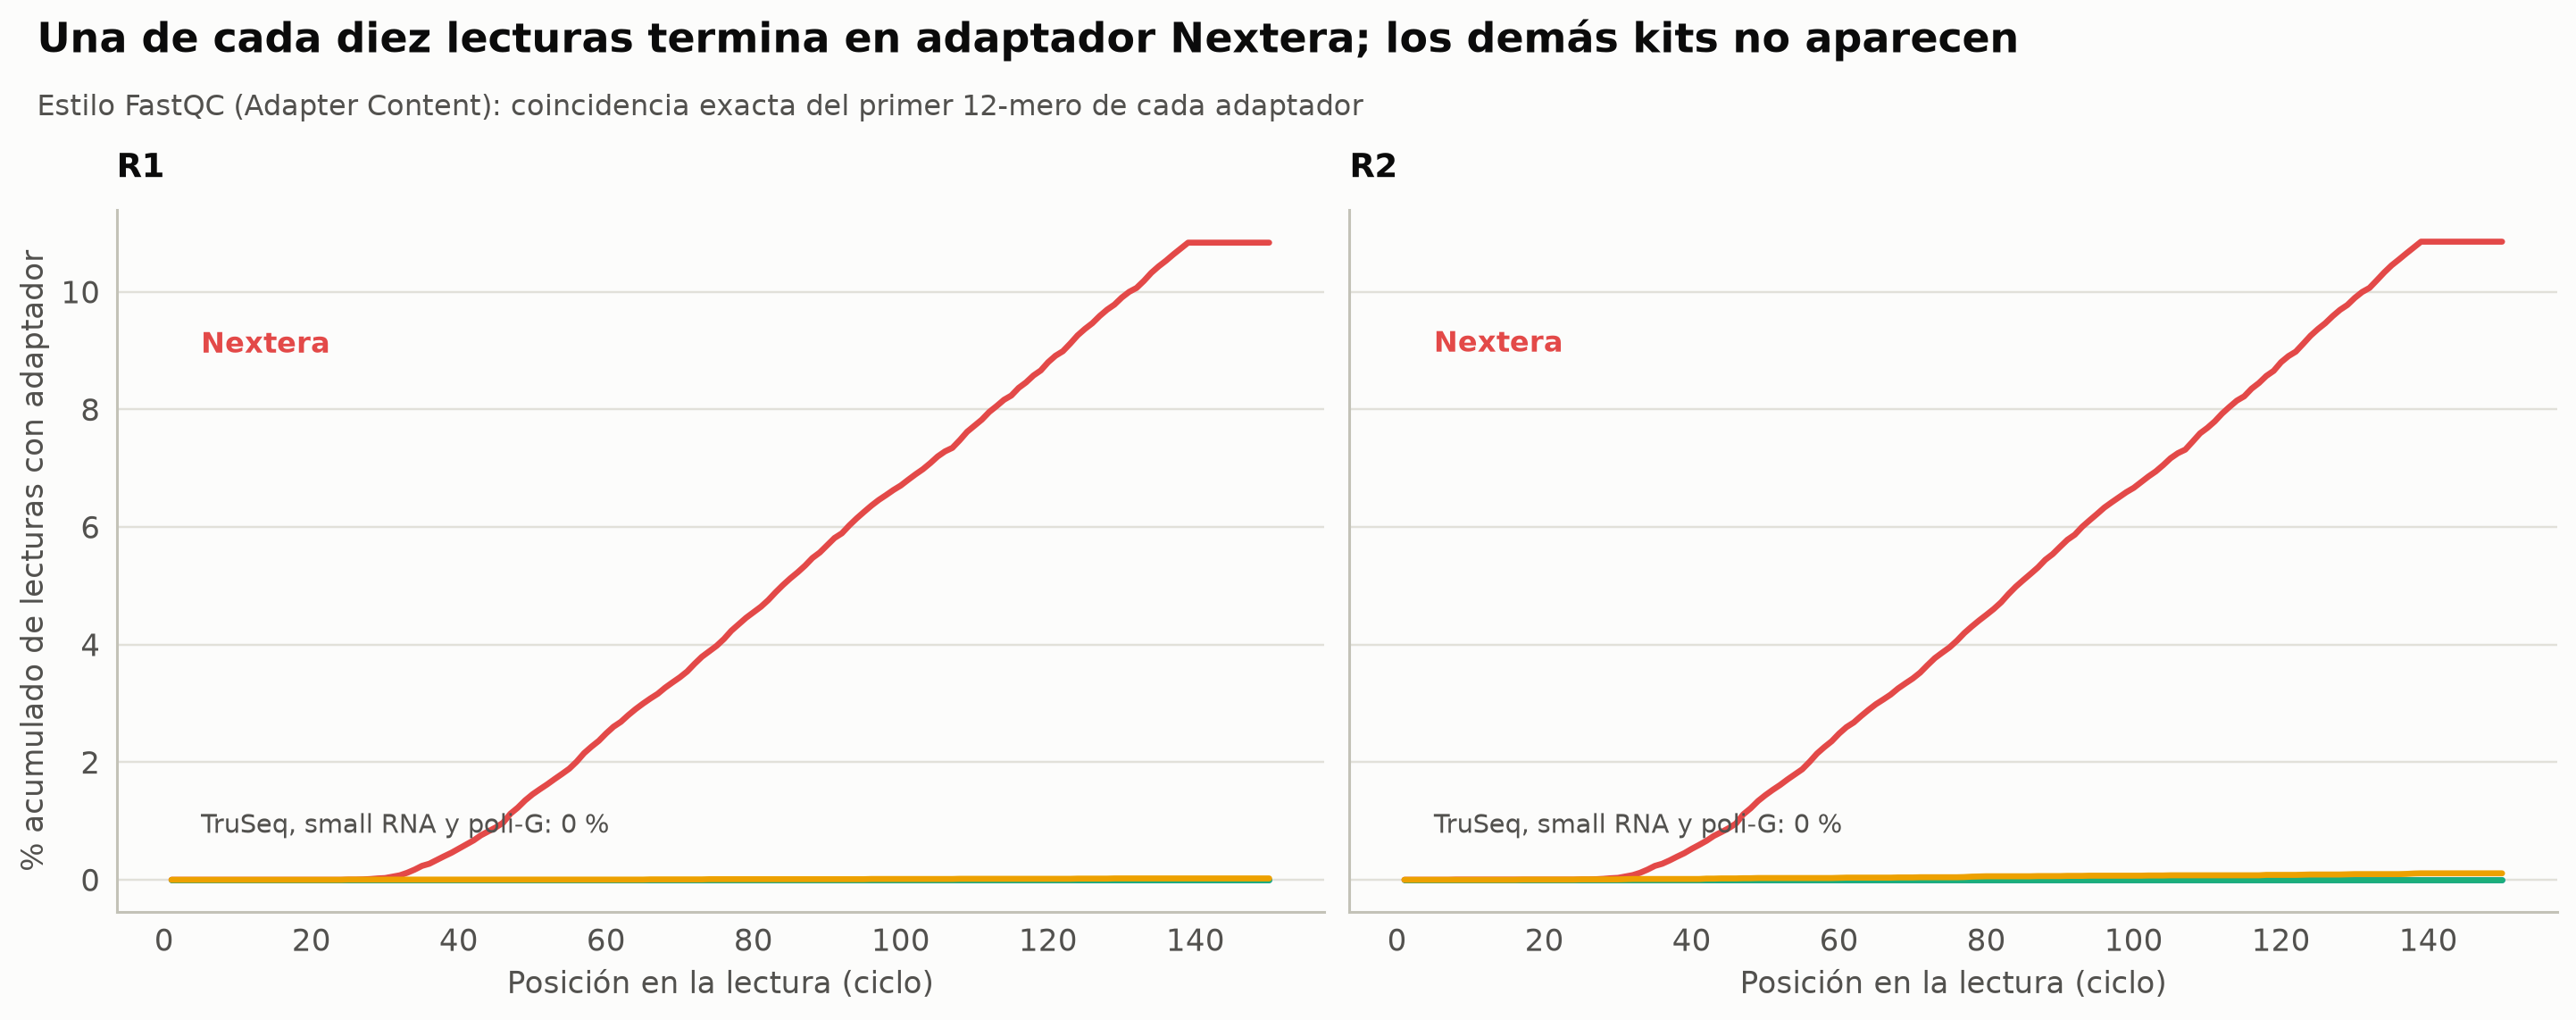

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
for ax, mate in zip(axes, ["R1", "R2"]):
    for (name, _), col in zip(ADAPTERS.items(), [ec.RED, ec.BLUE, ec.AQUA, ec.YELLOW]):
        cf = content[(mate, name)][1]
        ax.plot(pos, 100 * cf, color=col, lw=2.2)
    first = content[(mate, "Nextera")][0]
    ax.text(5, 100 * content[(mate, "Nextera")][1][-1] - 1.5, "Nextera", color=ec.RED, fontsize=10.5,
            fontweight="bold", va="top")
    ax.text(5, 0.8, "TruSeq, small RNA y poli-G: 0 %", color=ec.INK_2, fontsize=9.5)
    ax.set_title(mate, loc="left", fontsize=12); ax.set_xlabel("Posición en la lectura (ciclo)")
axes[0].set_ylabel("% acumulado de lecturas con adaptador")
ec.fig_title(fig, "Una de cada diez lecturas termina en adaptador Nextera; los demás kits no aparecen",
             "Estilo FastQC (Adapter Content): coincidencia exacta del primer 12-mero de cada adaptador")
plt.show()

> 🔎 **Qué observamos.** La curva de Nextera empieza a subir hacia la posición 20–30 y llega a ≈ 11 % al final de la
> lectura, casi igual en R1 y R2: son los pares cuyo inserto mide menos de 150 pb, que atraviesan el fragmento desde
> ambos lados (recuerde la figura de la sección 1). TruSeq, small RNA y poli-G son planos en 0: confirma el kit, y
> nos dice que **no** hace falta pasar esos adaptadores a la herramienta de recorte.
>
> Hay un detalle importante: la búsqueda exacta de 12 bases **no ve** los adaptadores que aparecen en las **últimas
> 11 posiciones** (no caben 12 bases) ni los que tienen un error de secuenciación dentro de esas 12 bases. Esas
> lecturas conservarían un trocito de adaptador si sólo recortáramos con este método. La sección 8 resuelve los dos
> problemas.

## 7. Recorte por calidad: ventana deslizante, BWA y Mott

Ya vimos que muchas lecturas empiezan bien y terminan mal. La solución no es tirarlas, sino **recortar** la parte mala
y quedarnos con el tramo confiable. Hay que decidir **dónde cortar**, y para eso existen varios algoritmos. Los tres más
usados se entienden con la misma idea: fijamos un umbral de calidad $t$ (por ejemplo 20, es decir, 1 error en 100) y
buscamos el tramo de la lectura que "vale la pena" conservar. (Usamos $t$, como el libro, porque $q$ ya designa la
probabilidad de *pre-phasing* de la sección 3.)

### 7.1 Los tres algoritmos

**(a) Ventana deslizante** (Trimmomatic `SLIDINGWINDOW:w:t`, fastp `--cut_right`). Recorremos la lectura de izquierda
a derecha con una ventana de $w$ bases y calculamos la calidad media dentro de la ventana. En cuanto una ventana tiene
media menor que $t$, cortamos **al principio de esa ventana** y tiramos todo lo que sigue. Es como caminar por un
sendero mirando los próximos cuatro pasos: en cuanto el tramo que viene se ve demasiado embarrado, damos la vuelta.
La lectura se trunca en

$$
x^{\star} \;=\; \min\Big\{\, x \;:\; \tfrac{1}{w}\textstyle\sum_{i=x}^{x+w-1} Q_i < t \,\Big\},
\qquad \text{y se conservan las bases } 1, \ldots, x^{\star} - 1 .
$$

**(b) Suma acumulada desde el extremo 3′** (heredada de BWA, `bwa aln -q`, y usada por `cutadapt -q`). En lugar de
detenerse en la primera zona mala, mira **toda la cola** de la lectura. Para cada posible punto de corte $x$ suma,
sobre las bases que quedarían fuera ($x, \ldots, L$), cuánto les falta para llegar al umbral, $t - Q_i$. Las bases
malas suman (conviene quitarlas); las buenas restan (cuesta perderlas). Se corta donde esa suma es máxima:

$$
x^{\star} \;=\; \underset{x}{\operatorname{arg\,max}} \; S(x), \qquad S(x) \;=\; \sum_{i=x}^{L} (t - Q_i),
\qquad \text{y se conservan las bases } 1, \ldots, x^{\star} - 1 .
$$

Dos detalles que el libro hace explícitos y que cambian el resultado: **(i)** si varios $x$ empatan en el máximo, se
elige el **más cercano al extremo 3′**, que conserva más bases; **(ii)** las implementaciones reales recorren la
lectura desde 3′ y **se detienen en cuanto la suma acumulada se vuelve negativa** (y si el máximo no es positivo, no se
recorta nada). Es el problema del segmento de suma máxima de Smith-Waterman, restringido a sufijos.

**(c) Segmento de máxima suma de Mott** (el método clásico de *phred*, usado por `seqtk trimfq`). Busca el tramo
contiguo $[a, b]$ con la mayor "ganancia" total, y por eso puede recortar **los dos extremos**. En *phred* y en
`seqtk trimfq` la ganancia de cada base se mide en **probabilidades de error**: $p_{\text{lím}} - p_i$, con
$p_i = 10^{-Q_i/10}$ y un límite $p_{\text{lím}}$ (0.05 por defecto en `seqtk trimfq`). En esta lección usamos la
**variante en escala Phred**, que mide la ganancia como $Q_i - t$; el algoritmo es idéntico, sólo cambia la puntuación:

$$
(\hat a, \hat b) \;=\; \underset{a \le b}{\operatorname{arg\,max}} \; \sum_{i=a}^{b} (Q_i - t)
\qquad\Big(\text{en } \textit{phred}/\texttt{seqtk}: \; \underset{a \le b}{\operatorname{arg\,max}} \sum_{i=a}^{b} (p_{\text{lím}} - p_i)\Big)
$$

Se resuelve en una sola pasada con la suma acumulada $C_j = \sum_{i \le j}(Q_i - t)$: el mejor tramo que termina en
$b$ empieza justo después del **mínimo** de $C$ anterior a $b$ (es el algoritmo de Kadane para el subarreglo de máxima
suma).

| Símbolo | Significado |
|---|---|
| $Q_i$ | calidad Phred de la base en la posición $i$ (1 … $L$) |
| $t$ | umbral de calidad (típicamente 15–20) |
| $w$ | tamaño de la ventana (típicamente 4) |
| $x^{\star}$ | **primera posición eliminada**; se conservan las bases $1 \ldots x^{\star}-1$ (nuestras funciones de Python devuelven directamente ese número de bases conservadas, $x^{\star}-1$) |
| $S(x)$ | "ganancia" de eliminar las bases $x \ldots L$ en el criterio de suma acumulada |
| $\hat a,\ \hat b$ | inicio y fin del tramo que se conserva en el método de Mott |
| $C_j$ | suma acumulada de $Q_i - t$ hasta la posición $j$ |
| $p_i,\ p_{\text{lím}}$ | probabilidad de error de la base $i$ y límite de probabilidad en la versión de *phred*/`seqtk` |

### 7.2 Ejemplo a mano: una lectura de 15 bases

Tomemos $t = 20$, $w = 4$ y esta lectura, con una base mala al principio, un "bache" en las posiciones 6–7 y una cola
mala:

| Posición $i$ | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12 | 13 | 14 | 15 |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| $Q_i$ | 8 | 38 | 37 | 36 | 35 | 10 | 6 | 30 | 33 | 32 | 31 | 15 | 12 | 10 | 8 |
| media de la ventana $i \ldots i{+}3$ | 29.75 | 36.5 | 29.5 | 21.75 | 20.25 | **19.75** | 25.25 | 31.5 | 27.75 | 22.5 | 17.0 | 11.25 | | | |
| $t - Q_i$ | 12 | −18 | −17 | −16 | −15 | 10 | 14 | −10 | −13 | −12 | −11 | 5 | 8 | 10 | 12 |
| $S(i) = \sum_{k \ge i} (t - Q_k)$ | −41 | −53 | −35 | −18 | −2 | 13 | 3 | −11 | −1 | 12 | 24 | **35** | 30 | 22 | 12 |
| $C_i = \sum_{k \le i}(Q_k - t)$ | −12 | 6 | 23 | 39 | 54 | 44 | 30 | 40 | 53 | 65 | **76** | 71 | 63 | 53 | 41 |

* **Ventana deslizante:** la primera ventana con media < 20 es la que empieza en la posición 6 (19.75), así que
  $x^{\star} = 6$ y se conservan las posiciones **1–5** (5 bases). El bache la hizo detenerse, aunque después venían
  4 bases excelentes.
* **Suma acumulada (BWA/cutadapt):** el máximo de $S$ es 35, en $x^{\star} = 12$. Se conservan **1–11** (11 bases):
  el bache se queda, porque quitarlo obligaría a quitar también 30, 33, 32, 31, que valen más.
* **Mott (escala Phred):** el mínimo de $C$ antes del máximo ($C_{11} = 76$) es $C_1 = -12$; el tramo es **2–11** con
  suma $76 - (-12) = 88$ (10 bases). Como BWA, conserva el bache; pero además elimina la base mala del principio.

Tres algoritmos razonables, tres respuestas distintas: 5, 11 y 10 bases. Ninguno es "el correcto"; cada uno encarna un
compromiso distinto entre perder bases buenas y conservar bases malas.

In [21]:
def trim_sliding(q_read, w=4, t=20):
    """Ventana deslizante: nº de bases conservadas (x* − 1), cortando al inicio de la 1.ª ventana con media < t."""
    for j in range(len(q_read) - w + 1):
        if np.mean(q_read[j:j + w]) < t:
            return j
    return len(q_read)

def trim_bwa(q_read, t=20):
    """Suma acumulada desde 3′ (BWA / cutadapt -q): nº de bases conservadas, x* − 1.
    x* maximiza S(x) = Σ_{i≥x} (t − Q_i); los empates se resuelven hacia el extremo 3′ (se conservan más bases)."""
    S = np.cumsum((t - np.asarray(q_read))[::-1])[::-1]         # S[k] = suma de t − Q desde k (base 0) hasta el final
    k = len(S) - 1 - int(np.argmax(S[::-1]))                     # argmax buscando desde 3′ → el máximo más a la derecha
    return k if S[k] > 0 else len(q_read)

def max_segment(scores):
    """Kadane: (inicio, fin) del tramo contiguo de máxima suma. Intervalo semiabierto [a, b)."""
    best, a_best, b_best, run, start = 0, 0, 0, 0, 0
    for i, v in enumerate(scores):
        if run + v <= 0:
            run, start = 0, i + 1                                # empezar de nuevo después de esta base
        else:
            run += v
            if run > best:
                best, a_best, b_best = run, start, i + 1
    return a_best, b_best

def trim_mott(q_read, t=20):
    """Mott en escala Phred: tramo de máxima suma de (Q − t)."""
    return max_segment(np.asarray(q_read) - t)

def trim_mott_prob(q_read, p_lim=0.05):
    """Mott como en phred / seqtk trimfq: tramo de máxima suma de (p_lím − p_i), con p_i = 10^(−Q/10)."""
    return max_segment(p_lim - 10 ** (-np.asarray(q_read) / 10))

toy = np.array([8, 38, 37, 36, 35, 10, 6, 30, 33, 32, 31, 15, 12, 10, 8])
a, b = trim_mott(toy)
print("Ventana deslizante (w=4, t=20): conserva posiciones 1 –", trim_sliding(toy))
print("Suma desde 3′ (t=20):           conserva posiciones 1 –", trim_bwa(toy))
print(f"Mott, escala Phred (t=20):      conserva posiciones {a + 1} – {b}  (suma = {np.sum(toy[a:b] - 20)})")
for p_lim in (0.01, 0.05):
    ap, bp = trim_mott_prob(toy, p_lim)
    print(f"Mott, probabilidades (p_lím={p_lim}): conserva posiciones {ap + 1} – {bp}")

Ventana deslizante (w=4, t=20): conserva posiciones 1 – 5
Suma desde 3′ (t=20):           conserva posiciones 1 – 11
Mott, escala Phred (t=20):      conserva posiciones 2 – 11  (suma = 88)
Mott, probabilidades (p_lím=0.01): conserva posiciones 2 – 5
Mott, probabilidades (p_lím=0.05): conserva posiciones 8 – 12


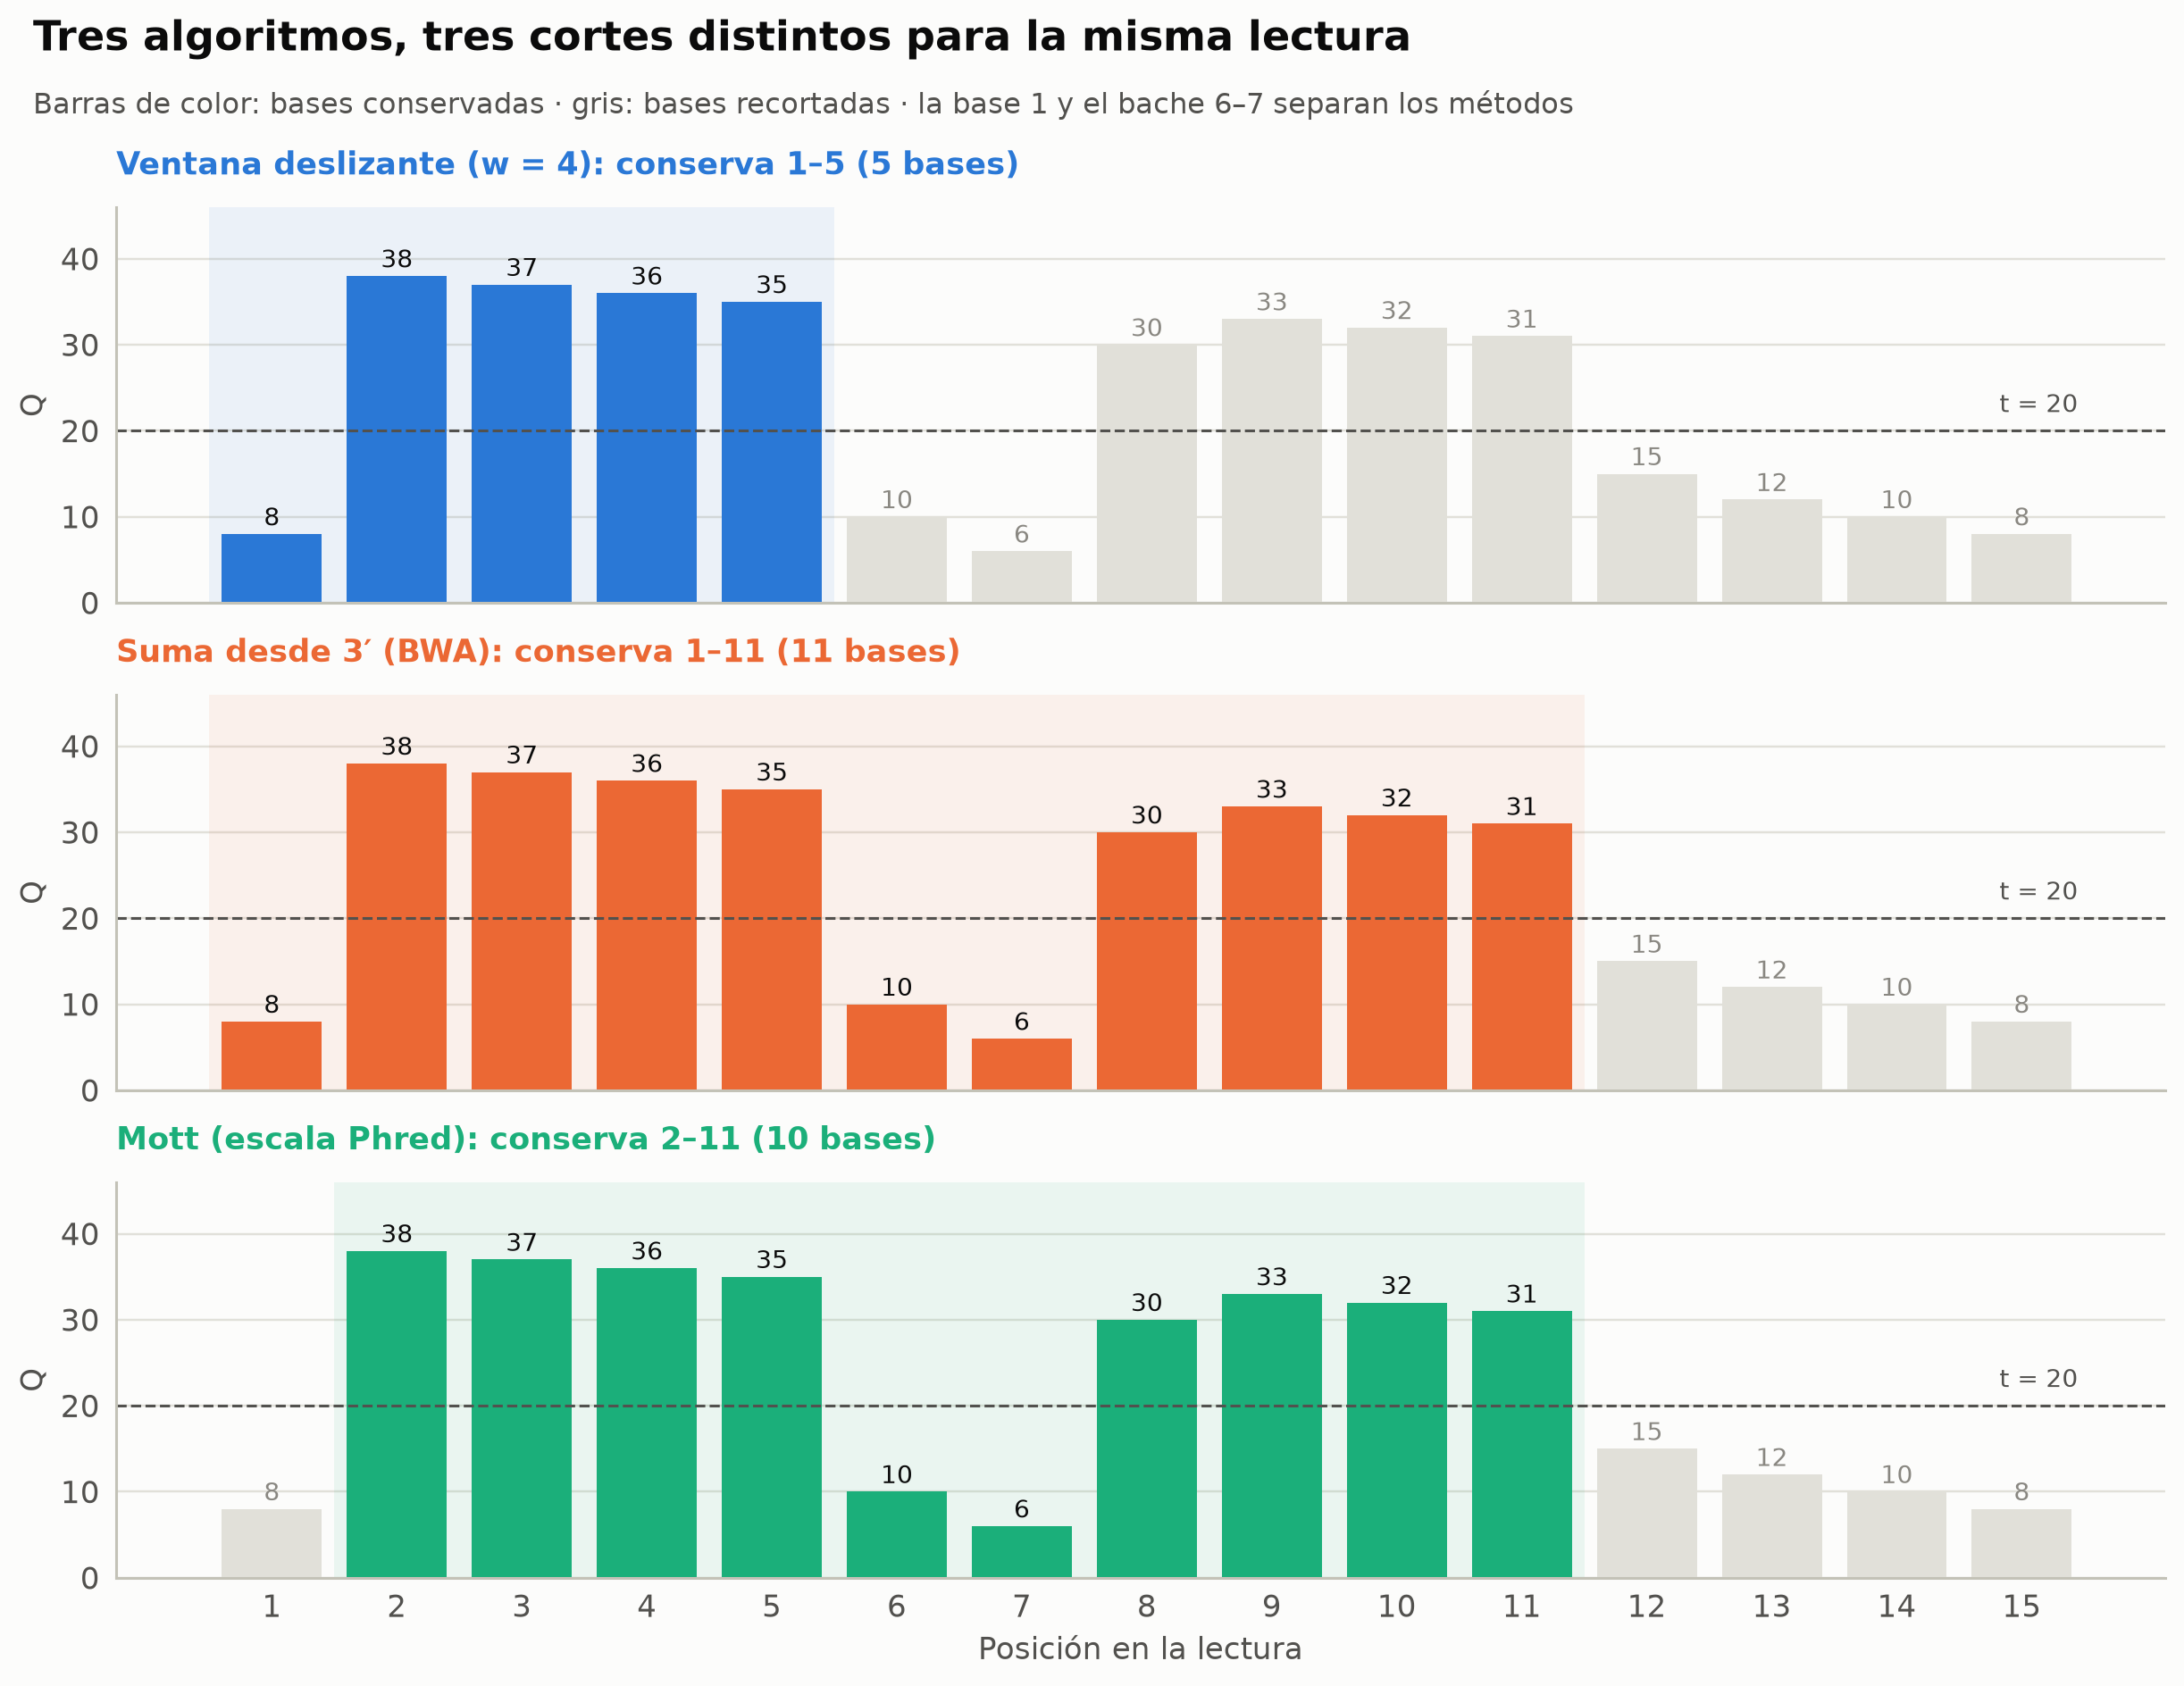

In [22]:
fig, axes = plt.subplots(3, 1, figsize=(11, 7.8), sharex=True)
x = np.arange(1, len(toy) + 1)
results = [("Ventana deslizante (w = 4)", 0, trim_sliding(toy), ec.BLUE),
           ("Suma desde 3′ (BWA)", 0, trim_bwa(toy), ec.ORANGE),
           ("Mott (escala Phred)", a, b, ec.AQUA)]
for ax, (lab, lo, hi, col) in zip(axes, results):
    keep = (x > lo) & (x <= hi)
    ax.bar(x, toy, color=np.where(keep, col, ec.GRID), width=0.8)
    for xi, qi in zip(x, toy):
        ax.text(xi, qi + 1, str(qi), ha="center", fontsize=9, color=ec.INK if (lo < xi <= hi) else ec.MUTED)
    ax.axhline(20, color=ec.INK_2, ls="--", lw=1)
    ax.axvspan(lo + 0.5, hi + 0.5, color=col, alpha=0.08, lw=0)
    ax.text(15.45, 21.5, "t = 20", va="bottom", ha="right", fontsize=9, color=ec.INK_2)
    ax.set_ylim(0, 46); ax.set_ylabel("Q")
    ax.set_title(f"{lab}: conserva {lo + 1}–{hi} ({hi - lo} bases)", fontsize=11.5, loc="left", color=col)
axes[-1].set_xticks(x); axes[-1].set_xlabel("Posición en la lectura")
ec.fig_title(fig, "Tres algoritmos, tres cortes distintos para la misma lectura",
             "Barras de color: bases conservadas · gris: bases recortadas · la base 1 y el bache 6–7 separan los métodos")
plt.show()

> 🔎 **Qué observamos.** La ventana deslizante es **miope y prudente**: se detiene en el primer tramo malo, aunque lo
> que viene después sea bueno. La suma acumulada (BWA) y Mott hacen **balance**: toleran un bache corto si detrás hay
> suficientes bases buenas que lo compensen. Mott, además, limpia el extremo 5′. La salida de la celda anterior muestra
> también que **la escala de la puntuación importa**: con probabilidades ($p_{\text{lím}} - p_i$, como *phred* y
> `seqtk`), una base Q38 y una Q30 aportan casi lo mismo (≈ $p_{\text{lím}}$), mientras que una base Q6 resta
> muchísimo ($p = 0.25$). Por eso el bache 6–7 ya no se "compra" con cuatro bases buenas y el tramo elegido cambia. En
> la práctica, con lecturas Illumina el extremo 5′ casi siempre es bueno y los métodos dan resultados parecidos en la
> mayoría de las lecturas; las diferencias aparecen justo en las lecturas "difíciles".

✅ **Compruebe su comprensión.** Si subimos el umbral a $t = 30$ en la lectura de ejemplo, ¿qué conservará BWA? (Pista:
calcule $S$ de derecha a izquierda. Respuesta: el máximo, $S(6) = 123$, está en $x^{\star} = 6$, y se conservan las
posiciones 1–5. Compruébelo con `trim_bwa(toy, t=30)`.)

### 7.3 Un empate que cambia el resultado: la lectura de 30 bases del libro

La fórmula del argmax parece no dejar lugar a dudas, pero ¿qué pasa si **dos** cortes empatan? Pasa más de lo que uno
creería, porque las calidades son enteros. El libro compara los dos criterios sobre una lectura de 30 bases con
$t = 20$ y $w = 4$ (figura «Recorte por calidad» del capítulo 6). Rehagamos el cálculo a mano, sumando $t - Q_i$
**desde el final**:

| Posición $i$ | 30 | 29 | 28 | 27 | 26 | 25 | **24** | 23 | **22** | 21 | 20 |
|---|---|---|---|---|---|---|---|---|---|---|---|
| $Q_i$ | 6 | 8 | 10 | 12 | 18 | 15 | 17 | 21 | 19 | 22 | 27 |
| $t - Q_i$ | 14 | 12 | 10 | 8 | 2 | 5 | 3 | −1 | 1 | −2 | −7 |
| $S(i)$ (acumulada desde 3′) | 14 | 26 | 36 | 44 | 46 | 51 | **54** | 53 | **54** | 52 | 45 |

El máximo, 54, aparece **dos veces**: en $x = 24$ y en $x = 22$. La regla del libro (y de `cutadapt`) elige el más
cercano al extremo 3′, $x^{\star} = 24$, y conserva **23 bases**: las bases 21–23 ($Q = 22, 19, 21$) tienen en conjunto
una calidad neta por encima del umbral, así que no vale la pena perderlas. Si en cambio tomamos el **primer** máximo
leyendo de izquierda a derecha, que es lo que hace `np.argmax`, cortamos en $x = 22$ y conservamos sólo 21. La
ventana deslizante, por su parte, encuentra su primera ventana mala en la posición 21 (medias
$37.75, 37.25, \ldots, 22.25$ y luego $19.75 < 20$) y conserva **20**.

La celda siguiente comprueba las tres cifras e implementa, además, el bucle **tal como lo escribe `cutadapt`**: recorre
la lectura desde 3′, acumula $t - Q_i$, actualiza el mejor corte sólo si la suma **supera** estrictamente al máximo
anterior (así, en un empate gana el primero encontrado desde 3′) y **se detiene en cuanto la suma se vuelve
negativa**. Si `cutadapt` está instalado (no viene en Colab; `pip install cutadapt`), también llamamos a su función.

In [23]:
def trim_cutadapt_rule(q_read, t=20):
    """Bucle de cutadapt -q: desde 3′, s += t − Q; se detiene si s < 0; el máximo estricto fija el corte."""
    s, best, keep = 0, 0, len(q_read)
    for i in range(len(q_read) - 1, -1, -1):
        s += t - q_read[i]
        if s < 0:
            break                                           # regla de parada: la cola ya no es "mala en neto"
        if s > best:                                        # estricto: en un empate gana el más cercano a 3′
            best, keep = s, i
    return keep

book_q = np.array([38, 38, 37, 38, 36, 37, 35, 36, 34, 35, 33, 34, 32, 30, 31,
                   28, 29, 26, 24, 27, 22, 19, 21, 17, 15, 18, 12, 10, 8, 6])   # lectura de 30 bases del libro
S_book = np.cumsum((20 - book_q)[::-1])[::-1]
print("S(x) para x = 20 … 30:", dict(zip(range(20, 31), S_book[19:].tolist())))
naive = int(np.argmax(S_book))                              # primer máximo desde 5′ (el error a evitar)
res_book = {"ventana deslizante (w=4)": trim_sliding(book_q),
            "argmax ingenuo (np.argmax, empate hacia 5′)": naive,
            "suma desde 3′, empate hacia 3′ (trim_bwa)": trim_bwa(book_q),
            "bucle de cutadapt -q (con parada)": trim_cutadapt_rule(book_q)}
try:
    from cutadapt.qualtrim import quality_trim_index        # sólo si cutadapt está instalado
    qual = "".join(chr(int(v) + 33) for v in book_q)
    res_book["cutadapt real: quality_trim_index"] = quality_trim_index(qual, 0, 20)[1]
except ImportError:
    print("(cutadapt no está instalado: se omite la comparación con su función)")
for lab, k in res_book.items():
    print(f"  {lab:<46} conserva {k} bases")
assert res_book["ventana deslizante (w=4)"] == 20 and naive == 21
assert trim_bwa(book_q) == trim_cutadapt_rule(book_q) == 23

S(x) para x = 20 … 30: {20: 45, 21: 52, 22: 54, 23: 53, 24: 54, 25: 51, 26: 46, 27: 44, 28: 36, 29: 26, 30: 14}
(cutadapt no está instalado: se omite la comparación con su función)
  ventana deslizante (w=4)                       conserva 20 bases
  argmax ingenuo (np.argmax, empate hacia 5′)    conserva 21 bases
  suma desde 3′, empate hacia 3′ (trim_bwa)      conserva 23 bases
  bucle de cutadapt -q (con parada)              conserva 23 bases


> 🔎 **Qué observamos.** Las cifras coinciden con las del libro: la ventana conserva 20 bases y la suma desde 3′
> conserva **23**, no 21. Un `np.argmax` sin más, aplicado a $S$ indexada de 5′ a 3′, devuelve el primer máximo y
> recorta dos bases buenas de más: un error silencioso que ninguna prueba con un ejemplo sin empates detectaría. La
> regla de parada no cambia nada en esta lectura (la suma nunca se vuelve negativa antes del máximo), pero sí en otras:
> si la **última** base es buena, la suma empieza negativa y `cutadapt` no recorta nada, aunque más adentro haya un
> tramo malo. Enseguida contaremos cuántas lecturas reales están en esa situación.

### 7.4 Versiones vectorizadas para 30 000 lecturas

Los bucles de Python son claros pero lentos. Las tres ideas se pueden escribir con operaciones de matrices:

* **Ventana:** las medias de todas las ventanas salen de una suma acumulada, $\bar Q_{j} = (C_{j+w} - C_j)/w$.
* **Suma desde 3′:** $S$ es una suma acumulada **desde la derecha**; el `argmax` se busca sobre la fila **invertida**
  para que los empates se resuelvan hacia 3′. La regla de parada de `cutadapt` se añade enmascarando todo lo que queda
  a la izquierda de la primera suma negativa.
* **Mott:** el mejor tramo que termina en $b$ vale $C_b - \min_{a \le b} C_a$, y `np.minimum.accumulate` calcula ese
  mínimo corrido de una vez.

In [24]:
def vec_sliding(Q, w=4, t=20):
    """Nº de bases conservadas por la ventana deslizante en cada lectura (matriz n × L)."""
    C = np.c_[np.zeros(len(Q)), np.cumsum(Q, 1)]
    means = (C[:, w:] - C[:, :-w]) / w
    bad = means < t
    return np.where(bad.any(1), bad.argmax(1), Q.shape[1])

def vec_bwa(Q, t=20):
    """Suma desde 3′ con empate hacia 3′: S se acumula sobre la fila invertida y argmax da el primer máximo desde 3′."""
    S_rev = np.cumsum((t - Q)[:, ::-1], 1)                  # S_rev[:, j] = S(L − j) en notación 1-based
    k = S_rev.argmax(1)
    return np.where(S_rev.max(1) > 0, Q.shape[1] - 1 - k, Q.shape[1])

def vec_cutadapt(Q, t=20):
    """Igual que vec_bwa, pero con la regla de parada de cutadapt: sólo cuenta lo anterior a la primera suma negativa."""
    S_rev = np.cumsum((t - Q)[:, ::-1], 1)
    neg = S_rev < 0
    stop = np.where(neg.any(1), neg.argmax(1), Q.shape[1])
    S_rev = np.where(np.arange(Q.shape[1]) < stop[:, None], S_rev, -np.inf)
    k = S_rev.argmax(1)
    return np.where(S_rev.max(1) > 0, Q.shape[1] - 1 - k, Q.shape[1])

def vec_mott(Q, t=20):
    """Devuelve (a, b): tramo conservado [a, b) de cada lectura (a = b si no queda nada)."""
    C = np.c_[np.zeros(len(Q)), np.cumsum(Q - t, 1)]
    run_min = np.minimum.accumulate(C, 1)
    gain = C - run_min
    b = gain.argmax(1)
    idx = np.where(C == run_min, np.arange(C.shape[1]), 0)
    arg_min = np.maximum.accumulate(idx, 1)                 # posición del mínimo corrido
    a = arg_min[np.arange(len(Q)), b]
    ok = gain.max(1) > 0
    return np.where(ok, a, 0), np.where(ok, b, 0)

# comprobación contra las versiones con bucles (la lectura del libro tiene un empate: vigila el desempate)
for qq in (toy, book_q):
    assert vec_sliding(qq[None])[0] == trim_sliding(qq) and vec_bwa(qq[None])[0] == trim_bwa(qq)
    assert vec_cutadapt(qq[None])[0] == trim_cutadapt_rule(qq)
    assert tuple(int(v[0]) for v in vec_mott(qq[None])) == trim_mott(qq)

t0 = time.time()
Qall = np.r_[Q1, Q2].astype(float)
keep_sw = vec_sliding(Qall)
keep_bwa = vec_bwa(Qall)
mott_a, mott_b = vec_mott(Qall)
keep_mott = mott_b - mott_a
print(f"60 000 lecturas recortadas con los tres métodos en {time.time() - t0:.2f} s")
for lab, kl in [("ventana", keep_sw), ("BWA", keep_bwa), ("Mott", keep_mott)]:
    print(f"{lab:>8}: longitud media conservada {kl.mean():6.1f} · bases conservadas {kl.sum() / Qall.size:.1%} "
          f"· lecturas intactas (150) {np.mean(kl == L):.1%} · lecturas < 36 nt {np.mean(kl < 36):.1%}")
print(f"Mott recorta el 5′ en {np.mean(mott_a > 0):.1%} de las lecturas")

# ¿Cuánto importan el desempate y la regla de parada en datos reales?
S_rev_all = np.cumsum((20 - Qall)[:, ::-1], 1)
keep_naive = np.where(S_rev_all.max(1) > 0, np.argmax(S_rev_all[:, ::-1], 1), L)   # primer máximo desde 5′
keep_cut = vec_cutadapt(Qall)
tie = keep_naive != keep_bwa
print(f"Empates en el máximo que np.argmax resolvería mal: {tie.sum():,} lecturas ({tie.mean():.1%}); "
      f"en ellas se perderían {np.mean(keep_bwa[tie] - keep_naive[tie]) if tie.any() else 0:.1f} bases de media")
stop_diff = keep_cut != keep_bwa
print(f"Regla de parada de cutadapt: cambia el corte en {stop_diff.sum():,} lecturas ({stop_diff.mean():.1%}); "
      f"de ellas, {np.mean(keep_cut[stop_diff] == L) if stop_diff.any() else 0:.0%} quedan sin recortar")

60 000 lecturas recortadas con los tres métodos en 0.20 s
 ventana: longitud media conservada  117.2 · bases conservadas 78.2% · lecturas intactas (150) 53.8% · lecturas < 36 nt 8.0%
     BWA: longitud media conservada  132.5 · bases conservadas 88.3% · lecturas intactas (150) 62.8% · lecturas < 36 nt 4.0%
    Mott: longitud media conservada  132.3 · bases conservadas 88.2% · lecturas intactas (150) 61.8% · lecturas < 36 nt 4.1%
Mott recorta el 5′ en 2.3% de las lecturas
Empates en el máximo que np.argmax resolvería mal: 441 lecturas (0.7%); en ellas se perderían 4.8 bases de media
Regla de parada de cutadapt: cambia el corte en 636 lecturas (1.1%); de ellas, 80% quedan sin recortar


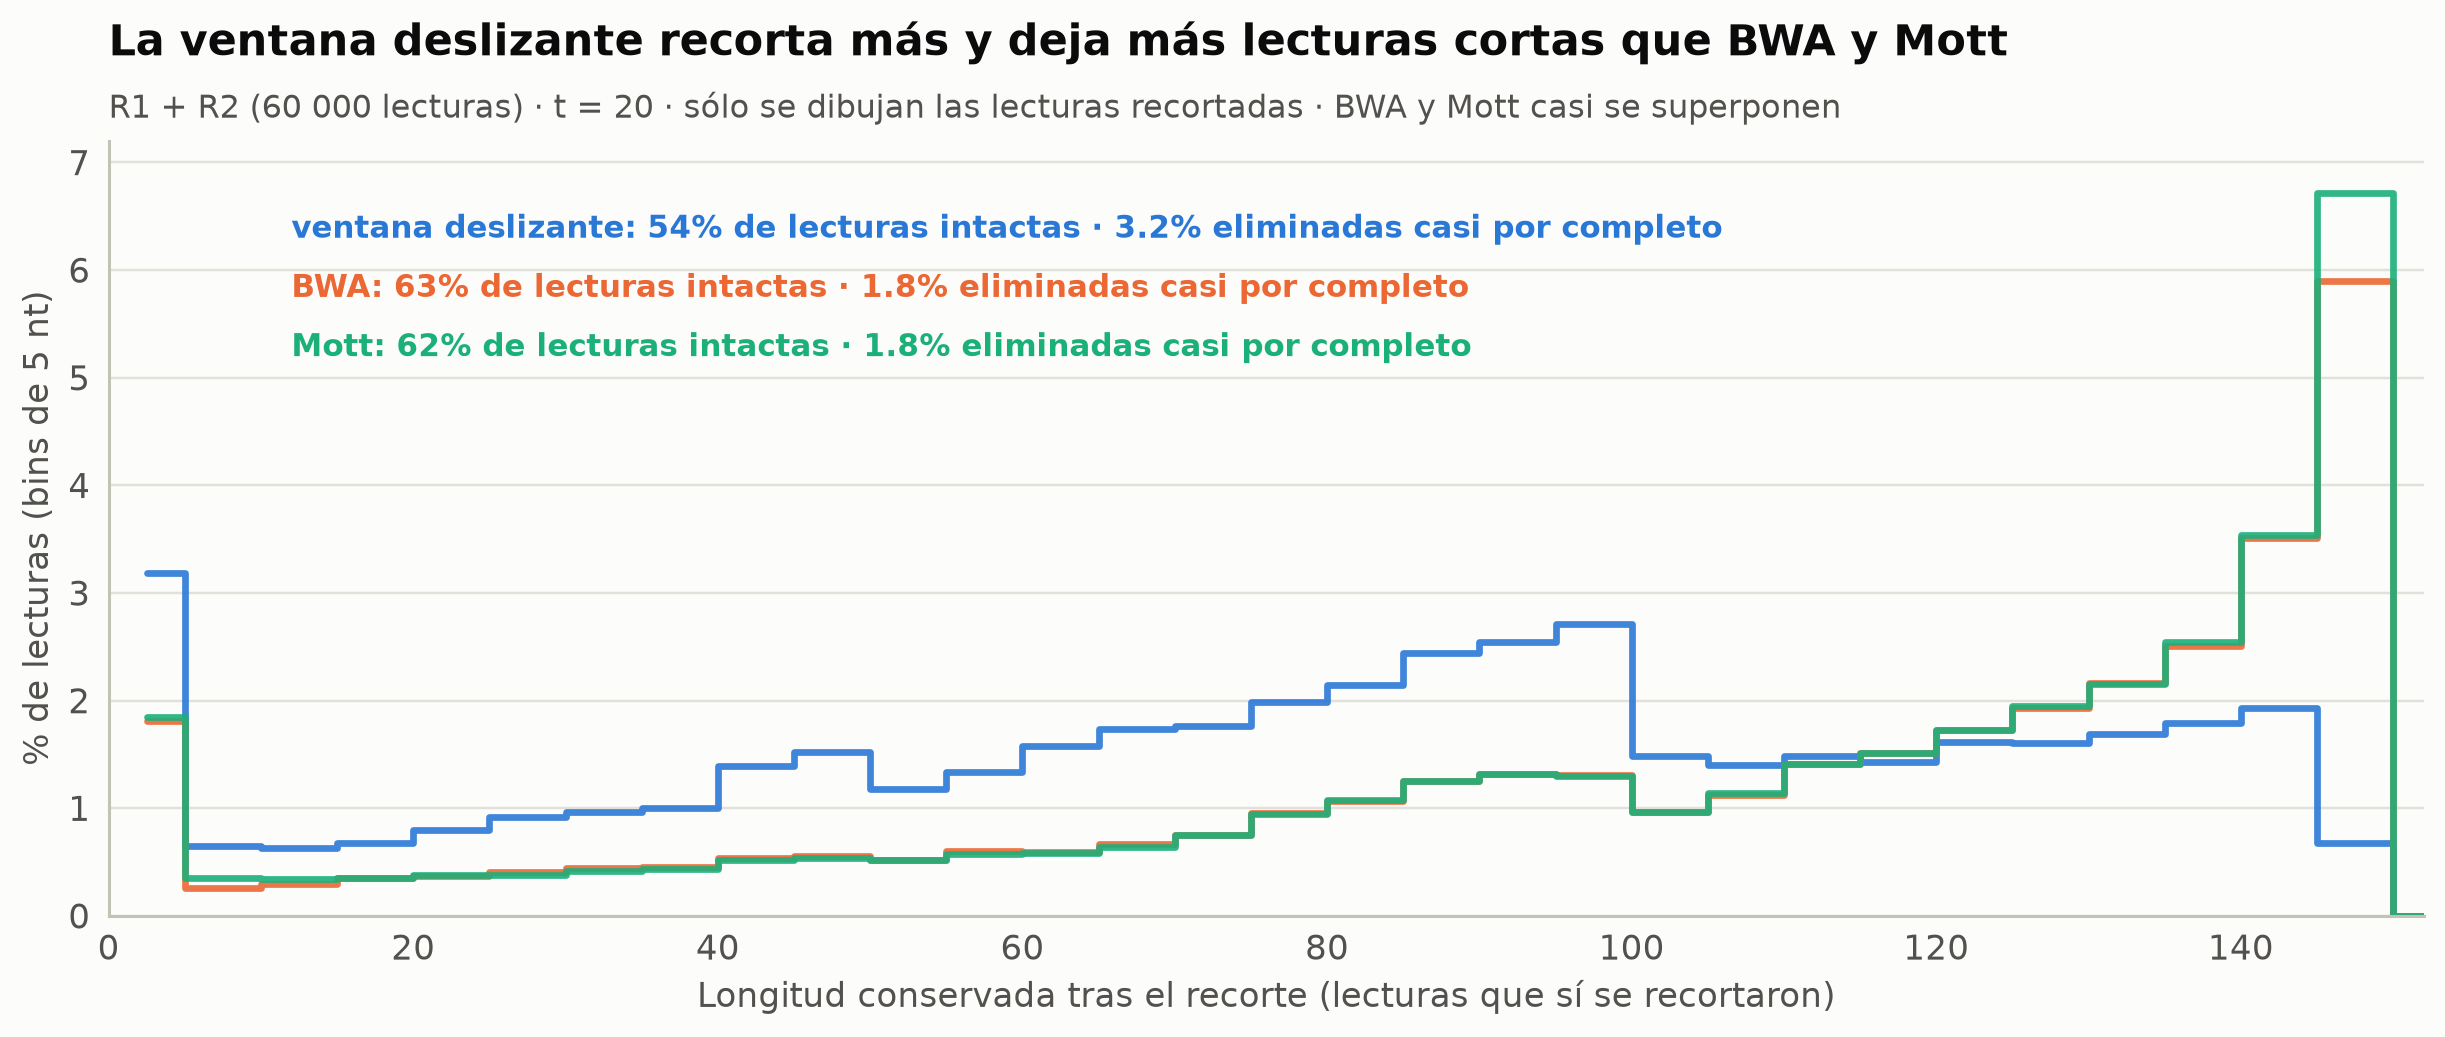

In [25]:
fig, ax = plt.subplots(figsize=(11, 4.6))
bins_len = np.arange(0, L + 6, 5)
for k, (kl, col, lab) in enumerate([(keep_sw, ec.BLUE, "ventana deslizante"), (keep_bwa, ec.ORANGE, "BWA"),
                                   (keep_mott, ec.AQUA, "Mott")]):
    h, _ = np.histogram(kl[kl < L], bins=bins_len)
    ax.step(bins_len[:-1] + 2.5, 100 * h / len(kl), where="mid", color=col, lw=2.2, alpha=0.9)
    ax.text(12, 6.3 - 0.55 * k, f"{lab}: {np.mean(kl == L):.0%} de lecturas intactas · {np.mean(kl < 5):.1%} eliminadas casi por completo",
            color=col, fontsize=10, fontweight="bold")
ax.set_xlim(0, L + 2); ax.set_ylim(0, 7.2)
ax.set_xlabel("Longitud conservada tras el recorte (lecturas que sí se recortaron)")
ax.set_ylabel("% de lecturas (bins de 5 nt)")
ec.title(ax, "La ventana deslizante recorta más y deja más lecturas cortas que BWA y Mott",
         "R1 + R2 (60 000 lecturas) · t = 20 · sólo se dibujan las lecturas recortadas · BWA y Mott casi se superponen")
plt.show()

> 🔎 **Qué observamos.** Las tres distribuciones tienen la misma forma general: un grupo de lecturas recortadas cerca
> del final (colas malas cortas) y una cola de lecturas muy recortadas (las que se "rompieron" pronto y terminan en
> `#`). La **ventana deslizante** produce más lecturas cortas, porque se detiene en el primer bache. BWA y Mott son casi
> idénticos: en datos Illumina, el extremo 5′ rara vez está mal, así que la capacidad extra de Mott casi no se usa.
>
> Las dos últimas líneas de la celda anterior ponen cifra a los detalles de la sección 7.3. En ≈ 0.7 % de las lecturas
> reales el máximo de $S$ está empatado, y un `np.argmax` ingenuo les quitaría ≈ 5 bases buenas de media. La regla de
> parada de `cutadapt` cambia el corte en ≈ 1 % de las lecturas y, en cuatro de cada cinco, las deja **sin recortar**:
> son lecturas cuya última base es buena, de modo que la suma empieza negativa y el recorrido se detiene enseguida,
> aunque algo más adentro haya un tramo malo. Dos herramientas con el "mismo" umbral no producen los mismos archivos.

![La ventana deslizante recorre una lectura real hasta encontrar la primera ventana con calidad media menor que 20; después se comparan los cortes de BWA y Mott](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-06-ngs/6.2_ventana_deslizante.gif)

*La ventana deslizante recorre una lectura real hasta encontrar la primera ventana con calidad media menor que 20; después se comparan los cortes de BWA y Mott*

In [26]:
# Lectura real de R1 en la que la ventana corta mucho antes que BWA (un bache seguido de bases buenas)
diff = keep_bwa[:N] - keep_sw[:N]
cand = np.where((keep_sw[:N] > 50) & (keep_sw[:N] < 110) & (diff > 20))[0]
demo_i = int(cand[0]) if len(cand) else int(np.argmax(diff))
qd = Q1[demo_i].astype(float)
w, qthr = 4, 20
cut_sw, cut_bwa = vec_sliding(qd[None])[0], vec_bwa(qd[None])[0]
ma, mb = (int(v[0]) for v in vec_mott(qd[None]))
means_d = np.convolve(qd, np.ones(w) / w, mode="valid")
step = max(1, int(np.ceil((cut_sw + 1) / 44)))
win_frames = list(range(0, cut_sw + 1, step))
if win_frames[-1] != cut_sw:
    win_frames.append(cut_sw)
plan = [("win", j) for j in win_frames] + [("sw", 0)] * 4 + [("bwa", 0)] * 4 + [("mott", 0)] * 5
print(f"Lectura {names1[demo_i]} · ventana conserva {cut_sw} · BWA {cut_bwa} · Mott {ma + 1}–{mb} · {len(plan)} cuadros")

fig, ax = plt.subplots(figsize=(12, 4.8))
xx = np.arange(1, L + 1)

def update(f):
    kind, j = plan[f]
    ax.clear()
    ax.axhline(qthr, color=ec.INK_2, ls="--", lw=1)
    ax.text(L + 1, qthr, "t = 20", va="center", fontsize=9, color=ec.INK_2)
    if kind == "win":
        cols = [ec.SEQ_BLUE[5] if i < j else ec.GRID for i in range(L)]
        ax.bar(xx, qd, color=cols, width=0.9)
        m = means_d[j]
        col = ec.RED if m < qthr else ec.GREEN
        ax.add_patch(Rectangle((j + 0.5, 0), w, 43, fill=False, ec=col, lw=2.2))
        ax.plot([j + 0.5, j + w + 0.5], [m, m], color=col, lw=3)
        ax.text(j + w + 2, min(m + 3, 41), f"media = {m:.1f}" + ("  < 20 → ¡cortar aquí!" if m < qthr else ""),
                color=col, fontsize=10.5, fontweight="bold")
        msg = f"Ventana en las posiciones {j + 1}–{j + w}"
    else:
        lo, hi, col, lab = {"sw": (0, cut_sw, ec.BLUE, "Ventana deslizante"),
                            "bwa": (0, cut_bwa, ec.ORANGE, "BWA"),
                            "mott": (ma, mb, ec.AQUA, "Mott")}[kind]
        keep = (xx > lo) & (xx <= hi)
        ax.bar(xx, qd, color=np.where(keep, col, ec.GRID), width=0.9)
        msg = f"{lab}: conserva {lo + 1}–{hi} ({hi - lo} bases de {L})"
    ax.set_xlim(0, L + 10); ax.set_ylim(0, 44)
    ax.set_xlabel(f"Posición en la lectura (ciclo) · lectura real {names1[demo_i]} (R1) · w = 4 · t = 20")
    ax.set_ylabel("Calidad Phred")
    ax.set_title(msg, fontsize=12, loc="left")
    return []

ec.animate(fig, update, frames=len(plan), interval=180, name="6.2_ventana_deslizante")

Lectura SRR2584863.1 · ventana conserva 99 · BWA 125 · Mott 1–125 · 47 cuadros


▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** La ventana avanza base a base mientras la media se mantiene por encima de 20 (verde). En
> cuanto encuentra una ventana con media menor (rojo), corta ahí. BWA y Mott, que hacen un balance de toda la cola,
> conservan más bases: el bache que detuvo a la ventana está seguido de bases suficientemente buenas.

### 7.5 Explorador interactivo: mueva el umbral

Cuatro lecturas reales con comportamientos distintos. Mueva el deslizador para cambiar el umbral $t$ y observe dónde
corta cada algoritmo (las barras horizontales bajo cada lectura muestran el tramo conservado). Pase el cursor por las
barras de calidad para ver la base, su $Q$ y su probabilidad de error.

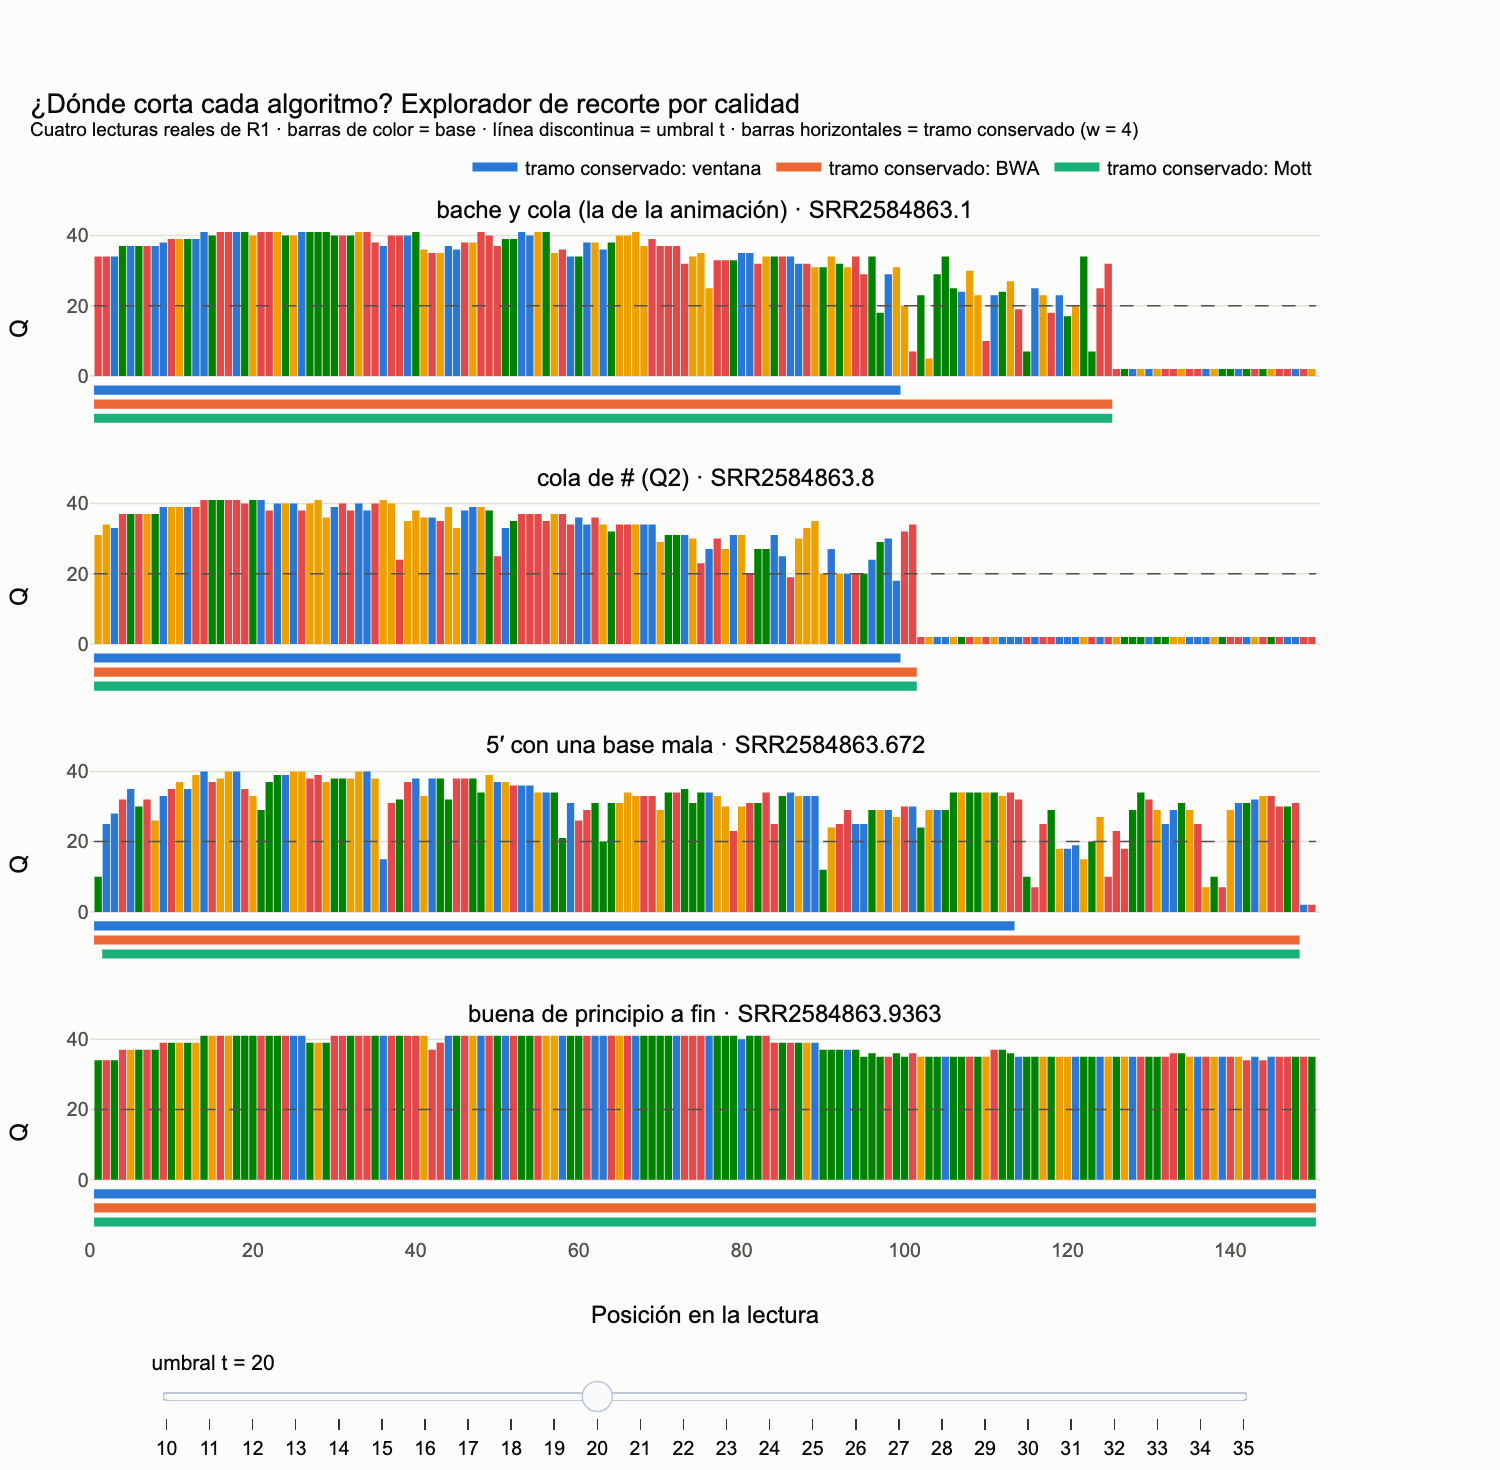

In [27]:
# Selección automática de cuatro lecturas representativas de R1
has_q2_tail = (Q1[:, -20:] == 2).all(1) & (Q1[:, :60].mean(1) > 32)
five_prime_low = (mott_a[:N] > 0)
pick = {"bache y cola (la de la animación)": demo_i,
        "cola de # (Q2)": int([i for i in np.where(has_q2_tail)[0] if i != demo_i][0]),
        "5′ con una base mala": int(np.where(five_prime_low & (Q1.mean(1) > 30))[0][0]),
        "buena de principio a fin": int(np.argmax(Q1.min(1) * 100 + Q1.mean(1)))}
thresholds = np.arange(10, 36)
algos = [("ventana", ec.BLUE), ("BWA", ec.ORANGE), ("Mott", ec.AQUA)]
nrow = len(pick)
fig = make_subplots(rows=nrow, cols=1, shared_xaxes=True, vertical_spacing=0.06,
                    subplot_titles=[f"{k} · {names1[i]}" for k, i in pick.items()])
for r, (lab, i) in enumerate(pick.items(), start=1):
    q_i = Q1[i]
    fig.add_bar(x=xx, y=q_i, marker_color=[ec.NUC_COLORS.get(c, ec.MUTED) for c in seqs1[i]], showlegend=False,
                customdata=[[b, float(p)] for b, p in zip(seqs1[i], 10 ** (-q_i / 10))], row=r, col=1,
                hovertemplate="posición %{x} · base <b>%{customdata[0]}</b><br>Q = %{y} · P(error) = %{customdata[1]:.4f}<extra></extra>")
for name, col in algos:                                   # entradas de leyenda para los tramos
    fig.add_scatter(x=[None], y=[None], mode="lines", line=dict(color=col, width=6), name=f"tramo conservado: {name}")

def shapes_for(qthr):
    shapes, annots = [], []
    for r, (lab, i) in enumerate(pick.items(), start=1):
        qi = Q1[i][None].astype(float)
        cuts = [(0, vec_sliding(qi, 4, qthr)[0]), (0, vec_bwa(qi, qthr)[0]),
                tuple(int(v[0]) for v in vec_mott(qi, qthr))]
        xref, yref = ("x" if r == 1 else f"x{r}"), ("y" if r == 1 else f"y{r}")
        shapes.append(dict(type="line", xref=xref, yref=yref, x0=0.5, x1=L + 0.5, y0=qthr, y1=qthr,
                           line=dict(color=ec.INK_2, dash="dash", width=1)))
        for k, ((lo, hi), (name, col)) in enumerate(zip(cuts, algos)):
            y = -4 - 4 * k
            if hi > lo:
                shapes.append(dict(type="rect", xref=xref, yref=yref, x0=lo + 0.5, x1=hi + 0.5, y0=y - 1.3, y1=y + 1.3,
                                   fillcolor=col, line=dict(width=0)))
            annots.append(dict(xref=xref, yref=yref, x=L + 2, y=y, text=f"{name}: {hi - lo}", showarrow=False,
                               xanchor="left", font=dict(size=10, color=col)))
    return shapes, annots

steps = []
for t in thresholds:
    sh, an = shapes_for(int(t))
    steps.append(dict(method="relayout", label=str(t), args=[{"shapes": sh, "annotations": an}]))
sh0, an0 = shapes_for(20)
title_annots = [a.to_plotly_json() for a in fig.layout.annotations]              # títulos de los subgráficos
fig.update_layout(shapes=sh0, annotations=title_annots + an0)
for s in steps:                                            # conservar los títulos en cada paso
    s["args"][0]["annotations"] = title_annots + s["args"][0]["annotations"]
fig.update_layout(
    sliders=[dict(active=int(np.where(thresholds == 20)[0][0]), steps=steps, y=-0.075, len=0.9, x=0.05,
                  currentvalue=dict(prefix="umbral t = ", font=dict(size=14)))],
    title=dict(text="¿Dónde corta cada algoritmo? Explorador de recorte por calidad<br>"
                    "<sup>Cuatro lecturas reales de R1 · barras de color = base · línea discontinua = umbral t · "
                    "barras horizontales = tramo conservado (w = 4)</sup>"),
    height=980, margin=dict(t=150, l=60, r=120, b=150), bargap=0.1,
    legend=dict(orientation="h", yanchor="bottom", y=1.035, x=1, xanchor="right"))
fig.update_yaxes(range=[-16, 43], title_text="Q")
fig.update_xaxes(range=[0, L + 1])
fig.update_xaxes(title_text="Posición en la lectura", row=nrow, col=1)
fig.show()

> 🔎 **Qué observamos.** Con umbrales bajos (10–15) los tres métodos casi no recortan las lecturas buenas; al subirlo,
> la **ventana** es siempre la primera en retroceder. En la lectura con cola de `#` los tres cortan casi en el mismo sitio:
> la frontera entre buenas bases y Q2 es tan abrupta que no hay nada que discutir. En la lectura con una base mala al
> principio, sólo **Mott** la elimina. Un umbral demasiado alto (30–35) destruye lecturas perfectamente útiles: el
> alineador ya tiene en cuenta las calidades, así que no hace falta que cada base sea perfecta.

## 8. Recorte de adaptadores: alineamiento semiglobal y solapamiento de pares

### 8.1 El problema: encontrar un adaptador incompleto y con errores

Buscar el adaptador parece fácil (`seq.find("CTGTCTCTTATA")`), pero tiene tres trampas:

1. **El adaptador puede estar cortado.** Si el inserto mide 140 pb, sólo caben 10 bases de adaptador al final de una
   lectura de 150: hay que aceptar que sólo aparezca un **prefijo** del adaptador.
2. **El adaptador también tiene errores de secuenciación**, y justo al final de la lectura, donde la calidad es peor.
3. Si aceptamos coincidencias **muy cortas**, cortaremos por azar: 3 bases cualesquiera coinciden con `CTG` con
   probabilidad $1/4^3 = 1/64$.

Cutadapt (Martin, 2011) lo resuelve con un **alineamiento semiglobal**: el adaptador se alinea con el extremo 3′ de la
lectura, con huecos gratuitos al principio de la lectura (el adaptador puede empezar en cualquier posición) y al final
del adaptador (puede quedar cortado por el final de la lectura). Se acepta la coincidencia si el número de errores
(sustituciones, inserciones y deleciones) no supera una **tasa de error** $e$ por base alineada, y si el solapamiento
es de al menos `min_overlap` bases:

$$
\text{errores}(p) \;\le\; \big\lfloor e \cdot \ell(p) \big\rfloor, \qquad \ell(p) = \min\big(m,\; L - p + 1\big) \ge \ell_{\min}
$$

| Símbolo | Significado |
|---|---|
| $p$ | posición de la lectura donde empieza el adaptador |
| $m$ | longitud del adaptador (aquí 19) |
| $L$ | longitud de la lectura |
| $\ell(p)$ | longitud del solapamiento entre la lectura y el adaptador si este empieza en $p$ |
| $e$ | tasa de error máxima (Cutadapt: 0.1 por defecto) |
| $\ell_{\min}$ | solapamiento mínimo (Cutadapt: 3 por defecto) |

### Ejemplo a mano

La lectura `ACGGAT CTGTCACTTAT` (17 bases) tiene 6 bases de genoma y 11 de adaptador Nextera con **un error** (la
sexta base del adaptador, T, se leyó como A). Probemos algunos puntos de inicio:

| $p$ | tramo de la lectura | prefijo del adaptador | $\ell$ | diferencias | permitidas $\lfloor 0.1\,\ell \rfloor$ | ¿acepta? |
|---|---|---|---|---|---|---|
| 5 | `ATCTGTCACTTAT` | `CTGTCTCTTATAC` | 13 | 7 | 1 | no |
| 6 | `TCTGTCACTTAT` | `CTGTCTCTTATA` | 12 | 11 | 1 | no |
| **7** | `CTGTCACTTAT` | `CTGTCTCTTAT` | **11** | **1** | **1** | **sí** |
| 8 | `TGTCACTTAT` | `CTGTCTCTTA` | 10 | 9 | 1 | no |
| 15 | `TAT` | `CTG` | 3 | 3 | 0 | no |

El adaptador empieza en la posición 7: se conservan las 6 primeras bases. Una búsqueda exacta habría fallado por el
error, y una búsqueda exacta de 12 bases ni siquiera cabría en las 11 finales.

In [28]:
NEXTERA = "CTGTCTCTTATACACATCT"

def adapter_scan_table(read, adapter=NEXTERA, e=0.1, min_overlap=3):
    """Para cada inicio posible, compara (sin huecos) la lectura con el prefijo del adaptador."""
    rows = []
    for p in range(len(read) - min_overlap + 1):
        l = min(len(adapter), len(read) - p)
        mm = sum(a != b for a, b in zip(read[p:p + l], adapter[:l]))
        rows.append(dict(p=p + 1, tramo=read[p:p + l], adaptador=adapter[:l], l=l, diferencias=mm,
                         permitidas=int(e * l), acepta=mm <= int(e * l)))
    return pd.DataFrame(rows)

toy_read = "ACGGAT" + "CTGTCACTTAT"
tab = adapter_scan_table(toy_read)
print("Primer inicio aceptado: posición", int(tab[tab.acepta].p.min()))
tab

Primer inicio aceptado: posición 7


,p,tramo,adaptador,l,diferencias,permitidas,acepta
0,1,ACGGATCTGTCACTTAT,CTGTCTCTTATACACAT,17,9,1,False
1,2,CGGATCTGTCACTTAT,CTGTCTCTTATACACA,16,13,1,False
2,3,GGATCTGTCACTTAT,CTGTCTCTTATACAC,15,9,1,False
3,4,GATCTGTCACTTAT,CTGTCTCTTATACA,14,13,1,False
4,5,ATCTGTCACTTAT,CTGTCTCTTATAC,13,7,1,False
5,6,TCTGTCACTTAT,CTGTCTCTTATA,12,11,1,False
6,7,CTGTCACTTAT,CTGTCTCTTAT,11,1,1,True
7,8,TGTCACTTAT,CTGTCTCTTA,10,9,1,False
8,9,GTCACTTAT,CTGTCTCTT,9,5,0,False
9,10,TCACTTAT,CTGTCTCT,8,6,0,False


### Con inserciones y deleciones: programación dinámica semiglobal

La tabla anterior sólo admite **sustituciones**. Si el secuenciador se "salta" o "repite" una base (más común en otras
tecnologías, pero posible en Illumina), el adaptador queda desplazado y todas las bases siguientes parecen distintas.
Cutadapt usa programación dinámica, como en la Lección 3.2, con una matriz de **distancia de edición** $D(i, j)$
entre las primeras $i$ bases de la lectura y las primeras $j$ del adaptador:

$$
D(i, j) = \min\begin{cases}
D(i-1, j-1) + [\,r_i \ne a_j\,] & \text{(coincidencia o sustitución)}\\
D(i-1, j) + 1 & \text{(base extra en la lectura)}\\
D(i, j-1) + 1 & \text{(base del adaptador que falta en la lectura)}
\end{cases}
\qquad D(i, 0) = 0,\quad D(0, j) = j
$$

| Símbolo | Significado |
|---|---|
| $r_i$, $a_j$ | base $i$ de la lectura y base $j$ del adaptador |
| $[\,r_i \ne a_j\,]$ | 1 si son distintas, 0 si son iguales |
| $D(i, 0) = 0$ | el adaptador puede empezar en **cualquier** posición de la lectura sin penalización (hueco inicial gratis) |
| última fila $D(L, j)$ | la lectura se acabó cuando el adaptador llevaba $j$ bases: el adaptador puede quedar **cortado** |

La solución se busca en la **última fila** (la lectura terminó) o en la **última columna** (el adaptador completo
cupo), exigiendo $D \le \lfloor e \cdot j \rfloor$. Probémoslo con una lectura en la que el adaptador tiene una base
**insertada** (una C de más): la comparación sin huecos se desorganiza, la programación dinámica no.

In [29]:
def semiglobal_adapter(read, adapter=NEXTERA, e=0.1, min_overlap=3):
    """Alineamiento semiglobal lectura–adaptador (Cutadapt simplificado).
    Devuelve (inicio del adaptador en la lectura, errores, bases del adaptador alineadas, matriz D, camino)."""
    n, m = len(read), len(adapter)
    D = np.zeros((n + 1, m + 1), dtype=int)
    D[0, :] = np.arange(m + 1)
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            D[i, j] = min(D[i - 1, j - 1] + (read[i - 1] != adapter[j - 1]), D[i - 1, j] + 1, D[i, j - 1] + 1)
    # candidatos: última fila (adaptador cortado por el final de la lectura) y última columna (adaptador completo)
    cands = [(n, j) for j in range(min_overlap, m + 1)] + [(i, m) for i in range(m, n)]
    ok = [(D[i, j] / j, -j, i, j) for i, j in cands if D[i, j] <= int(e * j)]
    if not ok:
        return None
    _, _, i, j = min(ok)
    path, (ci, cj) = [(i, j)], (i, j)                      # rastreo hacia atrás para saber dónde empieza
    while cj > 0:
        if ci > 0 and D[ci, cj] == D[ci - 1, cj - 1] + (read[ci - 1] != adapter[cj - 1]):
            ci, cj = ci - 1, cj - 1
        elif ci > 0 and D[ci, cj] == D[ci - 1, cj] + 1:
            ci -= 1
        else:
            cj -= 1
        path.append((ci, cj))
    return ci, D[i, j], j, D, path[::-1]

ins_read = "ACGGAT" + "CTGTCCTCTTAT"                  # C insertada después de CTGTC
print("Sin huecos, mejor inicio aceptado:", adapter_scan_table(ins_read).query("acepta").p.min())
start, errs, alen, D, path = semiglobal_adapter(ins_read)
print(f"Semiglobal: el adaptador empieza en la posición {start + 1}, con {errs} error(es) en {alen} bases del adaptador"
      f" → se conservan {start} bases")

Sin huecos, mejor inicio aceptado: nan
Semiglobal: el adaptador empieza en la posición 7, con 1 error(es) en 11 bases del adaptador → se conservan 6 bases


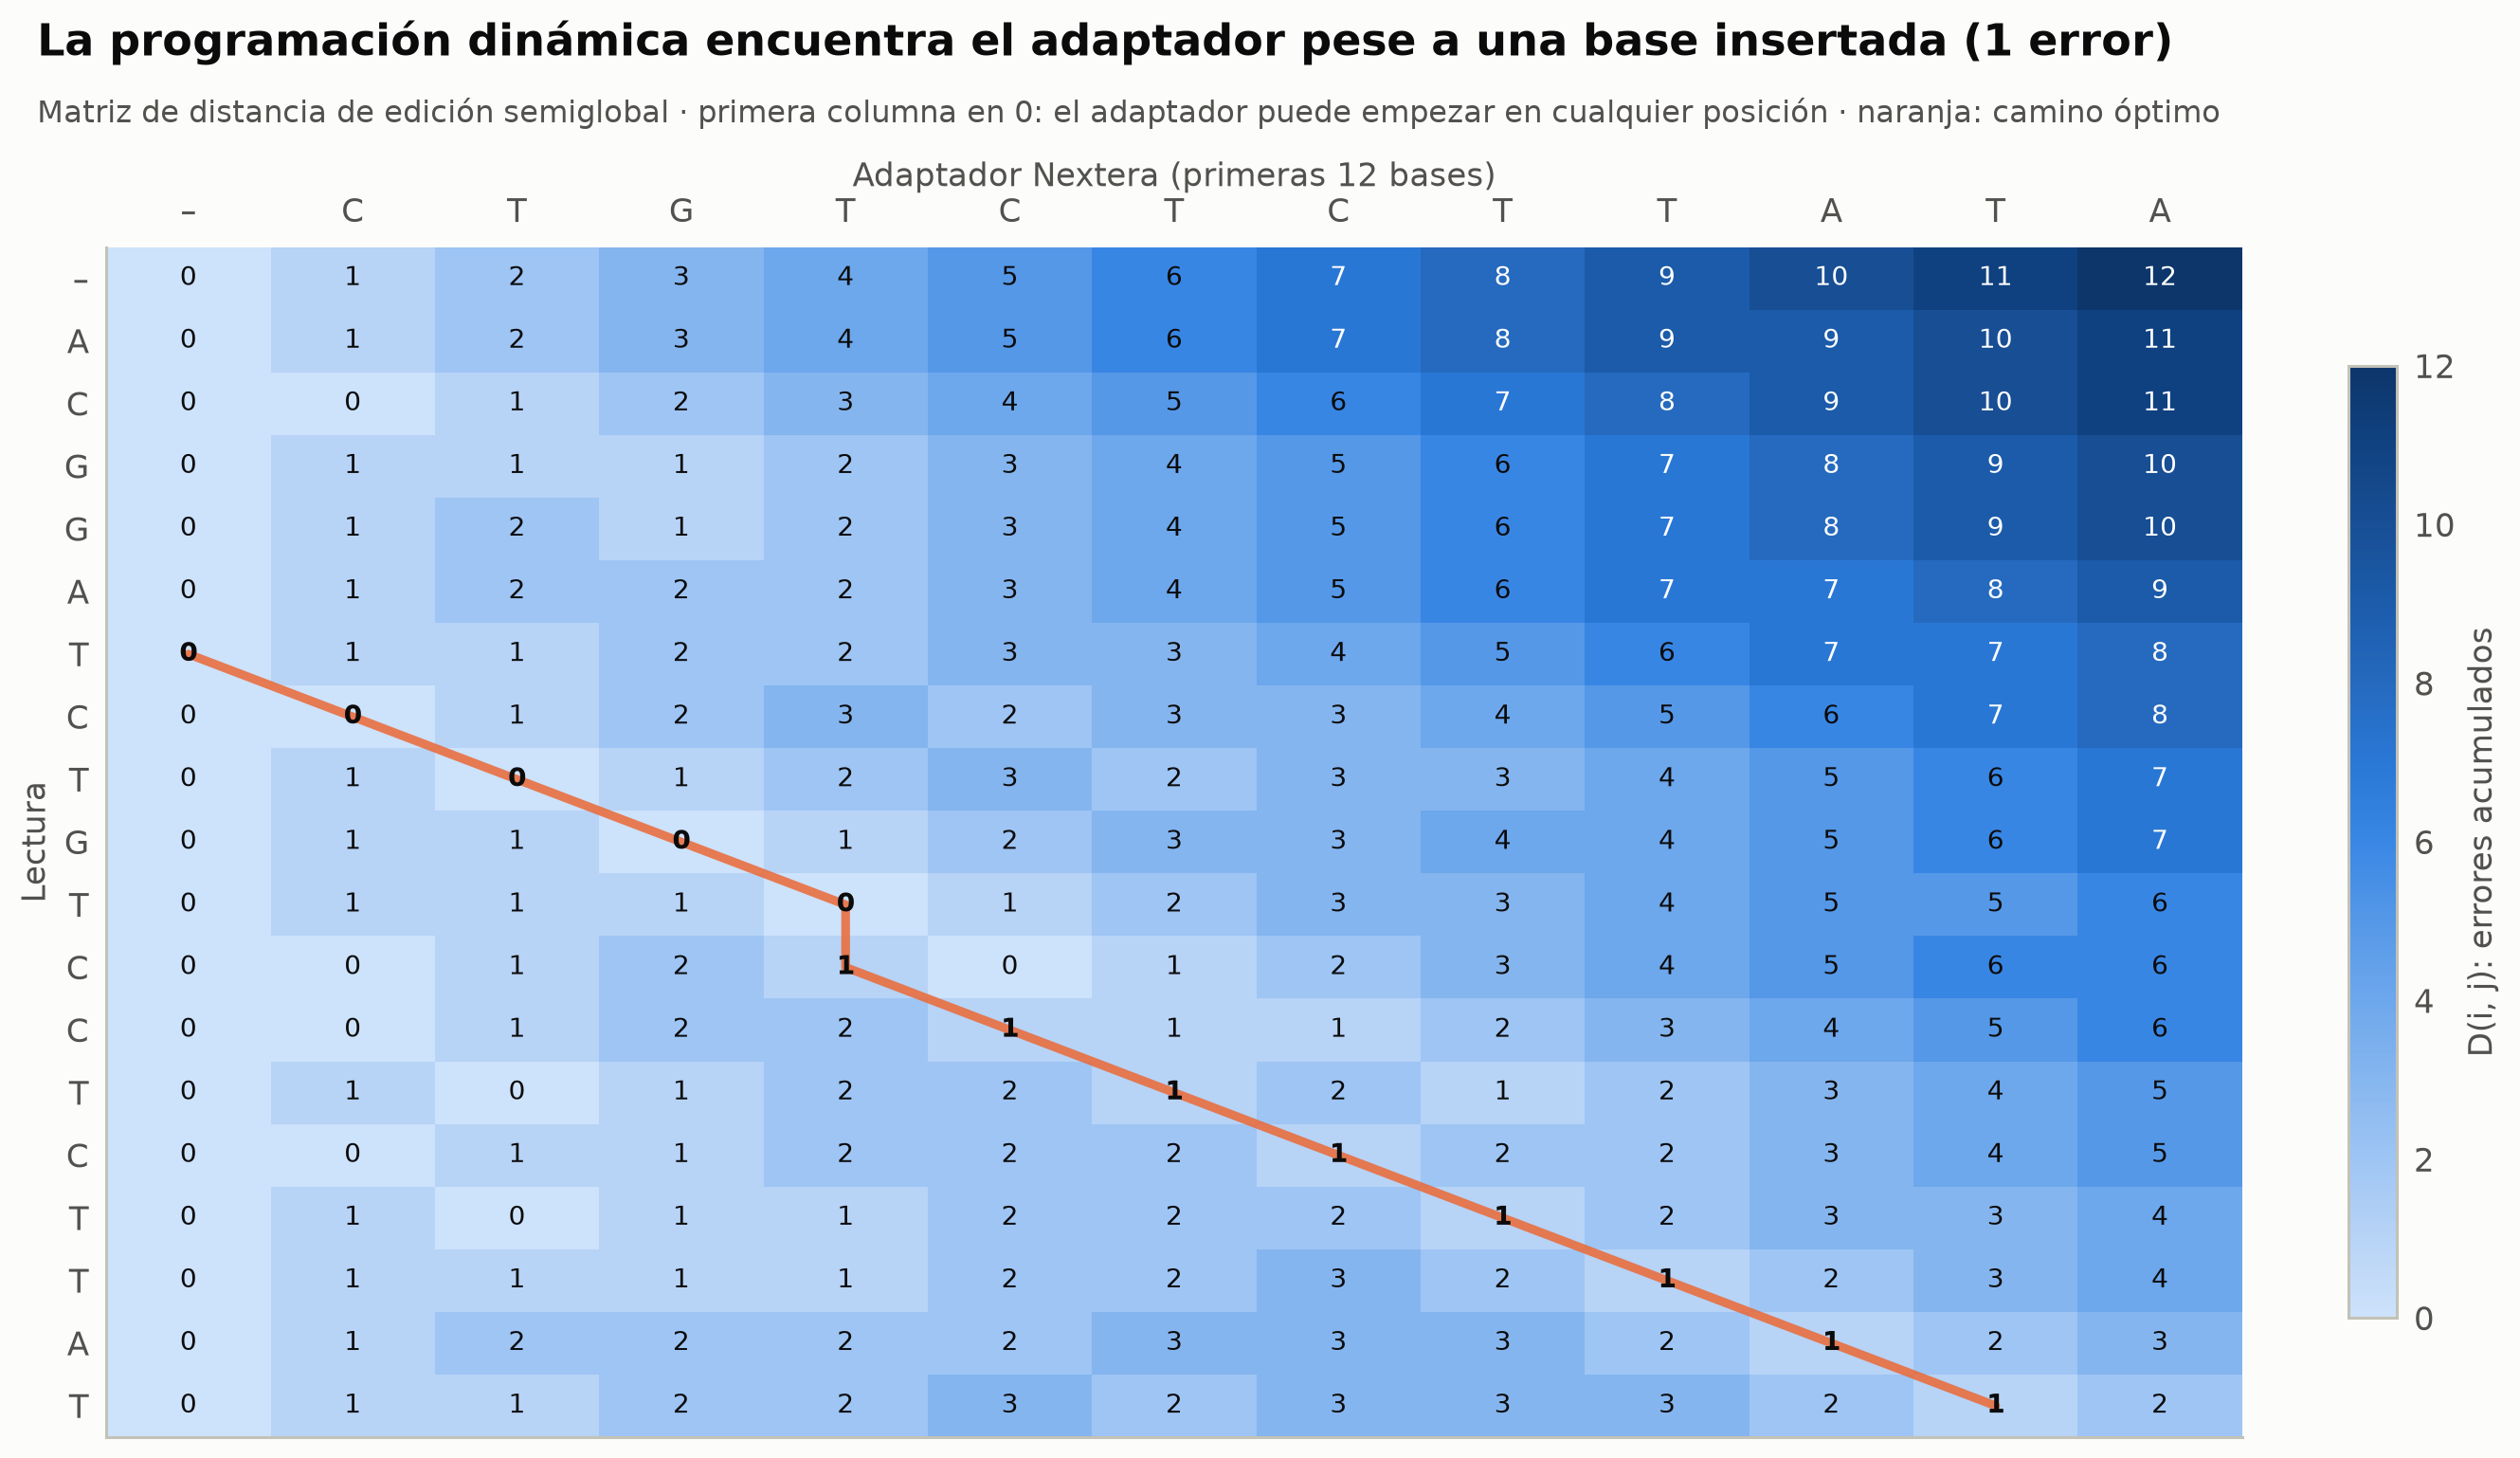

In [30]:
fig, ax = plt.subplots(figsize=(12, 6.2))
sub = D[:, :13]                                           # primeras 12 bases del adaptador para que se lea bien
im = ax.imshow(sub, cmap=ec.CMAP_SEQ, vmin=0, vmax=12, aspect="auto")
for i in range(sub.shape[0]):
    for j in range(sub.shape[1]):
        on = (i, j) in path
        ax.text(j, i, sub[i, j], ha="center", va="center", fontsize=9,
                color="white" if sub[i, j] > 6 else ec.INK, fontweight="bold" if on else "normal")
pi, pj = zip(*[(i, j) for i, j in path if j <= 12])
ax.plot(pj, pi, color=ec.ORANGE, lw=3, alpha=0.85)
ax.set_xticks(range(13), ["–"] + list(NEXTERA[:12])); ax.set_yticks(range(len(ins_read) + 1), ["–"] + list(ins_read))
ax.xaxis.tick_top(); ax.grid(False)
ax.set_xlabel("Adaptador Nextera (primeras 12 bases)"); ax.set_ylabel("Lectura")
ax.xaxis.set_label_position("top")
fig.colorbar(im, ax=ax, shrink=0.8, label="D(i, j): errores acumulados")
ec.fig_title(fig, f"La programación dinámica encuentra el adaptador pese a una base insertada ({errs} error)",
             "Matriz de distancia de edición semiglobal · primera columna en 0: el adaptador puede empezar en cualquier "
             "posición · naranja: camino óptimo")
plt.show()

> 🔎 **Qué observamos.** La columna de la izquierda vale 0 en todas las filas: el alineamiento puede "entrar" en
> cualquier posición de la lectura sin coste. El camino naranja avanza en diagonal (coincidencias) desde la posición 7
> y hace **un** paso vertical en la C insertada. El número final de errores es 1 sobre 11 bases de adaptador, dentro de
> lo permitido ($\lfloor 0.1 \times 11 \rfloor = 1$). La búsqueda sin huecos, en cambio, no encontraba el adaptador en
> la posición correcta.

### 8.2 El recorte de adaptadores de las 60 000 lecturas

La programación dinámica en Python sería lenta para 60 000 lecturas (Cutadapt la escribe en C). Para los datos reales
usamos la versión **sin huecos** de la tabla anterior, vectorizada con NumPy: para cada posición de inicio $p$
comparamos a la vez todas las lecturas con el prefijo del adaptador. En Illumina, las inserciones y deleciones son
raras, así que la diferencia con Cutadapt es pequeña.

![El adaptador Nextera se desliza a lo largo del final de una lectura real; en cada posición se cuentan las diferencias y se acepta la primera con un error como máximo por cada 10 bases](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-06-ngs/6.2_busqueda_adaptador.gif)

*El adaptador Nextera se desliza a lo largo del final de una lectura real; en cada posición se cuentan las diferencias y se acepta la primera con un error como máximo por cada 10 bases*

In [31]:
def vec_adapter_cut(S, adapter=NEXTERA, e=0.1, min_overlap=3):
    """Primera posición (0-based) donde se acepta el adaptador en cada lectura; L si no se encuentra."""
    n, Lr = S.shape
    A = np.frombuffer(adapter.encode(), np.uint8)
    cut = np.full(n, Lr)
    mism_all = np.full((n, Lr), 99)
    for p in range(Lr - min_overlap, -1, -1):              # de derecha a izquierda: al final queda el primer inicio
        l = min(len(A), Lr - p)
        mm = (S[:, p:p + l] != A[:l]).sum(1)
        mism_all[:, p] = mm
        cut = np.where(mm <= int(e * l), p, cut)
    return cut, mism_all

t0 = time.time()
cut_ad1, mism1 = vec_adapter_cut(S1)
cut_ad2, _ = vec_adapter_cut(S2)
print(f"Búsqueda del adaptador en 60 000 lecturas: {time.time() - t0:.1f} s")
for lab, c, first12 in [("R1", cut_ad1, content[("R1", "Nextera")][0]), ("R2", cut_ad2, content[("R2", "Nextera")][0])]:
    print(f"{lab}: adaptador encontrado en {np.mean(c < L):.1%} de las lecturas · con coincidencia exacta de 12 nt: "
          f"{np.mean(first12 >= 0):.1%} · recortes de ≤ 5 nt (probablemente azar): {np.mean((c < L) & (c >= L - 5)):.1%}")

# lectura para la animación: adaptador con al menos un error, entre las posiciones 100 y 125
rows_ok = np.where((cut_ad1 > 100) & (cut_ad1 < 125) & (mism1[np.arange(N), np.minimum(cut_ad1, L - 1)] >= 1))[0]
ad_i = int(rows_ok[0]) if len(rows_ok) else int(np.where((cut_ad1 > 100) & (cut_ad1 < 125))[0][0])
ad_cut = int(cut_ad1[ad_i])
print(f"Lectura para la animación: {names1[ad_i]} · adaptador desde la posición {ad_cut + 1}")

Búsqueda del adaptador en 60 000 lecturas: 0.1 s
R1: adaptador encontrado en 14.1% de las lecturas · con coincidencia exacta de 12 nt: 10.8% · recortes de ≤ 5 nt (probablemente azar): 2.5%
R2: adaptador encontrado en 14.2% de las lecturas · con coincidencia exacta de 12 nt: 10.9% · recortes de ≤ 5 nt (probablemente azar): 2.6%
Lectura para la animación: SRR2584863.61 · adaptador desde la posición 108


In [32]:
seq_a = seqs1[ad_i]
x0 = 90                                                   # mostramos las posiciones 91–150
offsets = list(range(x0, L - 2))
plan_ad = [("scan", p) for p in offsets if p <= ad_cut + 20][:52]
plan_ad += [("done", ad_cut)] * (60 - len(plan_ad))
fig, (ax, axb) = plt.subplots(2, 1, figsize=(12, 5.6), gridspec_kw=dict(height_ratios=[1.1, 1]))

def update(f):
    kind, p = plan_ad[f]
    ax.clear(); axb.clear()
    for k in range(x0, L):
        c = seq_a[k]
        ax.text(k + 1, 1, c, ha="center", va="center", fontsize=9.5, fontweight="bold", color=ec.NUC_COLORS.get(c, ec.MUTED))
    l = min(len(NEXTERA), L - p)
    for t in range(l):
        a = NEXTERA[t]
        same = seq_a[p + t] == a
        ax.add_patch(Rectangle((p + t + 0.55, -0.45), 0.9, 0.9, color=ec.GRID if same else ec.RED, alpha=0.9, lw=0))
        ax.text(p + t + 1, 0, a, ha="center", va="center", fontsize=9.5, color=ec.INK if same else "white")
    mm = mism1[ad_i, p]
    ok = mm <= int(0.1 * l)
    if kind == "done":
        ax.axvspan(p + 0.5, L + 0.5, color=ec.RED, alpha=0.08, lw=0)
        ax.text(x0 + 1, -1.35, f"✂ Se recorta desde la posición {p + 1}: se conservan {p} bases", fontsize=11,
                color=ec.RED, fontweight="bold")
    else:
        ax.text(x0 + 1, -1.35, f"Inicio p = {p + 1} · solapamiento ℓ = {l} · diferencias = {mm} · permitidas = "
                f"{int(0.1 * l)} → {'se acepta' if ok else 'no'}", fontsize=10.5, color=ec.GREEN if ok else ec.INK_2)
    ax.text(x0 - 0.5, 1, "lectura", ha="right", va="center", fontsize=9.5, color=ec.INK_2)
    ax.text(x0 - 0.5, 0, "adaptador", ha="right", va="center", fontsize=9.5, color=ec.INK_2)
    ax.set_xlim(x0 - 7, L + 1); ax.set_ylim(-1.8, 1.7); ax.axis("off")
    ax.set_title(f"Búsqueda del adaptador Nextera en una lectura real ({names1[ad_i]})", fontsize=12, loc="left")
    shown = [q for q in offsets if q <= (p if kind == "scan" else ad_cut + 20)]
    vals = [mism1[ad_i, q] for q in shown]
    allowed = [int(0.1 * min(len(NEXTERA), L - q)) for q in shown]
    axb.bar([q + 1 for q in shown], vals, color=[ec.GREEN if v <= a else ec.SEQ_BLUE[4] for v, a in zip(vals, allowed)],
            width=0.8)
    axb.step([q + 1 for q in offsets], [int(0.1 * min(len(NEXTERA), L - q)) for q in offsets], where="mid",
             color=ec.INK_2, ls="--", lw=1)
    axb.set_xlim(x0 - 7, L + 1); axb.set_ylim(0, 20)
    axb.set_xlabel("Posición de inicio del adaptador (p)"); axb.set_ylabel("diferencias")
    axb.text(L - 1, 3, "permitidas", ha="right", fontsize=9, color=ec.INK_2)
    return []

ec.animate(fig, update, frames=len(plan_ad), interval=160, name="6.2_busqueda_adaptador")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** En casi todas las posiciones el adaptador difiere en muchas bases de la lectura (barras
> azules altas): es genoma. En la posición correcta las diferencias caen de golpe a 0 o 1 (barra verde) y se
> acepta el corte. Hacia el final, el solapamiento se hace tan corto que las diferencias permitidas bajan a 0: por eso
> las coincidencias de 3–9 bases tienen que ser **exactas**.
>
> En los números: la búsqueda tolerante encuentra el adaptador en más lecturas que la búsqueda exacta de 12 bases de la
> sección 6, porque detecta adaptadores con errores y adaptadores cortados por el final. Una pequeña fracción de
> lecturas (≈ 2.5 %) se recorta en sus últimas 3–5 bases por **coincidencia al azar** con `CTG…`: perder 3 bases de
> 150 es un precio muy bajo a cambio de no dejar adaptadores.

### 8.3 Sin conocer el adaptador: el solapamiento de los pares

Volvamos a la figura de la sección 1. Cuando el inserto mide $I < L$, R1 lee el inserto de izquierda a derecha y R2 lo
lee de derecha a izquierda **en la hebra complementaria**. Si tomamos el **reverso complementario** de R2, obtenemos
el mismo inserto en la misma orientación que R1. Entonces:

$$
R_1[1 \ldots I] \;=\; \overline{R_2}\,[L-I+1 \ldots L] \qquad (I < L)
$$

y en general, para cualquier $I$ entre $\ell_{\min}$ y $2L - \ell_{\min}$, las dos lecturas se solapan en
$\min(I, 2L - I, L)$ bases. Probamos todos los valores de $I$ y nos quedamos con el que produce el solapamiento con la
menor fracción de diferencias, siempre que el solapamiento tenga al menos 30 bases, como máximo 5 diferencias y no más
de un 20 % de diferencias (los criterios por defecto de fastp; Chen *et al.*, 2018).

| Símbolo | Significado |
|---|---|
| $R_1$ | lectura 1 |
| $\overline{R_2}$ | reverso complementario de la lectura 2 |
| $I$ | tamaño del inserto (longitud del fragmento de ADN entre los adaptadores) |
| $L$ | longitud de cada lectura (150) |

Si el mejor $I$ es menor que $L$, todo lo que hay después de la posición $I$ en **ambas** lecturas es adaptador. Lo
bonito de este método es que no necesita saber qué adaptador se usó y funciona aunque el adaptador aparezca sólo en
las últimas 1–2 bases, donde ninguna búsqueda por secuencia puede verlo. Trimmomatic aprovecha la misma propiedad en
su modo **palíndromo** (`ILLUMINACLIP` con lecturas pareadas): cuando el inserto es corto, R1 y R2 son complementarios
inversos entre sí, adaptadores incluidos, y eso permite localizar el punto de corte con mucha más confianza que
buscando el adaptador en cada lectura por separado.

> 🤔 **Antes de ejecutar, prediga:** si el ~11 % de las lecturas tiene adaptador, ¿qué fracción de los pares tendrá
> un inserto menor que 150 pb? ¿Dónde estará el pico de la distribución de tamaños de inserto: por debajo o por encima
> de 150?

In [33]:
COMP = np.zeros(256, dtype=np.uint8)
for a, b in zip(b"ACGTN", b"TGCAN"):
    COMP[a] = b
S2rc = COMP[S2[:, ::-1]]                                   # reverso complementario de R2

def insert_sizes(S1, S2rc, min_overlap=30, max_diff=5, max_frac=0.2):
    """Tamaño de inserto de cada par por solapamiento R1 / revcomp(R2); −1 si no se solapan."""
    n, Lr = S1.shape
    best_I = np.full(n, -1)
    best_frac = np.full(n, np.inf)
    for I in range(min_overlap, 2 * Lr - min_overlap + 1):
        if I <= Lr:
            a, b = S1[:, :I], S2rc[:, Lr - I:]
        else:
            d = I - Lr
            a, b = S1[:, d:], S2rc[:, :Lr - d]
        diff = ((a != b) | (a == ord("N"))).sum(1)
        frac = diff / a.shape[1]
        ok = (diff <= max_diff) & (frac <= max_frac) & (frac < best_frac)
        best_I = np.where(ok, I, best_I)
        best_frac = np.where(ok, frac, best_frac)
    return best_I

t0 = time.time()
ins = insert_sizes(S1, S2rc)
has_ov = ins > 0
print(f"Solapamiento evaluado en {time.time() - t0:.1f} s")
print(f"Pares con solapamiento detectado: {has_ov.mean():.1%} · con inserto < 150 (llevan adaptador): {np.mean(has_ov & (ins < L)):.1%}")
q25, q50, q75 = np.percentile(ins[has_ov], [25, 50, 75])
print(f"Tamaño de inserto (pares que se solapan): cuartiles {q25:.0f} · {q50:.0f} · {q75:.0f} pb")
agree = has_ov & (ins < L - 3)
print(f"Pares con inserto < 147: la búsqueda por secuencia cortó R1 exactamente en I en "
      f"{np.mean(cut_ad1[agree] == ins[agree]):.1%} de los casos, a ±2 nt en {np.mean(np.abs(cut_ad1[agree] - ins[agree]) <= 2):.1%}")

Solapamiento evaluado en 0.3 s
Pares con solapamiento detectado: 23.0% · con inserto < 150 (llevan adaptador): 12.1%
Tamaño de inserto (pares que se solapan): cuartiles 90 · 144 · 202 pb
Pares con inserto < 147: la búsqueda por secuencia cortó R1 exactamente en I en 98.2% de los casos, a ±2 nt en 98.2%


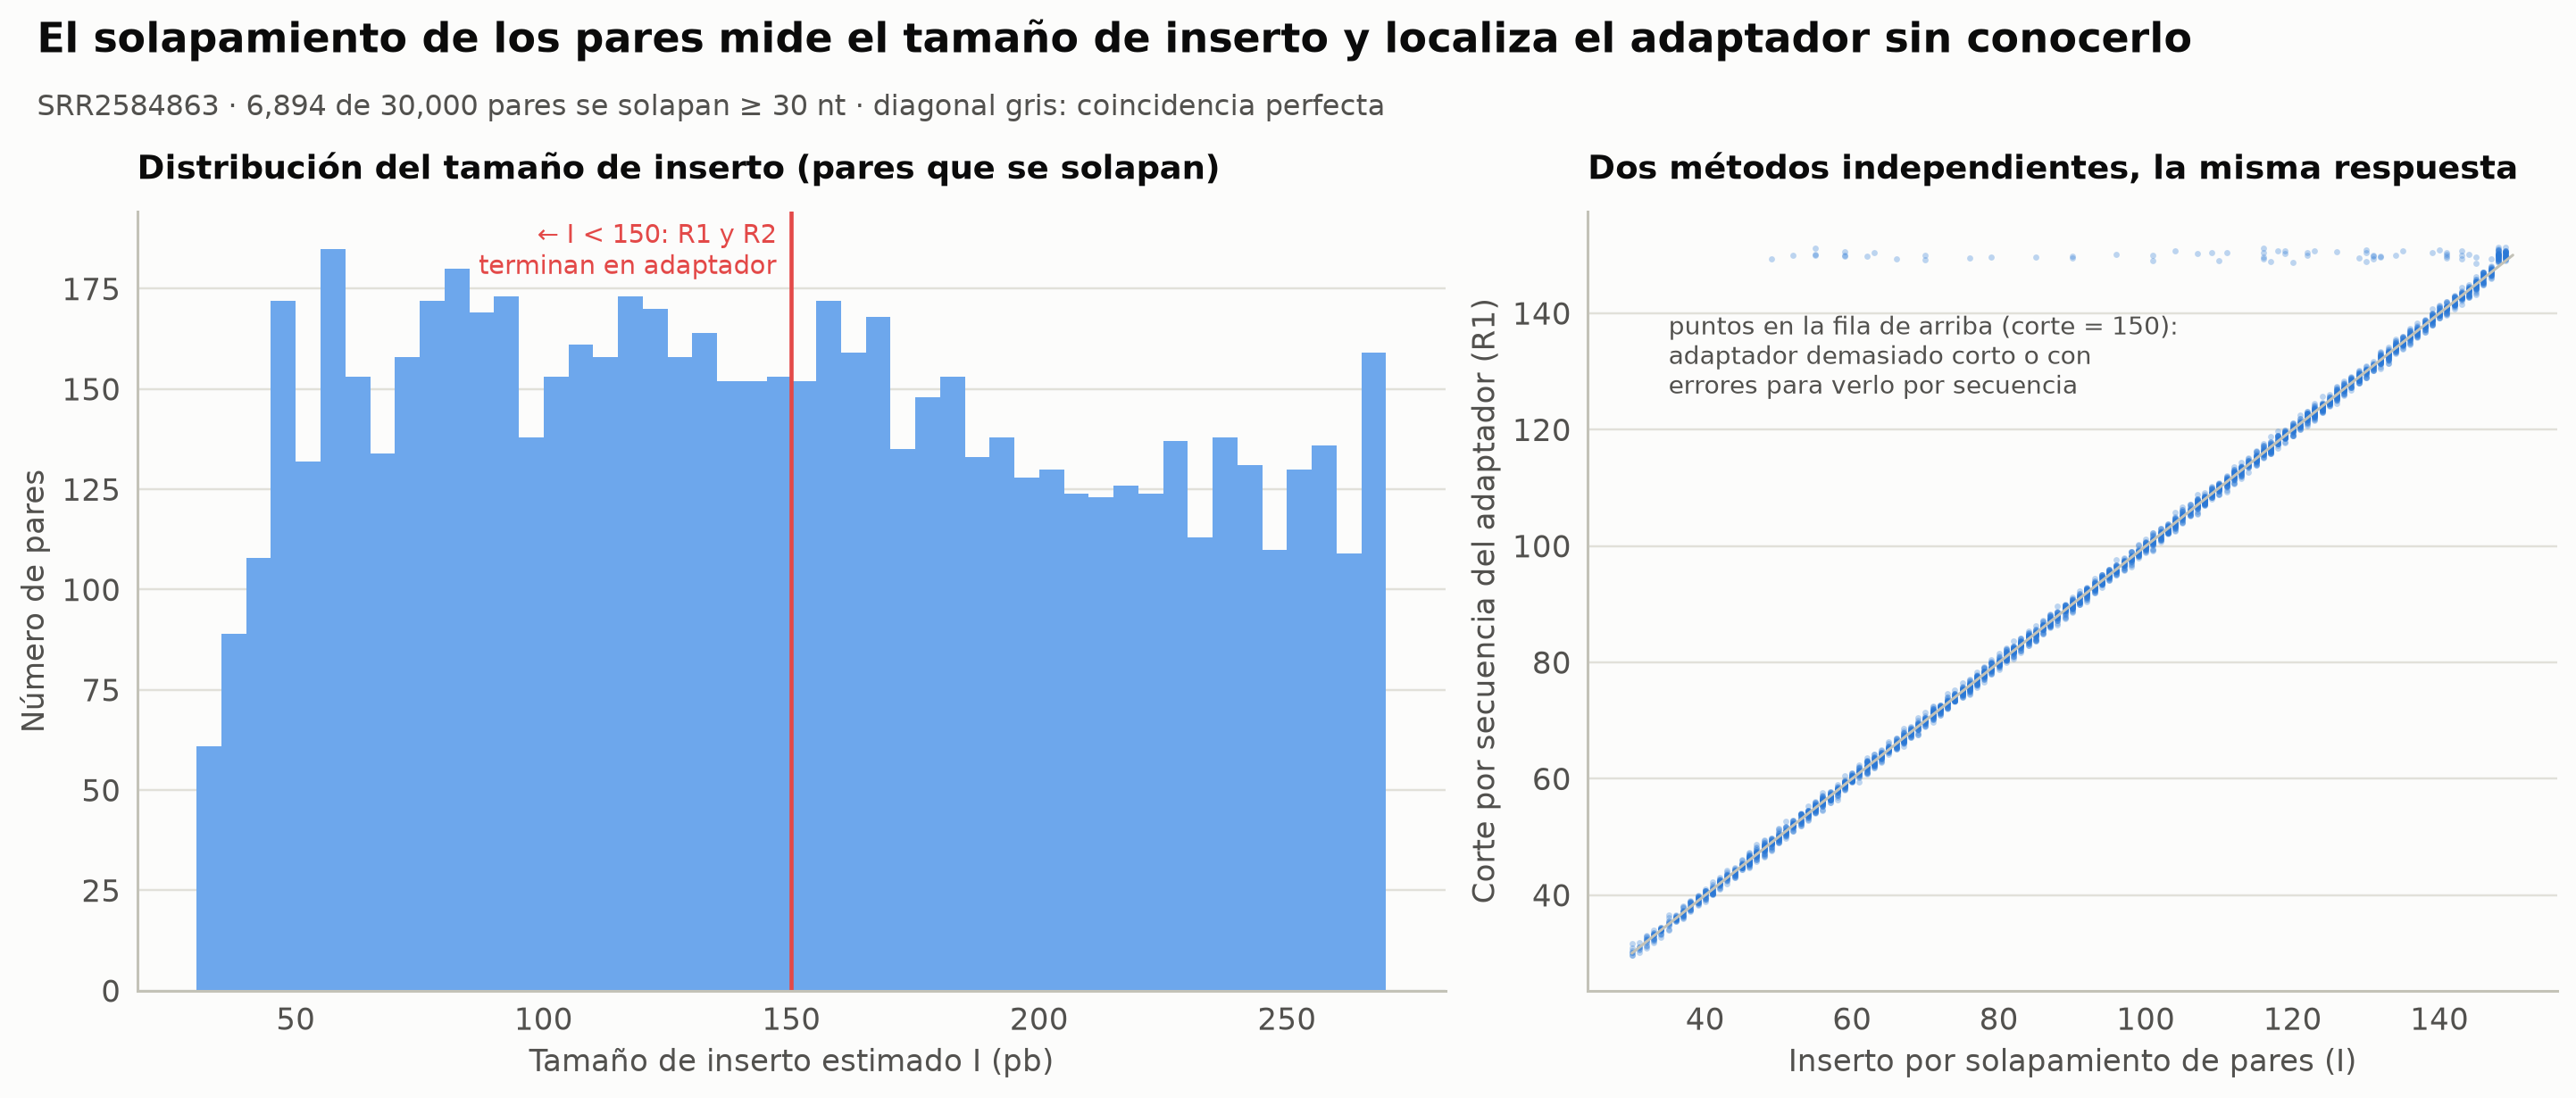

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw=dict(width_ratios=[1.35, 1]))
ax = axes[0]
ax.hist(ins[has_ov], bins=np.arange(30, 2 * L - 29, 5), color=ec.SEQ_BLUE[4])
ax.axvline(L, color=ec.RED, lw=1.5)
ax.text(L - 3, ax.get_ylim()[1] * 0.92, "← I < 150: R1 y R2\nterminan en adaptador", ha="right", fontsize=9.5, color=ec.RED)
ax.set_xlabel("Tamaño de inserto estimado I (pb)"); ax.set_ylabel("Número de pares")
ax.set_title("Distribución del tamaño de inserto (pares que se solapan)", fontsize=12, loc="left")
ax = axes[1]
sel = has_ov & (ins < L)
ax.scatter(ins[sel], cut_ad1[sel] + rng.normal(0, 0.6, sel.sum()), s=5, alpha=0.3, color=ec.BLUE, lw=0)
ax.plot([30, L], [30, L], color=ec.BASELINE, lw=1)
ax.set_xlabel("Inserto por solapamiento de pares (I)"); ax.set_ylabel("Corte por secuencia del adaptador (R1)")
ax.set_title("Dos métodos independientes, la misma respuesta", fontsize=12, loc="left")
ax.text(35, 140, "puntos en la fila de arriba (corte = 150):\nadaptador demasiado corto o con\nerrores para verlo por secuencia",
        fontsize=9, color=ec.INK_2, va="top")
ec.fig_title(fig, "El solapamiento de los pares mide el tamaño de inserto y localiza el adaptador sin conocerlo",
             f"SRR2584863 · {has_ov.sum():,} de {N:,} pares se solapan ≥ 30 nt · diagonal gris: coincidencia perfecta")
plt.show()

> 🔎 **Qué observamos.** Sólo podemos medir el inserto de los pares que se **solapan** (inserto menor que
> $2 \times 150 - 30 = 270$ pb); los insertos más largos no dejan rastro en las lecturas, y son la mayoría (sólo
> ~23 % de los pares se solapan). Entre los que se solapan, la distribución es **ancha y casi plana** entre 40 y 270 pb:
> la fragmentación con Tn5 produce fragmentos de tamaños muy variados. Además, el método tiene un sesgo: un par con
> una cola larga de `#` acumula más de 5 diferencias y no pasa el criterio, así que los solapamientos largos (de
> lecturas malas) se pierden más a menudo que los cortos. Todo lo que está a la izquierda de la línea roja son pares
> con adaptador. En el panel derecho, casi todos los puntos caen sobre la diagonal: el corte por
> secuencia y el tamaño de inserto por solapamiento, dos métodos que no comparten nada, dan la misma respuesta. Los
> puntos por encima de la diagonal son pares con el adaptador demasiado corto (1–2 bases) o con errores: el
> solapamiento los detecta y la búsqueda por secuencia no.

✅ **Compruebe su comprensión.** ¿Por qué el método de solapamiento no sirve para lecturas de un solo extremo
(*single-end*)? ¿Y por qué tampoco puede medir insertos de 400 pb con lecturas de 2 × 150? (Respuesta: necesita las dos
lecturas del mismo fragmento; y con 400 pb, R1 y R2 cubren los extremos del fragmento sin tocarse: queda un hueco de
100 pb sin leer y no hay solapamiento que comparar.)

## 9. Filtros: longitud, N, baja complejidad y errores esperados

Recortar arregla las lecturas; **filtrar** decide cuáles tirar. Después del recorte aplicamos cuatro criterios
sencillos. En datos pareados, si **una** de las dos lecturas no pasa, se descarta el **par** (o se guarda la
sobreviviente aparte, como "huérfana"), para que los archivos R1 y R2 sigan emparejados línea a línea.

**1. Longitud mínima.** Una lectura de 15 bases alinea en muchos sitios del genoma por azar. Un umbral habitual es
36 nt (`MINLEN:36` en muchos protocolos de Trimmomatic) o 50 nt en genomas grandes.

**2. Demasiadas N.** fastp descarta por defecto lecturas con más de 5 N.

**3. Baja complejidad.** Lecturas como `AAAAAAAAAAAAAAAAAAAC` o `GGGGGGGGGG…` suelen ser artefactos (colas poli-A,
poli-G de los equipos de dos colores). fastp mide la complejidad como la fracción de bases distintas de la siguiente:

$$
\mathrm{complejidad} \;=\; \frac{\#\{\,i : b_i \ne b_{i+1}\,\}}{L - 1}
$$

**Ejemplo a mano.** `AAAAAAAAAC` (10 bases): sólo la pareja $b_9 b_{10}$ = `AC` es distinta, así que la complejidad es
$1/9 = 11\,\%$, por debajo del umbral de fastp (30 %): se descarta. `ACGTTGCAAC` tiene 7 cambios en 9 parejas: 78 %.

**4. Errores esperados máximos (*maxEE*).** En la Lección 2.1 definimos los errores esperados de una lectura,
$\mathrm{EE} = \sum_j 10^{-Q_j/10}$, y vimos que describen mejor la calidad que el promedio de Phred. El filtro *maxEE*
(Edgar y Flyvbjerg, 2015) descarta las lecturas con $\mathrm{EE} > E_{\max}$ **después** del recorte. El tutorial de
DADA2, por ejemplo, usa $E_{\max} = 2$.

| Símbolo | Significado |
|---|---|
| $b_i$ | base en la posición $i$ |
| $L$ | longitud de la lectura (después del recorte) |
| $Q_j$ | calidad Phred de la base $j$ |
| $\mathrm{EE}$ | errores esperados: número promedio de bases equivocadas en la lectura |
| $E_{\max}$ | máximo de errores esperados permitido |

**Ejemplo a mano.** Una lectura recortada de 100 bases, 90 con Q35 y 10 con Q20:
$\mathrm{EE} = 90 \times 10^{-3.5} + 10 \times 10^{-2} = 0.028 + 0.100 = 0.128$: pasa holgadamente. Si en lugar de
recortarla hubiéramos conservado 30 bases más con Q5 ($P = 0.316$ cada una), EE subiría en $30 \times 0.316 = 9.5$:
esa lectura sin recortar tendría unos 10 errores esperados. El recorte y el filtro trabajan juntos.

**Los ejemplos del libro.** La lectura FASTQ de 24 bases del capítulo 6 tiene calidades
`34 35 37 37 38 38 37 36 38 37 36 35 36 33 32 30 31 27 25 22 20 14 11 2`. Sus errores esperados suman
$\mathrm{EE} = 0.78$, pero $0.63$ vienen de **una sola base**, la última ($Q2$, $p = 10^{-0.2} \approx 0.63$); las 20
primeras, todas con $Q \ge 20$, aportan menos de $0.02$. Recortar las cuatro últimas bases elimina más del 95 % de los
errores esperados. A mayor escala, con 150 bases de calidad uniforme, la probabilidad de una lectura **sin ningún
error** es $\Pr(X = 0) = (1 - p)^{150}$: $0.999^{150} \approx 0.86$ a Q30, pero $0.99^{150} \approx 0.22$ a Q20. Diez
unidades de Phred separan "casi todas las lecturas son perfectas" de "casi cuatro de cada cinco tienen algún error".

In [35]:
# Ejemplos del libro: errores esperados de la lectura de 24 bases y lecturas perfectas a Q20 y Q30
q24 = np.array([34, 35, 37, 37, 38, 38, 37, 36, 38, 37, 36, 35, 36, 33, 32, 30, 31, 27, 25, 22, 20, 14, 11, 2])
p24 = 10 ** (-q24 / 10)
print(f"EE total = {p24.sum():.2f} · última base (Q2) = {p24[-1]:.2f} · 20 primeras = {p24[:20].sum():.3f} · "
      f"eliminado al recortar las 4 últimas = {p24[-4:].sum() / p24.sum():.1%}")
for Qu in (30, 20):
    pu = 10 ** (-Qu / 10)
    print(f"150 bases a Q{Qu}: EE = {150 * pu:.2f} · P(X = 0) = (1 − {pu})^150 = {(1 - pu) ** 150:.2f}")

EE total = 0.78 · última base (Q2) = 0.63 · 20 primeras = 0.017 · eliminado al recortar las 4 últimas = 97.8%
150 bases a Q30: EE = 0.15 · P(X = 0) = (1 − 0.001)^150 = 0.86
150 bases a Q20: EE = 1.50 · P(X = 0) = (1 − 0.01)^150 = 0.22


In [36]:
def complexity(S, keep):
    """Fracción de posiciones i (dentro del tramo conservado) con b_i ≠ b_{i+1}."""
    diff = S[:, 1:] != S[:, :-1]
    inside = np.arange(S.shape[1] - 1)[None, :] < (keep[:, None] - 1)
    return (diff & inside).sum(1) / np.maximum(keep - 1, 1)

def expected_errors(Q, keep):
    P = 10 ** (-Q / 10)
    return np.where(np.arange(Q.shape[1])[None, :] < keep[:, None], P, 0).sum(1)

def n_count(S, keep):
    return ((S == ord("N")) & (np.arange(S.shape[1])[None, :] < keep[:, None])).sum(1)

for s in ["AAAAAAAAAC", "ACGTTGCAAC"]:
    arr = np.frombuffer(s.encode(), np.uint8)[None]
    print(s, f"complejidad = {complexity(arr, np.array([len(s)]))[0]:.0%}")
print("EE (90 × Q35 + 10 × Q20) =", round(90 * 10 ** -3.5 + 10 * 10 ** -2, 3))

AAAAAAAAAC complejidad = 11%
ACGTTGCAAC complejidad = 78%
EE (90 × Q35 + 10 × Q20) = 0.128


## 10. Nuestro limpiador completo: antes y después

Juntemos todas las piezas en una función. El orden importa: primero se quitan los **adaptadores** (si no, sus bases,
que pueden tener buena calidad, "protegerían" la cola del recorte por calidad), después se **recorta por calidad** y al
final se **filtra**.

1. **Adaptadores:** el corte es el menor entre la búsqueda del adaptador Nextera (10 % de errores) y el tamaño de
   inserto por solapamiento de pares, si este es menor que 150.
2. **Calidad:** ventana deslizante de 4 bases con $t = 20$ (la misma regla que `fastp --cut_right`, para poder
   comparar en la sección 11).
3. **Filtros:** longitud ≥ 36, como mucho 5 N, complejidad ≥ 30 % y EE ≤ 2, exigidos a **las dos** lecturas del par.

> 🤔 **Antes de ejecutar, prediga:** ¿qué porcentaje de los pares sobrevivirá? ¿Cuál cree que será el filtro que más
> pares elimina?

In [37]:
MIN_LEN, MAX_N, MIN_COMPLEXITY, MAX_EE = 36, 5, 0.30, 2.0

def clean_pairs(S1, Q1, S2, Q2, cut_ad1, cut_ad2, ins, w=4, t=20):
    """Devuelve las longitudes conservadas de R1 y R2 y una tabla con el motivo de descarte de cada par."""
    Lr = S1.shape[1]
    out = {}
    for mate, S, Q, cut_ad in [("R1", S1, Q1, cut_ad1), ("R2", S2, Q2, cut_ad2)]:
        cut = np.minimum(cut_ad, np.where((ins > 0) & (ins < Lr), ins, Lr))          # 1) adaptadores
        Qm = np.where(np.arange(Lr)[None, :] < cut[:, None], Q, 40).astype(float)    # lo ya cortado no cuenta
        keep = np.minimum(cut, vec_sliding(Qm, w, t))                                # 2) calidad
        out[mate] = dict(adapter_cut=cut < Lr, keep=keep,
                         short=keep < MIN_LEN, many_n=n_count(S, keep) > MAX_N,       # 3) filtros
                         low_cx=complexity(S, keep) < MIN_COMPLEXITY,
                         high_ee=expected_errors(Q, keep) > MAX_EE)
    return out

t0 = time.time()
res = clean_pairs(S1, Q1, S2, Q2, cut_ad1, cut_ad2, ins)
print(f"Limpieza de {N:,} pares en {time.time() - t0:.2f} s")

# Cascada: cada filtro se aplica a los pares que sobrevivieron a los anteriores
alive = np.ones(N, bool)
steps_tbl = [("pares de entrada", N, 0)]
for key, lab in [("short", f"longitud < {MIN_LEN}"), ("many_n", f"más de {MAX_N} N"),
                 ("low_cx", "complejidad < 30 %"), ("high_ee", f"EE > {MAX_EE:g}")]:
    fail = res["R1"][key] | res["R2"][key]
    removed = int((alive & fail).sum())
    alive &= ~fail
    steps_tbl.append((lab, int(alive.sum()), removed))
funnel = pd.DataFrame(steps_tbl, columns=["paso", "pares que quedan", "pares eliminados"])
funnel["% que queda"] = (100 * funnel["pares que quedan"] / N).round(1)
passed = alive
k1, k2 = res["R1"]["keep"], res["R2"]["keep"]
print(f"Lecturas con adaptador recortado: R1 {res['R1']['adapter_cut'].mean():.1%} · R2 {res['R2']['adapter_cut'].mean():.1%}")
print(f"Bases conservadas en los pares que pasan: {(k1[passed].sum() + k2[passed].sum()) / (2 * N * L):.1%} del total")
funnel

Limpieza de 30,000 pares en 0.16 s
Lecturas con adaptador recortado: R1 14.6% · R2 14.6%
Bases conservadas en los pares que pasan: 70.0% del total


,paso,pares que quedan,pares eliminados,% que queda
0,pares de entrada,30000,0,100.0
1,longitud < 36,25541,4459,85.1
2,más de 5 N,25541,0,85.1
3,complejidad < 30 %,25541,0,85.1
4,EE > 2,25541,0,85.1


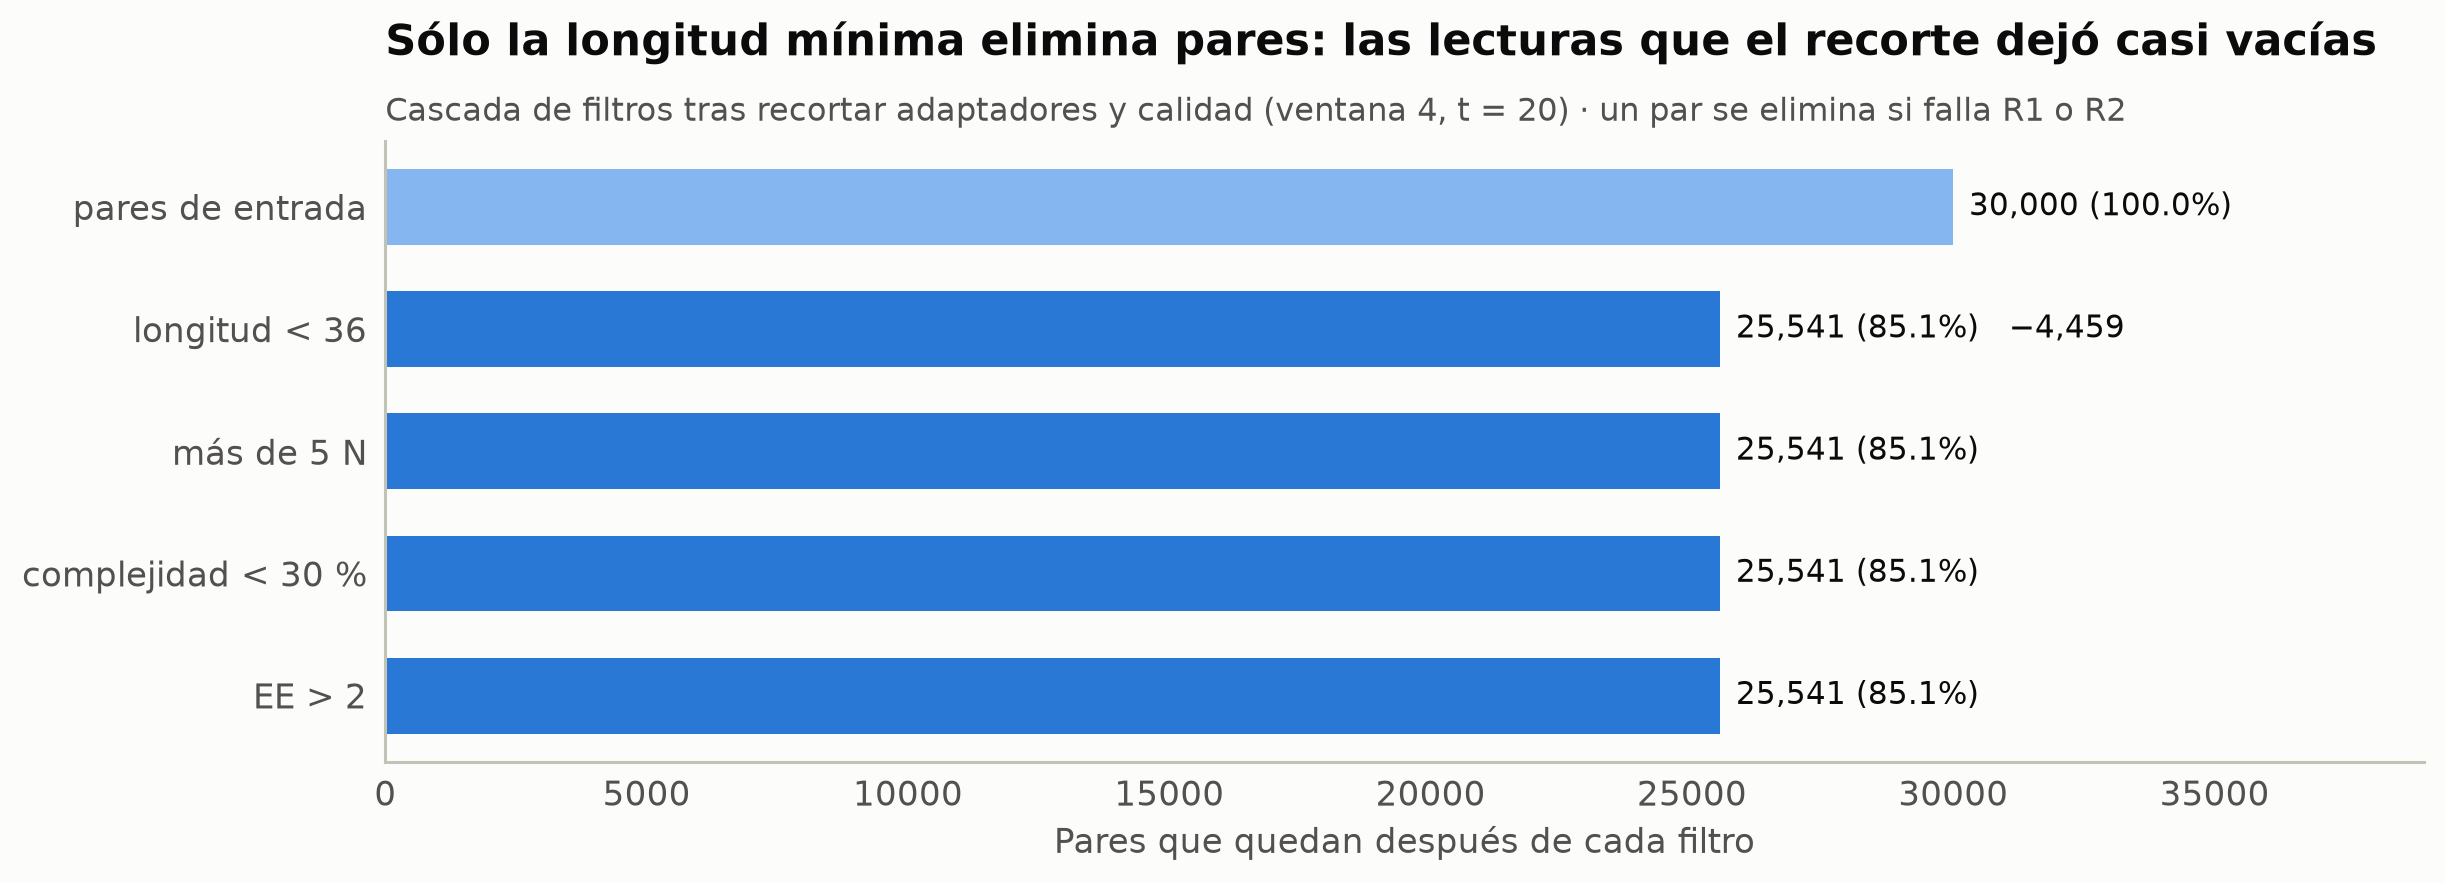

In [38]:
fig, ax = plt.subplots(figsize=(11, 3.9))
labels = funnel["paso"].tolist()
vals = funnel["pares que quedan"].to_numpy()
ypos = np.arange(len(labels))[::-1]
ax.barh(ypos, vals, color=[ec.SEQ_BLUE[3]] + [ec.BLUE] * (len(vals) - 1), height=0.62)
for y, v, r in zip(ypos, vals, funnel["pares eliminados"]):
    ax.text(v + N * 0.01, y, f"{v:,} ({v / N:.1%})" + (f"   −{r:,}" if r else ""), va="center", fontsize=10,
            color=ec.INK)
ax.set_yticks(ypos, labels); ax.set_xlim(0, N * 1.3); ax.grid(False)
ax.set_xlabel("Pares que quedan después de cada filtro")
ec.title(ax, "Sólo la longitud mínima elimina pares: las lecturas que el recorte dejó casi vacías",
         "Cascada de filtros tras recortar adaptadores y calidad (ventana 4, t = 20) · un par se elimina si falla R1 o R2")
plt.show()

> 🔎 **Qué observamos.** Casi todos los pares descartados lo son por **longitud**: son lecturas que el recorte dejó en
> casi nada (colas de `#` que empezaban muy pronto, sobre todo en R2, o insertos cortísimos). Después del recorte,
> el filtro de EE no elimina ni un solo par: las bases malas ya se fueron. Las N y la baja complejidad casi no aparecen en
> este conjunto (no es un equipo de dos colores, no hay colas poli-G). Recuerde que esta muestra viene del borde de la
> celda de flujo: en el conjunto completo la supervivencia sería mayor.

### La comparación que importa: antes y después

El paso más importante de una limpieza es **volver a mirar**. Construyamos las mismas gráficas de calidad antes y
después, sólo con los pares que sobrevivieron y sólo con las bases que conservamos.

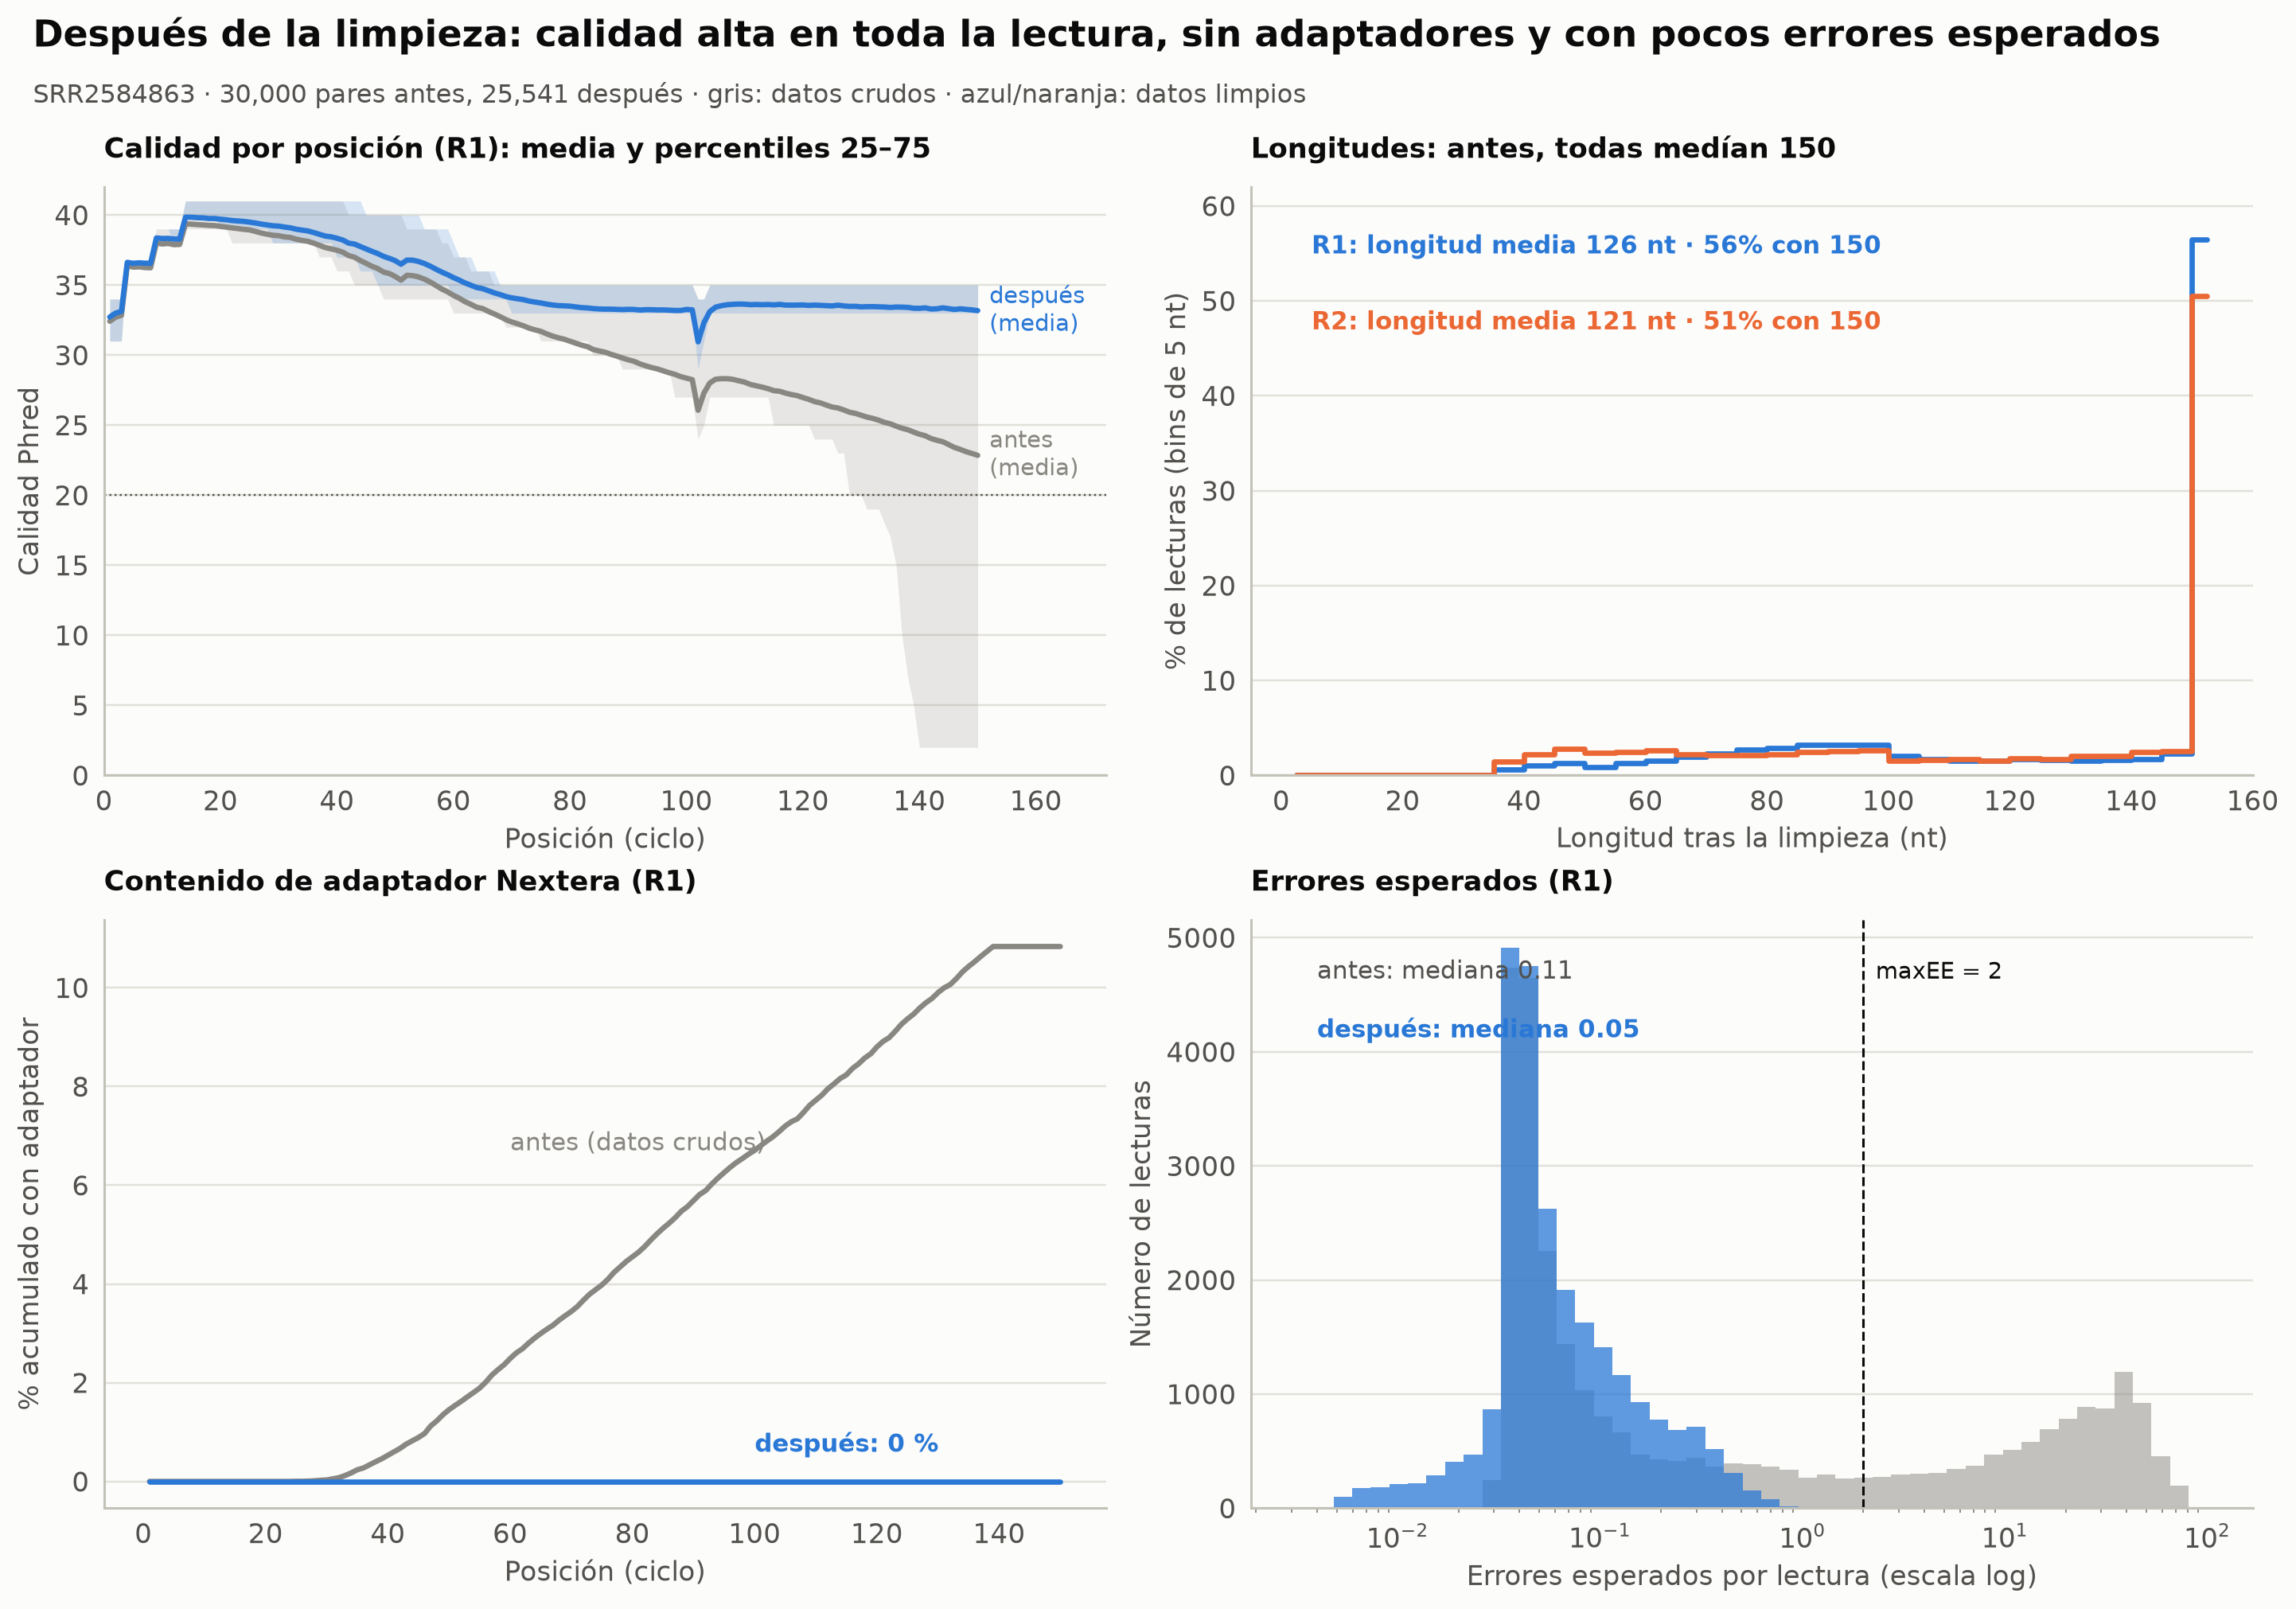

In [39]:
valid1 = np.arange(L)[None, :] < k1[:, None]
valid2 = np.arange(L)[None, :] < k2[:, None]
after_valid1, after_valid2 = valid1[passed], valid2[passed]

def adapter_curve(first, valid=None, keep=None):
    """% acumulado de lecturas con el 12-mero de Nextera a partir de la posición j (sólo dentro de lo conservado)."""
    ok = first >= 0
    if keep is not None:
        ok &= first + K12 <= keep
    return np.array([np.mean(ok & (first <= j)) for j in range(L)])

first1 = content[("R1", "Nextera")][0]
fig, axes = plt.subplots(2, 2, figsize=(13, 8.4))
ax = axes[0, 0]
for Q, val, col, lab in [(Q1, None, ec.MUTED, "antes"), (Q1[passed], after_valid1, ec.BLUE, "después")]:
    pct, mean = per_position_stats(Q, val)
    ax.fill_between(pos, pct[1], pct[3], color=col, alpha=0.18, lw=0)
    ax.plot(pos, mean, color=col, lw=2.2)
    ax.text(L + 2, mean[-1], f"{lab}\n(media)", color=col, fontsize=9.5, va="center")
ax.axhline(20, color=ec.INK_2, lw=0.8, ls=":")
ax.set_xlim(0, L + 22); ax.set_ylim(0, 42); ax.set_xlabel("Posición (ciclo)"); ax.set_ylabel("Calidad Phred")
ax.set_title("Calidad por posición (R1): media y percentiles 25–75", fontsize=11.5, loc="left")

ax = axes[0, 1]
bins_l = np.arange(0, L + 6, 5)
for kl, col, lab, dy in [(k1[passed], ec.BLUE, "R1", 0), (k2[passed], ec.ORANGE, "R2", 1)]:
    h, _ = np.histogram(kl, bins=bins_l)
    ax.step(bins_l[:-1] + 2.5, 100 * h / passed.sum(), where="mid", color=col, lw=2.2)
    ax.text(5, 55 - 8 * dy, f"{lab}: longitud media {kl.mean():.0f} nt · {np.mean(kl == L):.0%} con 150",
            color=col, fontsize=10, fontweight="bold")
ax.set_xlabel("Longitud tras la limpieza (nt)"); ax.set_ylabel("% de lecturas (bins de 5 nt)")
ax.set_ylim(0, 62)
ax.set_title("Longitudes: antes, todas medían 150", fontsize=11.5, loc="left")

ax = axes[1, 0]
ax.plot(pos, 100 * adapter_curve(first1), color=ec.MUTED, lw=2.2)
ax.plot(pos, 100 * adapter_curve(first1[passed], keep=k1[passed]), color=ec.BLUE, lw=2.2)
ax.text(60, 100 * adapter_curve(first1)[99], "antes (datos crudos)", color=ec.MUTED, fontsize=10)
ax.text(100, 0.6, "después: 0 %", color=ec.BLUE, fontsize=10, fontweight="bold")
ax.set_xlabel("Posición (ciclo)"); ax.set_ylabel("% acumulado con adaptador")
ax.set_title("Contenido de adaptador Nextera (R1)", fontsize=11.5, loc="left")

ax = axes[1, 1]
ee_before = (10 ** (-Q1 / 10)).sum(1)
ee_after = expected_errors(Q1, k1)[passed]
bins_e = np.logspace(-2.5, 2, 50)
ax.hist(ee_before, bins=bins_e, color=ec.MUTED, alpha=0.5)
ax.hist(ee_after, bins=bins_e, color=ec.BLUE, alpha=0.75)
ax.set_xscale("log"); ax.axvline(MAX_EE, color=ec.INK, lw=1, ls="--")
ax.text(MAX_EE * 1.15, ax.get_ylim()[1] * 0.9, f"maxEE = {MAX_EE:g}", fontsize=9.5, color=ec.INK)
ax.text(0.004, ax.get_ylim()[1] * 0.9, f"antes: mediana {np.median(ee_before):.2f}", color=ec.INK_2, fontsize=10)
ax.text(0.004, ax.get_ylim()[1] * 0.8, f"después: mediana {np.median(ee_after):.2f}", color=ec.BLUE, fontsize=10,
        fontweight="bold")
ax.set_xlabel("Errores esperados por lectura (escala log)"); ax.set_ylabel("Número de lecturas")
ax.set_title("Errores esperados (R1)", fontsize=11.5, loc="left")
ec.fig_title(fig, "Después de la limpieza: calidad alta en toda la lectura, sin adaptadores y con pocos errores esperados",
             f"SRR2584863 · {N:,} pares antes, {passed.sum():,} después · gris: datos crudos · azul/naranja: datos limpios")
plt.show()

> 🔎 **Qué observamos.** Los cuatro paneles cuentan la misma historia desde ángulos distintos. (1) La calidad media ya
> no se desploma al final: las colas malas se fueron (la media del final se calcula ahora con menos lecturas, las que
> conservaron esas posiciones). (2) Las longitudes ya no son todas 150: aparece la distribución típica de datos
> limpios, con un pico en 150 y una cola de lecturas recortadas. (3) El adaptador desapareció por completo.
> (4) Los errores esperados bajaron casi un orden de magnitud y ninguna lectura supera el máximo.
>
> ¿Se perdió algo valioso? Perdimos alrededor de un tercio de las bases, pero eran, en su mayoría, bases con Q2
> o adaptador. Un alineador hubiera tenido que lidiar con ellas de todas formas, y algunas habrían producido falsos
> desajustes. Es un buen trato.

Por último, guardamos los pares limpios en dos FASTQ comprimidos, con el mismo orden en ambos archivos:

In [40]:
def write_fastq_gz(path, heads, seqs, quals, keep, mask):
    with gzip.open(path, "wt") as fh:
        for h, s, q, k, m in zip(heads, seqs, quals, keep, mask):
            if m:
                fh.write(f"@{h}\n{s[:k]}\n+\n{q[:k]}\n")

write_fastq_gz(f"{RUN}_clean_1.fastq.gz", heads1, seqs1, quals1, k1, passed)
write_fastq_gz(f"{RUN}_clean_2.fastq.gz", heads2, seqs2, quals2, k2, passed)
for f in [f"{RUN}_clean_1.fastq.gz", f"{RUN}_clean_2.fastq.gz"]:
    print(f, f"{os.path.getsize(f) / 1e6:.1f} MB")

SRR2584863_clean_1.fastq.gz 2.6 MB
SRR2584863_clean_2.fastq.gz 2.7 MB


## 11. 🧪 fastp en Colab y su informe JSON; MultiQC

Lo que hicimos a mano es exactamente lo que hacen las herramientas profesionales, sólo que escrito en C/C++ o Java y
con muchos más detalles resueltos. Las más usadas:

| Herramienta | Qué hace | Referencia |
|---|---|---|
| **FastQC** | diagnóstico (los módulos de las secciones 3–6), informe HTML | Andrews, 2010 |
| **Trimmomatic** | recorte por calidad (`SLIDINGWINDOW`, `LEADING`, `TRAILING`), adaptadores (`ILLUMINACLIP`), `MINLEN` | Bolger, Lohse y Usadel, 2014 |
| **Cutadapt** | recorte de adaptadores por alineamiento semiglobal con tasa de error; recorte BWA con `-q` | Martin, 2011 |
| **fastp** | todo en uno y muy rápido: diagnóstico antes/después, adaptadores (por secuencia y por solapamiento), ventanas, filtros, informe HTML y JSON | Chen *et al.*, 2018 |
| **MultiQC** | reúne los informes de muchas muestras y herramientas en un solo HTML | Ewels *et al.*, 2016 |

Usaremos **fastp** con parámetros equivalentes a los de nuestro limpiador:

| Opción de fastp | Significado | En nuestro código |
|---|---|---|
| `--detect_adapter_for_pe` | detecta el adaptador por solapamiento y por secuencia | sección 8 |
| `--cut_right --cut_right_window_size 4 --cut_right_mean_quality 20` | ventana deslizante desde el 5′; corta en la primera ventana con media < 20 | `vec_sliding(Q, 4, 20)` |
| `-l 36` | longitud mínima | `MIN_LEN` |
| `-n 5` | máximo de N | `MAX_N` |
| `--low_complexity_filter` | complejidad ≥ 30 % | `MIN_COMPLEXITY` |
| (por defecto) `-q 15 -u 40` | **filtro** de calidad: descarta la lectura si más del 40 % de sus bases tienen Q < 15 | nosotros usamos maxEE |

Ojo con la última fila: fastp **filtra** por calidad por defecto, además de recortar si se lo pedimos. Son dos cosas
distintas: el filtro decide si la lectura entera se tira; el recorte decide cuánto se conserva. Si se ejecuta fastp
sin `--cut_right`, muchas lecturas con cola de `#` se descartan enteras en lugar de recortarse (en este archivo, casi
un 20 % de las lecturas).

La celda siguiente instala fastp en Colab (binario oficial de OpenGene y, si falla, el paquete de Ubuntu). Fuera de
Colab usa el que encuentre en el `PATH`; si no hay ninguno, carga el informe JSON precalculado que acompaña al curso
(fastp 1.3.7 con la misma orden).

In [41]:
FASTP_URL = "http://opengene.org/fastp/fastp"             # binario estático oficial para Linux (OpenGene)

def find_fastp():
    if shutil.which("fastp"):
        return shutil.which("fastp")
    return os.path.abspath("fastp") if os.path.exists("fastp") else None

FASTP = find_fastp()
if FASTP is None and IN_COLAB:
    try:                                                   # 1) binario estático oficial
        urllib.request.urlretrieve(FASTP_URL, "fastp")
        os.chmod("fastp", 0o755)
        subprocess.run(["./fastp", "--version"], check=True, capture_output=True)
    except Exception as err:                               # 2) paquete de Ubuntu (versión más antigua)
        print("⚠️ No se pudo usar el binario oficial:", err, "→ pruebo apt")
        !apt-get -qq install -y fastp > /dev/null
    FASTP = find_fastp()

HAS_FASTP = FASTP is not None
if HAS_FASTP:
    v = subprocess.run([FASTP, "--version"], capture_output=True, text=True)
    print("fastp disponible:", FASTP, "·", (v.stdout + v.stderr).strip())
else:
    print("⚠️ fastp no está disponible aquí: usaré el informe JSON precalculado del curso (fastp 1.3.7).")

⚠️ fastp no está disponible aquí: usaré el informe JSON precalculado del curso (fastp 1.3.7).


In [42]:
FASTP_JSON = f"fastp_{RUN}_30k.json"
if HAS_FASTP:
    for mate, raw in ((1, raw1), (2, raw2)):              # los datos crudos del curso, como archivos de entrada
        with open(f"{RUN}_30k_{mate}.fastq.gz", "wb") as fh:
            fh.write(gzip.compress(raw))
    cmd = [FASTP, "-i", f"{RUN}_30k_1.fastq.gz", "-I", f"{RUN}_30k_2.fastq.gz",
           "-o", f"{RUN}_30k_1.clean.fastq.gz", "-O", f"{RUN}_30k_2.clean.fastq.gz",
           "--detect_adapter_for_pe", "--cut_right", "--cut_right_window_size", "4", "--cut_right_mean_quality", "20",
           "-l", "36", "-n", "5", "--low_complexity_filter", "-w", "2", "-j", "fastp.json", "-h", "fastp.html"]
    print("$", " ".join(["fastp"] + cmd[1:]))
    t0 = time.time()
    run = subprocess.run(cmd, capture_output=True, text=True)
    print(f"Terminado en {time.time() - t0:.1f} s (código {run.returncode})")
    print("\n".join(run.stderr.splitlines()[-14:-4]))
    report_fp = json.load(open("fastp.json"))
else:
    report_fp = json.loads(course_bytes(f"api_cache/{FASTP_JSON}"))
    print("Orden usada para el informe precalculado:\n$", report_fp.get("command", ""))

Orden usada para el informe precalculado:
$ fastp -i SRR2584863_30k_1.fastq.gz -I SRR2584863_30k_2.fastq.gz -o SRR2584863_30k_1.clean.fastq.gz -O SRR2584863_30k_2.clean.fastq.gz --detect_adapter_for_pe --cut_right --cut_right_window_size 4 --cut_right_mean_quality 20 -l 36 -n 5 --low_complexity_filter -w 2 -j fastp.json -h fastp.html


### Leer el informe JSON de fastp

fastp escribe dos informes: un HTML para mirar y un **JSON** para programar. El JSON es un diccionario anidado:
`summary` (antes y después), `filtering_result` (por qué se descartó cada lectura), `adapter_cutting`, `duplication`,
`insert_size` y, para cada lectura antes y después, `quality_curves`, `content_curves`, etc. Usamos `.get(...)` para
que el código funcione aunque la versión de fastp (la de Ubuntu es más antigua) no traiga alguna clave.

In [43]:
summ = report_fp.get("summary", {})
before, after = summ.get("before_filtering", {}), summ.get("after_filtering", {})
filt = report_fp.get("filtering_result", {})
adc = report_fp.get("adapter_cutting", {})
ins_fp = report_fp.get("insert_size", {})

print("fastp", summ.get("fastp_version", "(versión no informada)"), "·", summ.get("sequencing", ""))
print(f"Adaptador detectado en R1: {adc.get('read1_adapter_sequence', '?')}")
print(f"Adaptador detectado en R2: {adc.get('read2_adapter_sequence', '?')}")
print(f"Duplicación estimada por fastp: {report_fp.get('duplication', {}).get('rate', float('nan')):.2%} · "
      f"pico del tamaño de inserto: {ins_fp.get('peak', '?')} pb")

ours_bases = int(k1[passed].sum() + k2[passed].sum())
compare = pd.DataFrame({
    "nuestro limpiador": [2 * N, int(2 * passed.sum()), f"{ours_bases / (2 * N * L):.1%}",
                          int(res["R1"]["adapter_cut"].sum() + res["R2"]["adapter_cut"].sum()),
                          f"{k1[passed].mean():.0f} / {k2[passed].mean():.0f}",
                          f"{(Q1[passed][after_valid1] >= 30).mean():.1%}"],
    "fastp": [before.get("total_reads"), filt.get("passed_filter_reads", after.get("total_reads")),
              f"{after.get('total_bases', np.nan) / before.get('total_bases', np.nan):.1%}",
              adc.get("adapter_trimmed_reads"),
              f"{after.get('read1_mean_length', np.nan)} / {after.get('read2_mean_length', np.nan)}",
              f"{after.get('q30_rate', np.nan):.1%}"]},
    index=["lecturas de entrada", "lecturas que pasan", "bases conservadas", "lecturas con adaptador recortado",
           "longitud media R1 / R2", "bases ≥ Q30 después (R1 nuestro; R1+R2 fastp)"])
print("\nMotivos de descarte según fastp:", {k: v for k, v in filt.items() if k != "passed_filter_reads"})
compare

fastp 1.3.7 · paired end (150 cycles + 150 cycles)
Adaptador detectado en R1: CTGTCTCTTATACACATCTCCGAGCCCACGAGAC
Adaptador detectado en R2: CTGTCTCTTATACACATCTGACGCTGCCGACGA
Duplicación estimada por fastp: 0.00% · pico del tamaño de inserto: 150 pb

Motivos de descarte según fastp: {'low_quality_reads': 2, 'too_many_N_reads': 0, 'low_complexity_reads': 0, 'adapter_dimer_reads': 4, 'too_short_reads': 8732, 'too_long_reads': 0}


,nuestro limpiador,fastp
lecturas de entrada,60000,60000
lecturas que pasan,51082,51262
bases conservadas,70.0%,70.3%
lecturas con adaptador recortado,8734,6820
longitud media R1 / R2,126 / 121,126 / 120
bases ≥ Q30 después (R1 nuestro; R1+R2 fastp),93.9%,92.6%


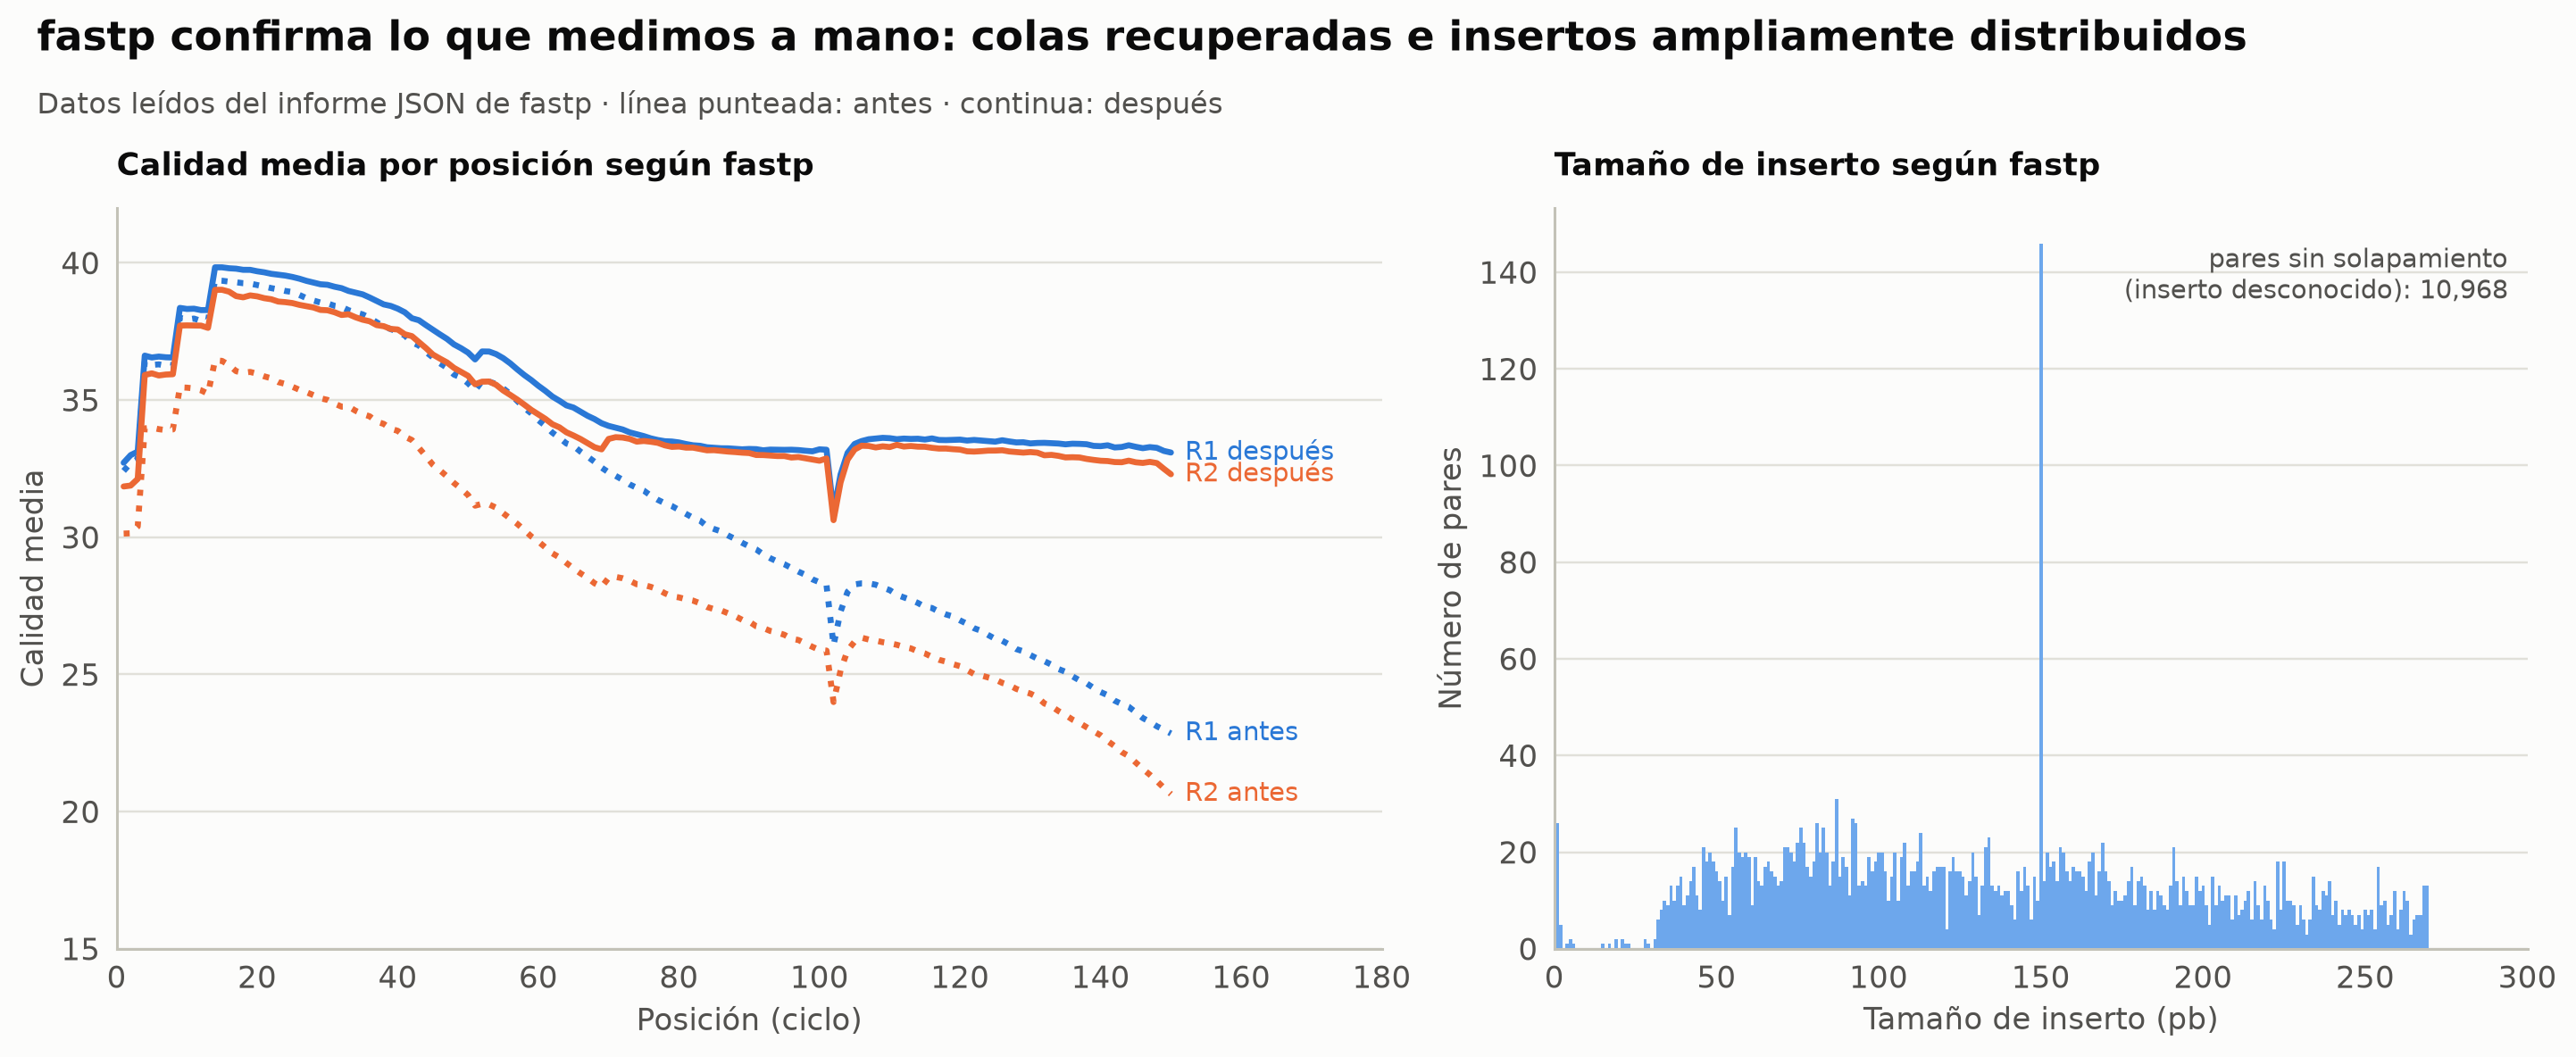

In [44]:
qc = {k: report_fp.get(k, {}).get("quality_curves", {}).get("mean")
      for k in ["read1_before_filtering", "read1_after_filtering", "read2_before_filtering", "read2_after_filtering"]}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw=dict(width_ratios=[1.3, 1]))
ax = axes[0]
for key, col, ls, lab in [("read1_before_filtering", ec.BLUE, ":", "R1 antes"), ("read2_before_filtering", ec.ORANGE, ":", "R2 antes"),
                          ("read1_after_filtering", ec.BLUE, "-", "R1 después"), ("read2_after_filtering", ec.ORANGE, "-", "R2 después")]:
    if qc[key]:
        y = np.array(qc[key])
        ax.plot(np.arange(1, len(y) + 1), y, color=col, ls=ls, lw=2.2)
        ax.text(len(y) + 2, y[-1], lab, color=col, fontsize=9.5, va="center")
ax.set_xlim(0, L + 30); ax.set_ylim(15, 42)
ax.set_xlabel("Posición (ciclo)"); ax.set_ylabel("Calidad media")
ax.set_title("Calidad media por posición según fastp", fontsize=11.5, loc="left")
ax = axes[1]
hist = np.array(ins_fp.get("histogram", []))
if hist.size:
    xs = np.arange(len(hist))
    ax.bar(xs[:300], hist[:300], width=1, color=ec.SEQ_BLUE[4])
    ax.set_xlim(0, 300)
    ax.text(0.98, 0.95, f"pares sin solapamiento\n(inserto desconocido): {ins_fp.get('unknown', 0):,}",
            transform=ax.transAxes, ha="right", va="top", fontsize=9.5, color=ec.INK_2)
ax.set_xlabel("Tamaño de inserto (pb)"); ax.set_ylabel("Número de pares")
ax.set_title("Tamaño de inserto según fastp", fontsize=11.5, loc="left")
ec.fig_title(fig, "fastp confirma lo que medimos a mano: colas recuperadas e insertos ampliamente distribuidos",
             "Datos leídos del informe JSON de fastp · línea punteada: antes · continua: después")
plt.show()

> 🔎 **Qué observamos.** Nuestros números y los de fastp son muy parecidos (fracción de pares que pasan, bases
> conservadas, longitud media), aunque no idénticos: fastp detecta los adaptadores con su propia combinación de
> solapamiento y secuencia, usa su filtro de calidad Q15/40 % en lugar de nuestro maxEE, y aplica la ventana al
> extremo 3′ del adaptador ya recortado con reglas algo distintas. El 0 % de duplicación que informa fastp coincide con
> lo que vimos al comparar **pares** en la sección 5. En su histograma de insertos, fastp acumula en 150 los pares que
> se solapan por completo, y deja como "desconocido" a la mayoría, que no se solapan.
>
> La diferencia en "lecturas con adaptador recortado" tiene una explicación concreta: nuestra búsqueda encontró
> adaptador en ≈ 14.1 % de las lecturas, pero ≈ 2.5 % eran coincidencias al azar de 3–5 bases (sección 8.2), que
> fastp no recorta; 14.1 − 2.5 ≈ 11.6 %, prácticamente el 11.4 % de fastp (6 820 de 60 000).
>
> La lección práctica: con parámetros equivalentes, herramientas distintas llegan a conclusiones muy similares. Lo que
> cambia mucho el resultado son las **decisiones** (umbral de calidad, longitud mínima, filtrar o recortar), no la
> herramienta.

### MultiQC: un informe para todas las muestras

En un proyecto real no hay una muestra, sino decenas o cientos, y cada herramienta produce su propio informe.
**MultiQC** recorre una carpeta, reconoce los informes de más de cien herramientas (FastQC, fastp, Cutadapt,
Trimmomatic, STAR, samtools…) y los resume en un único HTML interactivo en el que se comparan todas las muestras de un
vistazo. Su uso es de una línea:

```bash
pip install multiqc
multiqc .            # busca informes en la carpeta actual y crea multiqc_report.html
```

En Colab puede probarlo después de ejecutar fastp: `!pip install -q multiqc && multiqc .` reconocerá `fastp.json`.

## ✍️ Ejercicios

**Ejercicio 1 — Mott a mano.** Para la lectura con calidades `(12, 30, 35, 18, 36, 38, 14, 10, 31, 9)` y $t = 20$,
calcule a mano el tramo que conserva el método de Mott y el corte de BWA. Compruebe con `trim_mott` y `trim_bwa`.

**Ejercicio 2 — Sensibilidad al umbral.** Para las 60 000 lecturas, calcule la fracción de bases conservadas por la
ventana deslizante y por BWA para $t = 10, 15, 20, 25, 30$. Dibuje ambas curvas. ¿A partir de qué umbral se pierde
más de la mitad de las bases?

**Ejercicio 3 — Adaptador TruSeq.** Modifique `vec_adapter_cut` para buscar el adaptador TruSeq
`AGATCGGAAGAGC` en R1. ¿Cuántas lecturas "tienen" TruSeq? ¿Son reales o coincidencias al azar? (Pista: mire en qué
posiciones aparecen y cuántas bases coinciden.)

**Ejercicio 4 — ¿Cuánto cuesta un maxEE estricto?** Repita la cascada de filtros de la sección 10 con
$E_{\max} = 0.5$ y $E_{\max} = 1$. ¿Cuántos pares se pierden en cada caso? ¿Vale la pena?

In [45]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
ex = np.array([12, 30, 35, 18, 36, 38, 14, 10, 31, 9])
print("Q − t:", ex - 20, "→ suma acumulada C:", np.cumsum(ex - 20))
a_, b_ = trim_mott(ex)
print(f"Mott conserva las posiciones {a_ + 1}–{b_} (suma {np.sum(ex[a_:b_] - 20)})")
S_ = np.cumsum((20 - ex)[::-1])[::-1]
print("S(x) de BWA, x = 1 … 10 (eliminar desde la posición x):", S_, "→ BWA conserva 1 –", trim_bwa(ex))
print("Mott quita la base 1 (Q12) y todo desde la 7; BWA sólo puede recortar el extremo 3′.")

Q − t: [ -8  10  15  -2  16  18  -6 -10  11 -11] → suma acumulada C: [-8  2 17 15 31 49 43 33 44 33]
Mott conserva las posiciones 2–6 (suma 57)
S(x) de BWA, x = 1 … 10 (eliminar desde la posición x): [-33 -41 -31 -16 -18  -2  16  10   0  11] → BWA conserva 1 – 6
Mott quita la base 1 (Q12) y todo desde la 7; BWA sólo puede recortar el extremo 3′.


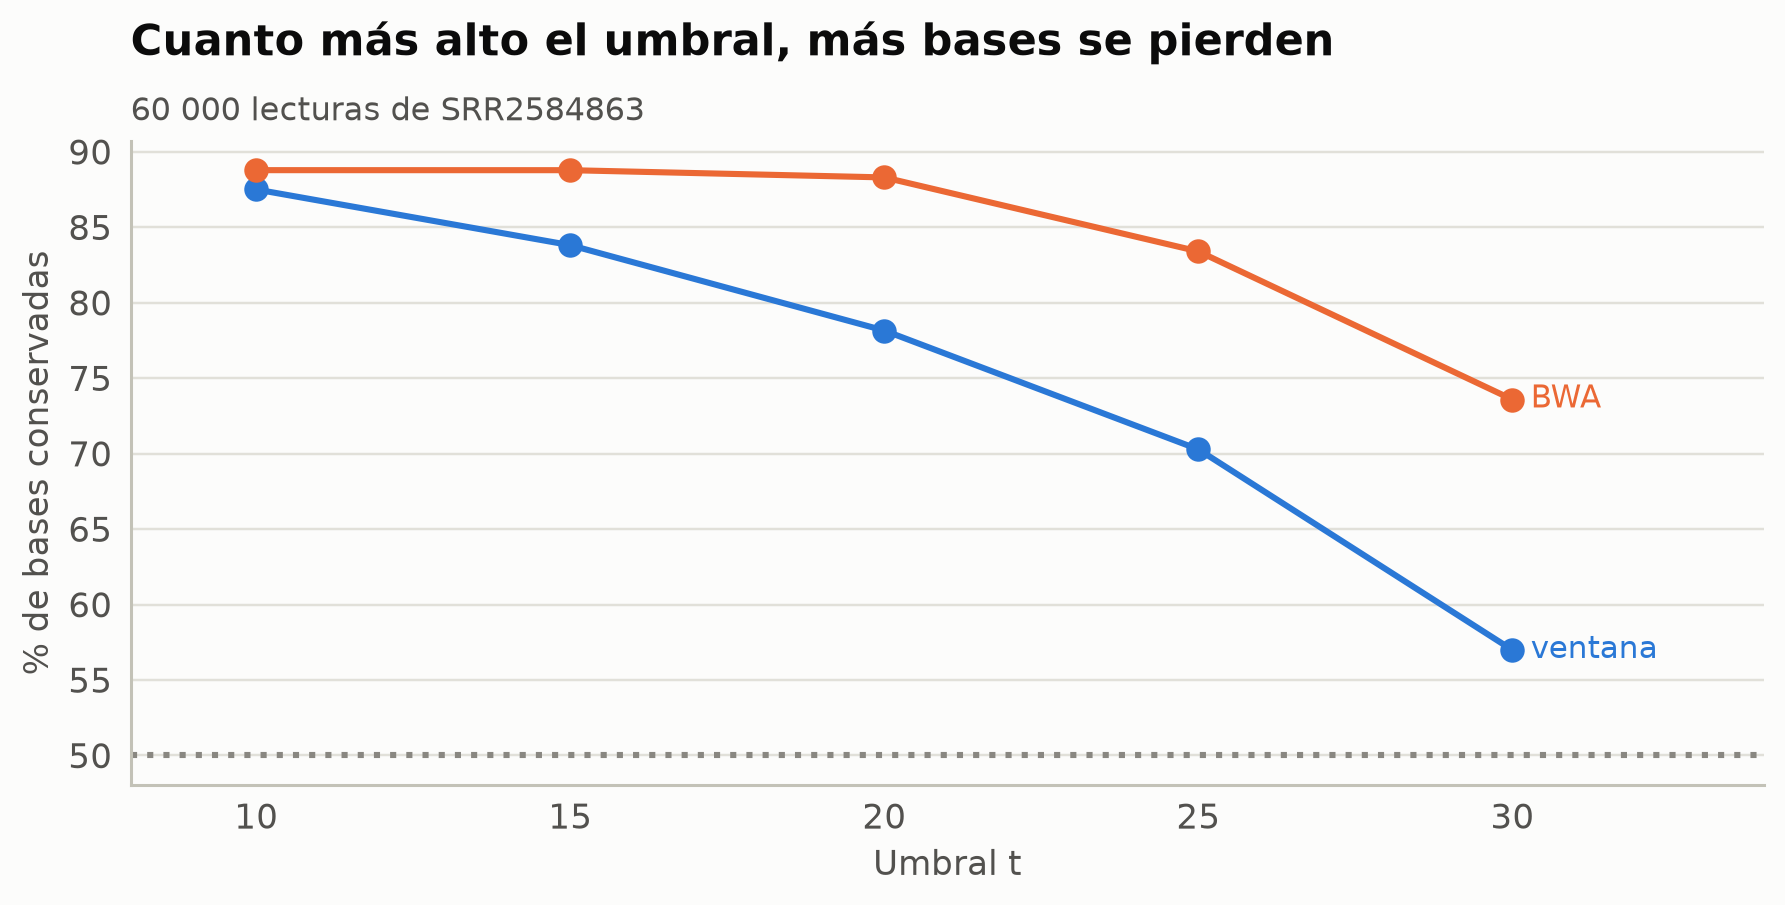

 t  ventana   BWA
10    0.875 0.888
15    0.838 0.888
20    0.782 0.883
25    0.703 0.834
30    0.570 0.736
En este rango ningún método pierde más de la mitad de las bases; la ventana con t = 30 se acerca (≈ 57 %).


In [46]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
qs = [10, 15, 20, 25, 30]
frac_sw = [vec_sliding(Qall, 4, th).sum() / Qall.size for th in qs]
frac_bwa = [vec_bwa(Qall, th).sum() / Qall.size for th in qs]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(qs, 100 * np.array(frac_sw), "o-", color=ec.BLUE); ax.plot(qs, 100 * np.array(frac_bwa), "o-", color=ec.ORANGE)
ec.label_end(ax, qs[-1], 100 * frac_sw[-1], "ventana", ec.BLUE); ec.label_end(ax, qs[-1], 100 * frac_bwa[-1], "BWA", ec.ORANGE)
ax.axhline(50, color=ec.MUTED, ls=":"); ax.set_xlim(8, 34)
ax.set_xlabel("Umbral t"); ax.set_ylabel("% de bases conservadas")
ec.title(ax, "Cuanto más alto el umbral, más bases se pierden", "60 000 lecturas de SRR2584863")
plt.show()
print(pd.DataFrame({"t": qs, "ventana": np.round(frac_sw, 3), "BWA": np.round(frac_bwa, 3)}).to_string(index=False))
print("En este rango ningún método pierde más de la mitad de las bases; la ventana con t = 30 se acerca (≈ 57 %).")

In [47]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
cut_tru, mism_tru = vec_adapter_cut(S1, adapter="AGATCGGAAGAGC")
found = cut_tru < L
print(f"'TruSeq' encontrado en {found.mean():.2%} de las lecturas de R1")
ov = np.minimum(13, L - cut_tru[found])
print("Solapamiento (nt) de esas coincidencias:", dict(sorted(Counter(ov).items())))
print("Casi todas son coincidencias de 3–5 bases al final de la lectura: azar (1/64 para 3 bases), no adaptador TruSeq.")

'TruSeq' encontrado en 1.94% de las lecturas de R1
Solapamiento (nt) de esas coincidencias: {np.int64(3): 434, np.int64(4): 115, np.int64(5): 24, np.int64(6): 6, np.int64(7): 2, np.int64(11): 1, np.int64(13): 1}
Casi todas son coincidencias de 3–5 bases al final de la lectura: azar (1/64 para 3 bases), no adaptador TruSeq.


In [48]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
for max_ee in (2.0, 1.0, 0.5):
    fail_ee = (expected_errors(Q1, k1) > max_ee) | (expected_errors(Q2, k2) > max_ee)
    base_fail = np.zeros(N, bool)
    for key in ("short", "many_n", "low_cx"):
        base_fail |= res["R1"][key] | res["R2"][key]
    kept = ~base_fail & ~fail_ee
    print(f"maxEE = {max_ee}: pasan {kept.sum():,} pares ({kept.mean():.1%}) · el filtro EE elimina {(~base_fail & fail_ee).sum():,}")
print("Tras un buen recorte, bajar maxEE a 1 cuesta poco; a 0.5 empieza a tirar lecturas largas perfectamente útiles,")
print("porque EE crece con la longitud: 150 bases con Q30 ya suman 0.15 errores esperados.")

maxEE = 2.0: pasan 25,541 pares (85.1%) · el filtro EE elimina 0


maxEE = 1.0: pasan 25,511 pares (85.0%) · el filtro EE elimina 30


maxEE = 0.5: pasan 24,530 pares (81.8%) · el filtro EE elimina 1,011
Tras un buen recorte, bajar maxEE a 1 cuesta poco; a 0.5 empieza a tirar lecturas largas perfectamente útiles,
porque EE crece con la longitud: 150 bases con Q30 ya suman 0.15 errores esperados.


## 📌 Resumen

* Antes de alinear o ensamblar, las lecturas se **diagnostican**, se **limpian** y se **vuelven a diagnosticar**.
* La API del **ENA** entrega las URL de los FASTQ; con `gzip` sobre una conexión HTTP se pueden leer sólo las primeras
  lecturas (*streaming*) sin descargar el archivo entero.
* Los módulos de **FastQC** son cálculos sencillos por posición o por lectura: calidad (con Q2 = `#` como bandera de
  Illumina), *tiles*, calidad media, contenido de bases, GC, N, duplicación, secuencias sobrerrepresentadas y
  adaptadores. Hay que **interpretarlos**: el sesgo de los primeros ~15 ciclos en bibliotecas Nextera (Tn5) o con
  hexámeros aleatorios es normal, y la duplicación en datos pareados debe medirse con **los dos extremos**.
* La calidad cae a lo largo de la lectura por el **desfase** de los *clusters*: $\phi(n) = (1-\varepsilon)^n$.
* Recorte por calidad: **ventana deslizante** (se detiene en el primer tramo malo), **BWA** (maximiza
  $S(x) = \sum_{i \ge x}(t - Q_i)$ en el extremo 3′, con empate hacia 3′ y parada cuando la suma se vuelve negativa) y
  **Mott** (tramo contiguo de máxima $\sum (Q_i - t)$, o de $\sum (p_{\text{lím}} - p_i)$ en *phred*/`seqtk`; ambos extremos).
* Los **adaptadores** aparecen cuando el inserto es más corto que la lectura. Se detectan por **alineamiento
  semiglobal** con tasa de error (Cutadapt) o por el **solapamiento de los pares** (fastp), que además estima el
  tamaño de inserto.
* Filtros tras el recorte: longitud mínima, N, baja complejidad y **maxEE** ($\mathrm{EE} = \sum 10^{-Q/10}$).
* **fastp** hace todo lo anterior en segundos y escribe un **JSON** fácil de analizar; **MultiQC** reúne los informes
  de todas las muestras.

## 📚 Para profundizar

* Andrews, S. (2010). *FastQC: a quality control tool for high throughput sequence data*. Babraham Bioinformatics.
  https://www.bioinformatics.babraham.ac.uk/projects/fastqc/
* Bolger, A. M., Lohse, M. & Usadel, B. (2014). Trimmomatic: a flexible trimmer for Illumina sequence data.
  *Bioinformatics* 30(15): 2114–2120.
* Martin, M. (2011). Cutadapt removes adapter sequences from high-throughput sequencing reads. *EMBnet.journal*
  17(1): 10–12.
* Chen, S., Zhou, Y., Chen, Y. & Gu, J. (2018). fastp: an ultra-fast all-in-one FASTQ preprocessor. *Bioinformatics*
  34(17): i884–i890.
* Ewels, P., Magnusson, M., Lundin, S. & Käller, M. (2016). MultiQC: summarize analysis results for multiple tools and
  samples in a single report. *Bioinformatics* 32(19): 3047–3048.
* Edgar, R. C. & Flyvbjerg, H. (2015). Error filtering, pair assembly and error correction for next-generation
  sequencing reads. *Bioinformatics* 31(21): 3476–3482.
* Li, H. & Durbin, R. (2009). Fast and accurate short read alignment with Burrows–Wheeler transform. *Bioinformatics*
  25(14): 1754–1760. (Recorte de calidad `-q` de BWA.)
* Adey, A. *et al.* (2010). Rapid, low-input, low-bias construction of shotgun fragment libraries by high-density
  in vitro transposition. *Genome Biology* 11(12): R119.
* Hansen, K. D., Brenner, S. E. & Dudoit, S. (2010). Biases in Illumina transcriptome sequencing caused by random
  hexamer priming. *Nucleic Acids Research* 38(12): e131.
* Tenaillon, O. *et al.* (2016). Tempo and mode of genome evolution in a 50,000-generation experiment. *Nature*
  536(7615): 165–170. (Origen de los datos: BioProject PRJNA295606.)
* Cock, P. J. A., Fields, C. J., Goto, N., Heuer, M. L. & Rice, P. M. (2010). The Sanger FASTQ file format for
  sequences with quality scores, and the Solexa/Illumina FASTQ variants. *Nucleic Acids Research* 38(6): 1767–1771.

---

☕ **¿Le sirvió esta clase?** El curso es gratuito y seguirá siéndolo; puede apoyarlo invitándome un café en [buymeacoffee.com/juvenalyosx](https://buymeacoffee.com/juvenalyosx). ¡Gracias!

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Apoye el proyecto: Buy Me a Coffee](https://img.shields.io/badge/Apoye%20el%20proyecto-Buy%20Me%20a%20Coffee-FFDD00?logo=buymeacoffee&logoColor=black)](https://buymeacoffee.com/juvenalyosx)